<hr style="height: 1px;">
<i>This notebook was authored by the 8.S50x Course Team, Copyright 2022 MIT All Rights Reserved.</i>
<hr style="height: 1px;">
<br>

<h1>Lesson 20b: Markov Chain Monte Carlo</h1>



<a name='section_21_0'></a>
<hr style="height: 1px;">


## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L20.b Overview</h2>


<h3>Navigation</h3>

<table style="width:100%">
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_21_1">L21.1 Markov Chain MC</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_21_1">L21.1 Exercises</a></td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_21_2">L21.2 Understanding some details</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_21_2">L21.2 Exercises</a></td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_21_3">L21.3 A more realistic Markov Chain MC</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_21_3">L21.3 Exercises</a></td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_21_4">L21.4 Quantum simulations</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_21_4">L21.4 Exercises</a></td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_21_5">L21.5 MCMC using a professional sampler</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_21_5">L21.5 Exercises</a></td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#section_21_6">L21.6 Gravitational Waves</a></td>
        <td style="text-align: left; vertical-align: top; font-size: 10pt;"><a href="#exercises_21_6">L21.6 Exercises</a></td>
    </tr>
</table>

Building upon our work with Monte-Carlo and simulation. We now look at the scenario when our simulation is not perfect, but we have ways to check whether its perfect, and adjust the simulation on the fly to correct it. This approach is amenable to fitting data with complex models as well. This leads to the Markov-Chain Process that we will elaborate on in detail in this lecture.

In [ ]:

#!git init
#!git remote add -f origin https://github.com/mitx-8s50/nb_LEARNER/
#!git config core.sparseCheckout true
#!echo 'data/L23' >> .git/info/sparse-checkout
#!git pull origin main
#!pip install lmfit

Reinitialized existing Git repository in /content/.git/
error: remote origin already exists.
From https://github.com/mitx-8s50/nb_LEARNER
 * branch            main       -> FETCH_HEAD
Already up to date.


In [1]:
import imageio
from PIL import Image

import lmfit
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import csv
import math
from scipy import optimize as opt
from scipy import stats

#Nice MCMC example, models fitting, looking for something that is more complicated in final state
#https://github.com/Joseph94m/MCMC/blob/master/MCMC.ipynb


<h3>Setting Default Figure Parameters</h3>

The following code cell sets default values for figure parameters.


In [1]:
#>>>RUN: L10.0-runcell02

#set plot resolution
%config InlineBackend.figure_format = 'retina'

#set default figure parameters
plt.rcParams['figure.figsize'] = (9,6)

medium_size = 12
large_size = 15

plt.rc('font', size=medium_size)          # default text sizes
plt.rc('xtick', labelsize=medium_size)    # xtick labels
plt.rc('ytick', labelsize=medium_size)    # ytick labels
plt.rc('legend', fontsize=medium_size)    # legend
plt.rc('axes', titlesize=large_size)      # axes title
plt.rc('axes', labelsize=large_size)      # x and y labels
plt.rc('figure', titlesize=large_size)    # figure title
#plt.style.use('seaborn-pastel')

<a name='exercises_23_2'></a>     

| [Top](#section_23_0) | [Restart Section](#section_23_2) | [Next Section](#section_23_3) |


<a name='section_21_3'></a>
<hr style="height: 1px;">

## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L21.3 A more realistic Markov Chain MC</h2>  

| [Top](#section_21_0) | [Previous Section](#section_21_2) | [Exercises](#exercises_21_3) | [Next Section](#section_21_4) |

Ok, since this is the first time I have taught this, I am going to go from a online example, but tweak it heavily to motivate my own thinking to this. What we are going to do is load the historical temperature of the earth over the past 800k years.

The full data can be found [here](https://www.ncei.noaa.gov/pub/data/paleo/icecore/antarctica/epica_domec/edc3deuttemp2007.txt)

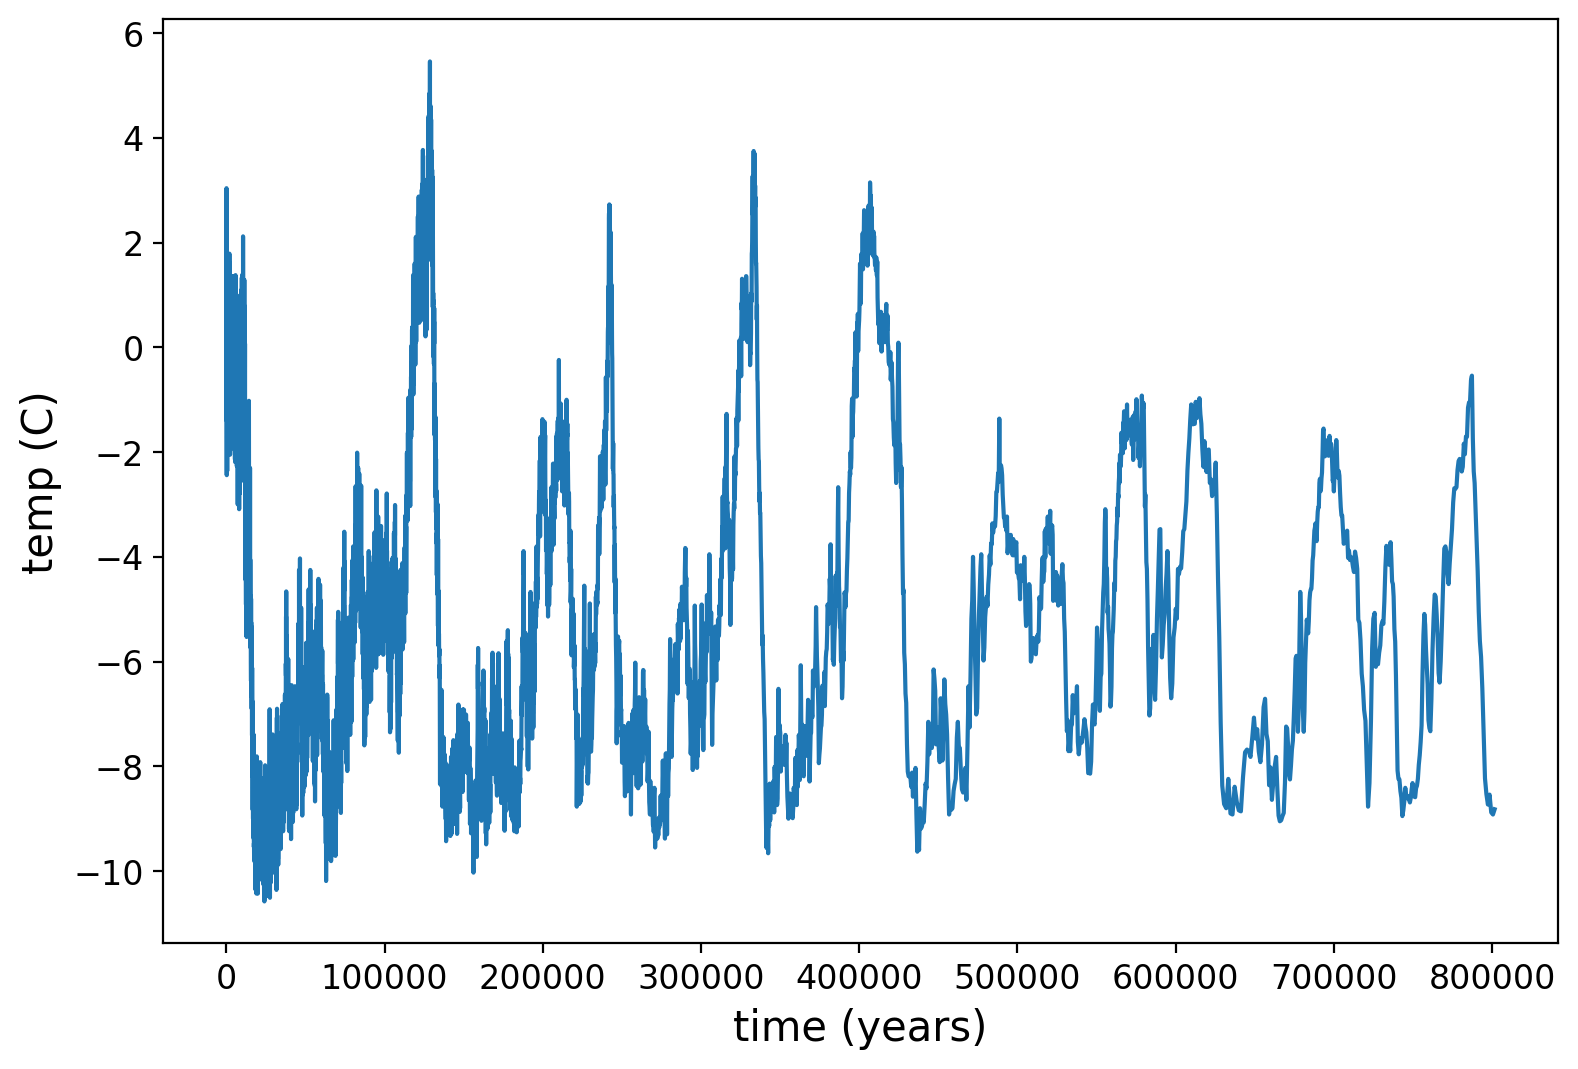

In [34]:
import csv

def load(iFile='ice_core_data.txt'):
    times=np.array([])
    amps =np.array([])
    with open(iFile, newline='') as csvfile:
        line = csv.reader(csvfile, delimiter='\t')
        for row in line:
            arr=row[0].split()
            #print(', '.join(row))
            pT=float(arr[2])
            pA=float(arr[4])
            times=np.append(pT,times)
            amps =np.append(pA,amps)
    #amps  = (amps-amps.mean())/(2.*np.max(amps))
    return times,amps

times,amps=load()
plt.plot(times,amps)
plt.xlabel('time (years)')
plt.ylabel('temp (C)')
plt.show()

data = np.vstack((times,amps))
data = data.T

Ok, so what we are going to do is fit a function consisting of

$$
T(t) = A_{1} \sin \left(\omega_{1} t \right) + A_{2} \sin \left(\omega_{2} t \right) + A_{3} \sin \left(\omega_{3} t \right) + A_{0}
$$

In this case, we are going to do the fit of this. We can do this by simply writing out the likelihood like we have done before.

In [35]:
def func(x,t):
    return x[0]*np.sin(x[1]*t) +  x[2]*np.sin(x[3]*t) +  x[4]*np.sin(x[5]*t) + x[6]

def log_like(x,data):
    return -1.*np.sum((func(x,data[:,0])-data[:,1])**2)

def prior(like,x):
    #Adjust the likelihood by the prior
    prior=0
    if(x[1] < x[3]) or (x[3] < x[5]) or (x[1] < x[5]):
        prior=1
    return like+np.log(prior)

def proposal(x,n=5000):
    #x[0] = mu, x[1]=sigma (new or current)
    x_new     = x.copy()
    #x_new[0]  = x[0] + np.random.randn()*x[0]/np.sqrt(n)
    #x_new[1]  = x[1] + np.random.randn()*x[1]/np.sqrt(n)
    #x_new[2]  = x[2] + np.random.randn()*x[0]/np.sqrt(n)
    #x_new[3]  = x[3] + np.random.randn()*x[1]/np.sqrt(n)
    #x_new[4]  = x[4] + np.random.randn()*x[0]/np.sqrt(n)
    #x_new[5]  = x[5] + np.random.randn()*x[1]/np.sqrt(n)
    #x_new[5]  = x[6] + np.random.randn()*x[1]/np.sqrt(n)
    x_new      = x + np.random.normal(x.shape[0])*(x*0.0001+1e-6)
    #np.random.normal(loc=0,scale=1,size=x.shape[0])*(x+1.0*np.ones(x.shape[0]))
    return x_new

def metropolis_hastings(iLikelihood,iPrior,iProposal,iAcceptance,xinit,data,niterations):
    x = xinit
    accepted = []
    rejected = []
    likelihood = []
    for i in range(niterations):
        x_new   =  iProposal(x)
        likeOld = iLikelihood(x,data)
        likeNew = iLikelihood(x_new,data)
        if (iAcceptance(iPrior(likeOld,x),iPrior(likeNew,x_new))):
            x = x_new
            accepted.append(x_new)
            likelihood.append(likeNew)
        else:
            rejected.append(x_new)
    accepted = np.array(accepted)
    rejected = np.array(rejected)
    likelihood = np.array(likelihood)
    return accepted, rejected, likelihood

xinit = np.array([5.,1./10000.,5.,1./5000.,-5.,1./1000.,-5.])
accepted, rejected, likelihood = metropolis_hastings(log_like,prior,proposal,acceptance,xinit,data,15000)
print(accepted)

[[ 5.00382041e+00  1.07701823e-04  5.00382041e+00  2.07778079e-04
  -5.00380516e+00  1.00838812e-03 -5.00380516e+00]
 [ 5.00733301e+00  1.14783110e-04  5.00733301e+00  2.14929478e-04
  -5.00730373e+00  1.01610042e-03 -5.00730373e+00]]


Alright, lets see look at our likelihood convergence. Also, lets look at our best fit parameters too.

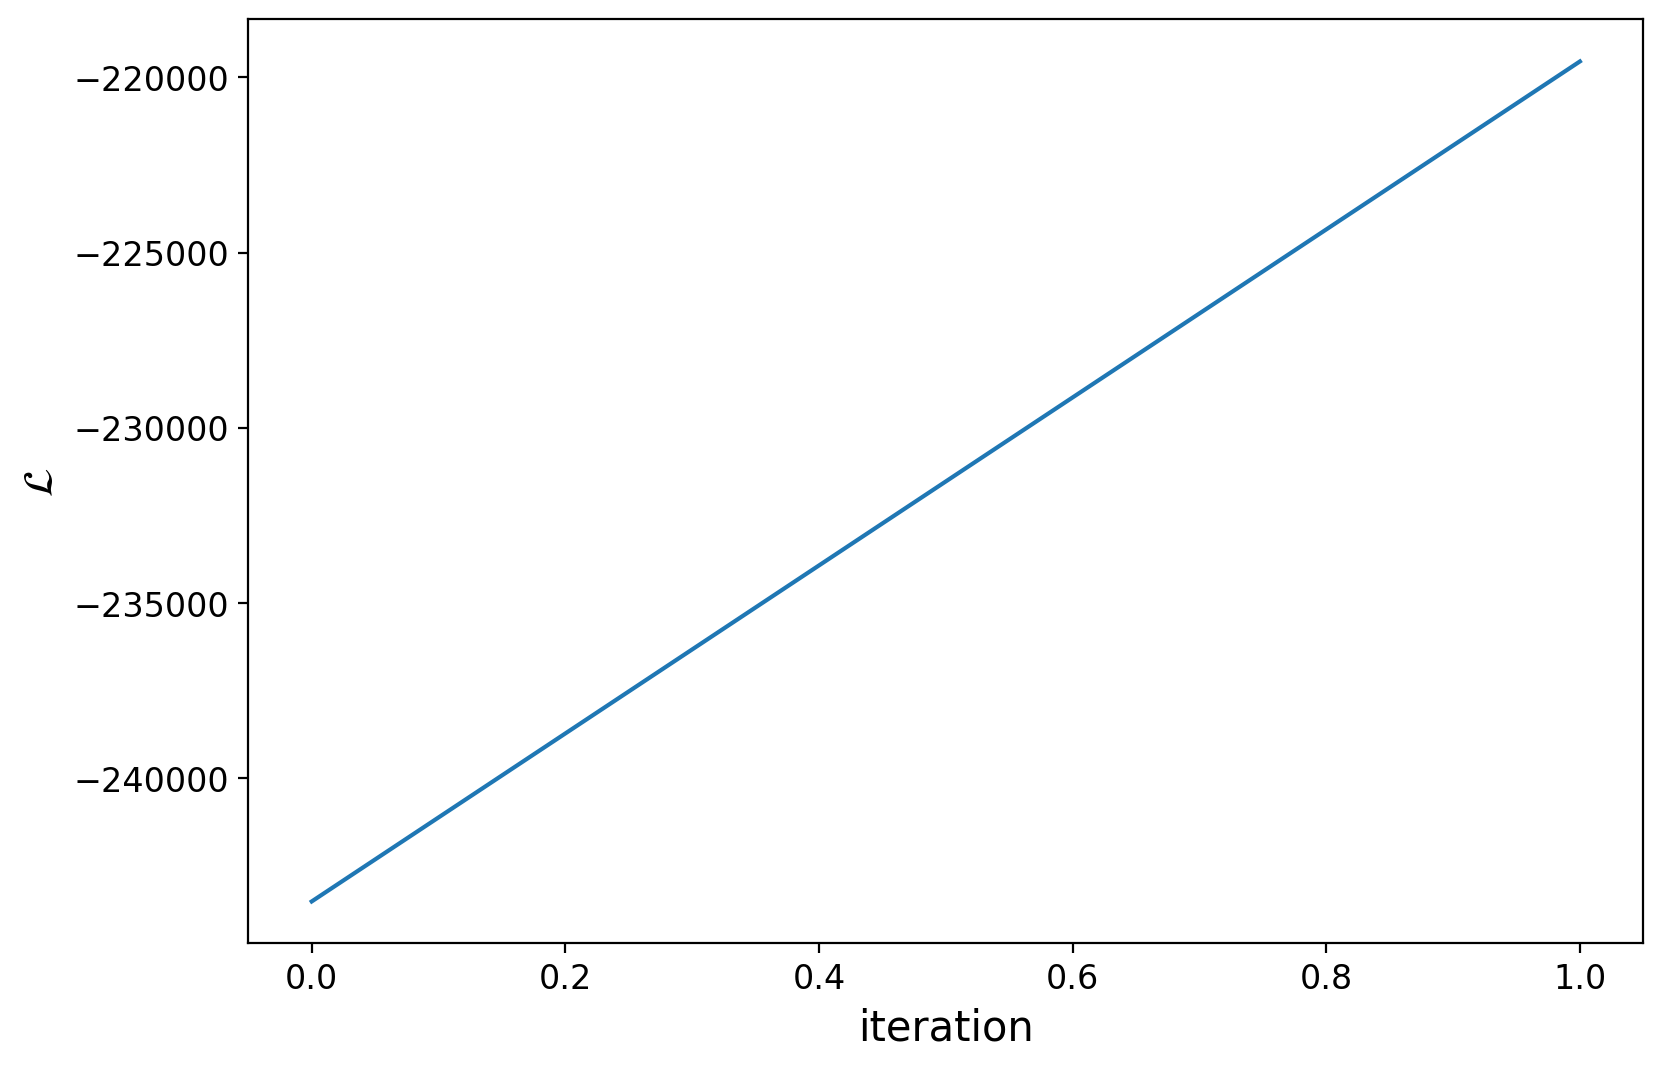

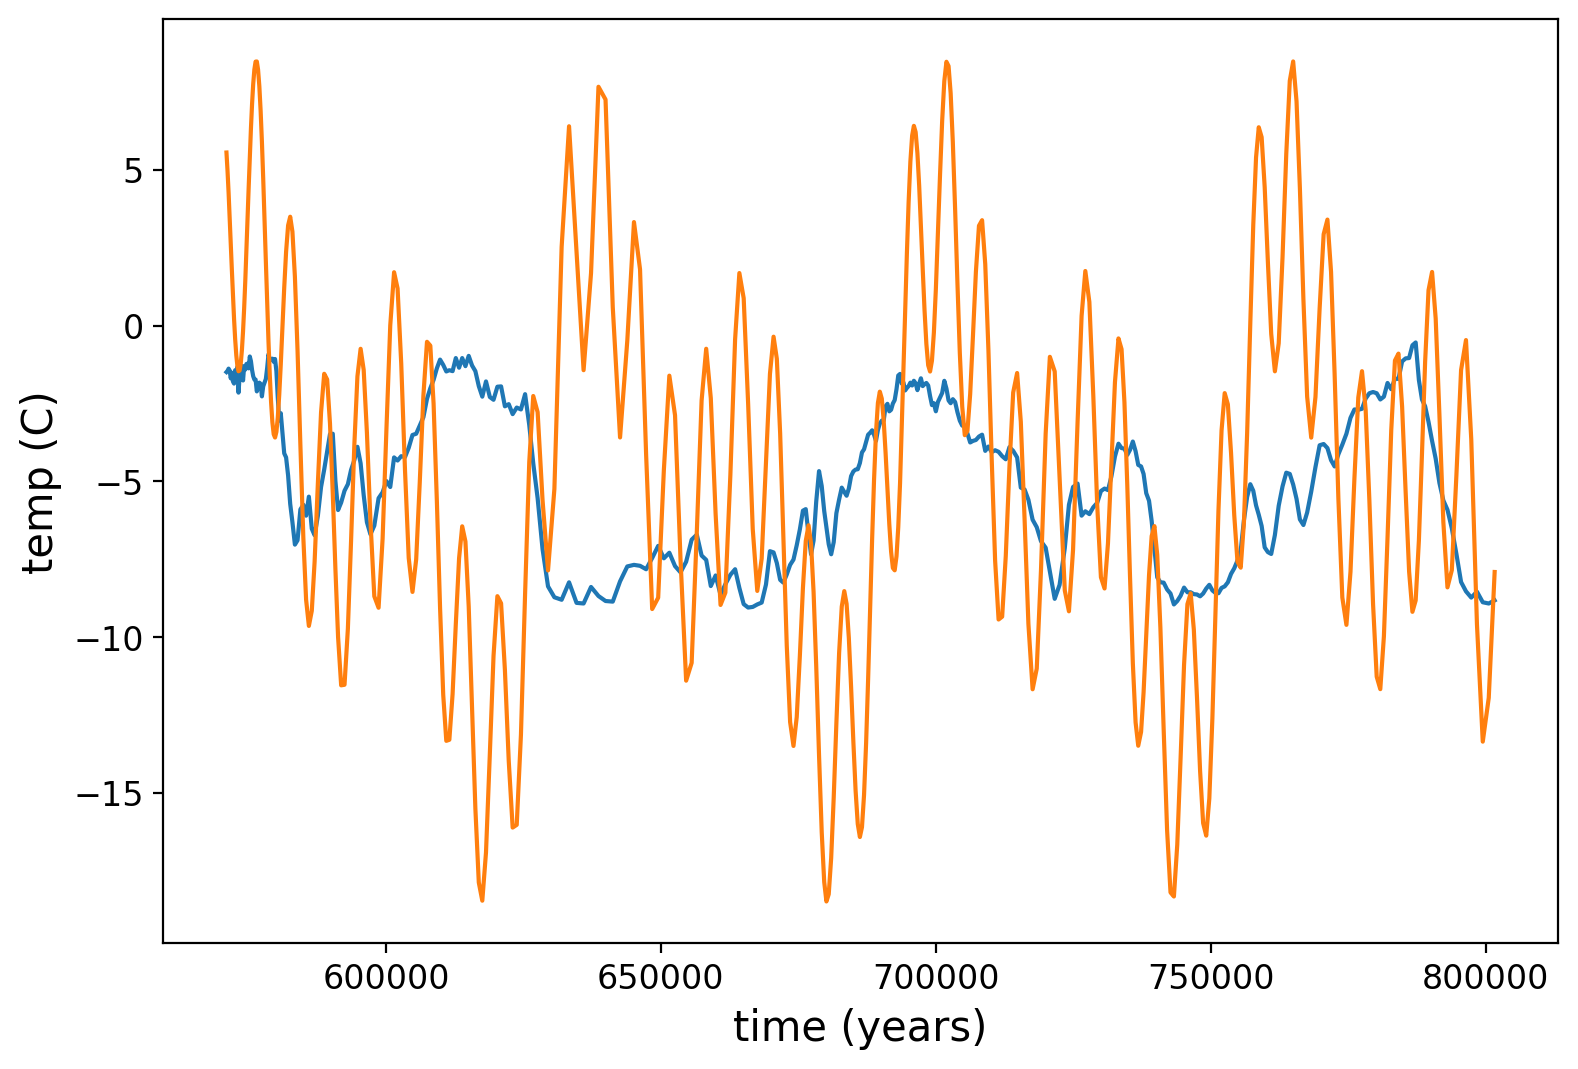

In [36]:
plt.plot(likelihood)
plt.xlabel("iteration")
plt.ylabel("$\mathcal{L}$")
plt.show()

#print(accepted[-1])
plt.plot(times[0:400],amps[0:400])
plt.plot(times[0:400],func(xinit,times)[0:400])
plt.xlabel('time (years)')
plt.ylabel('temp (C)')
plt.show()


19


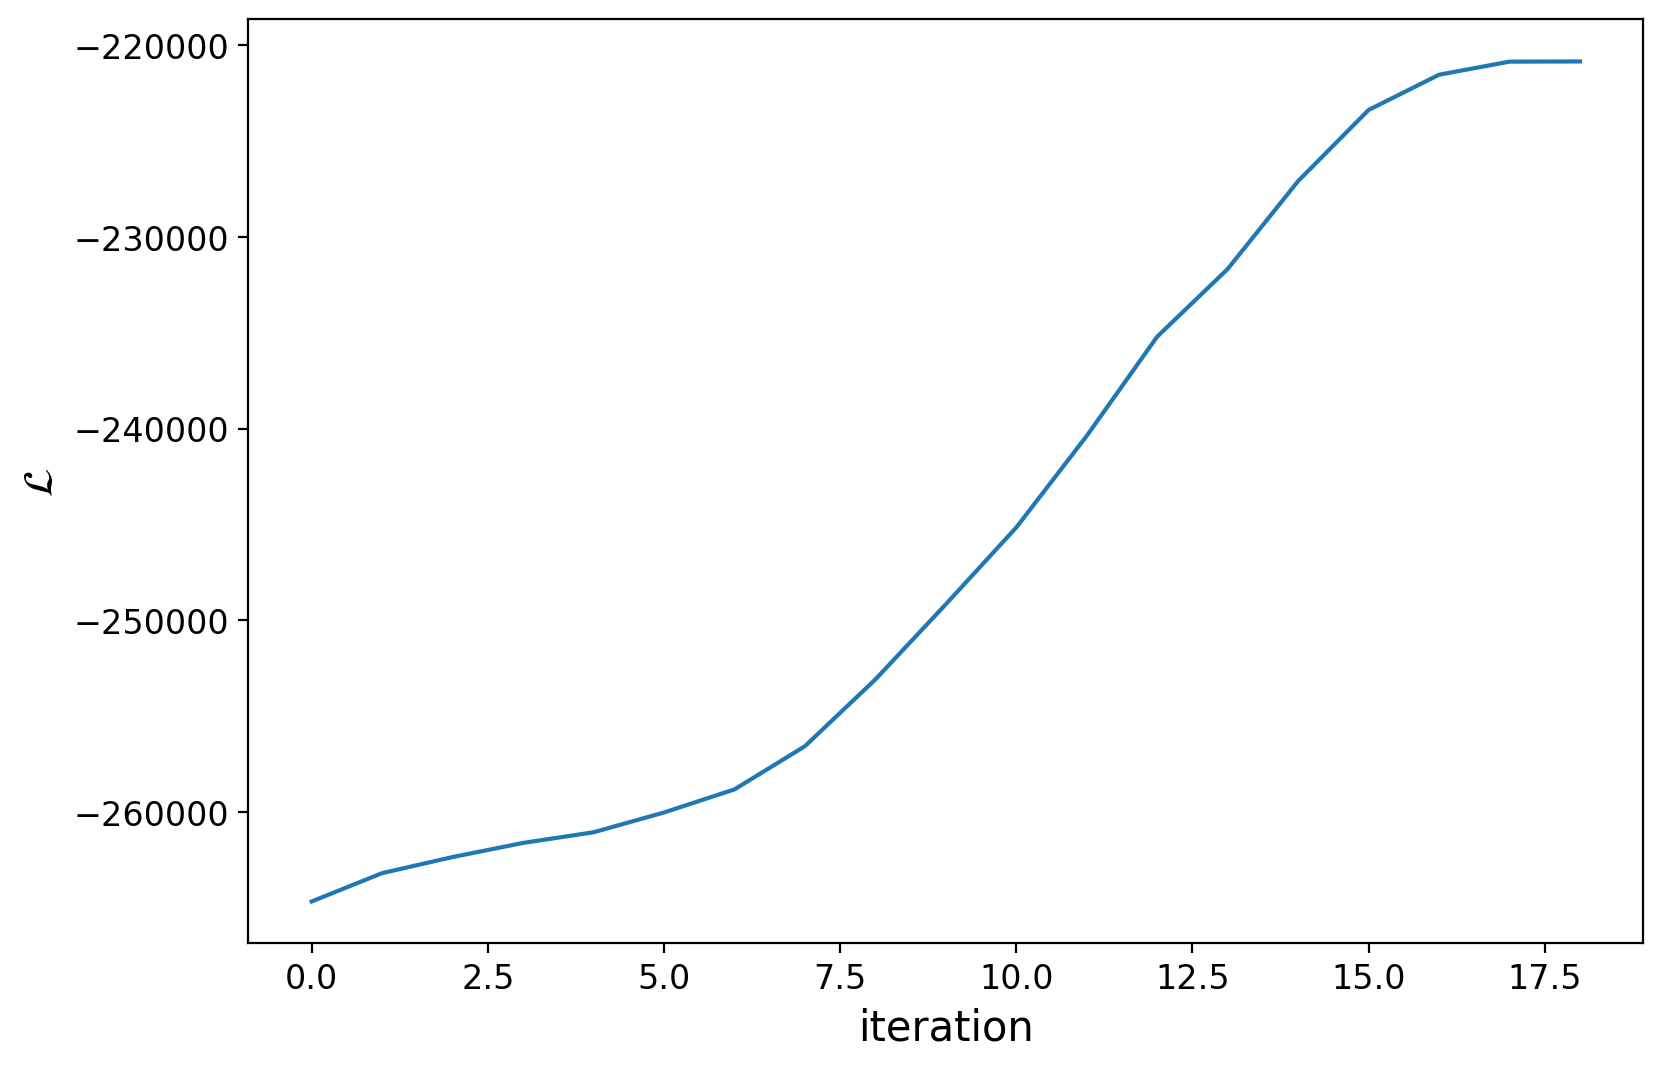

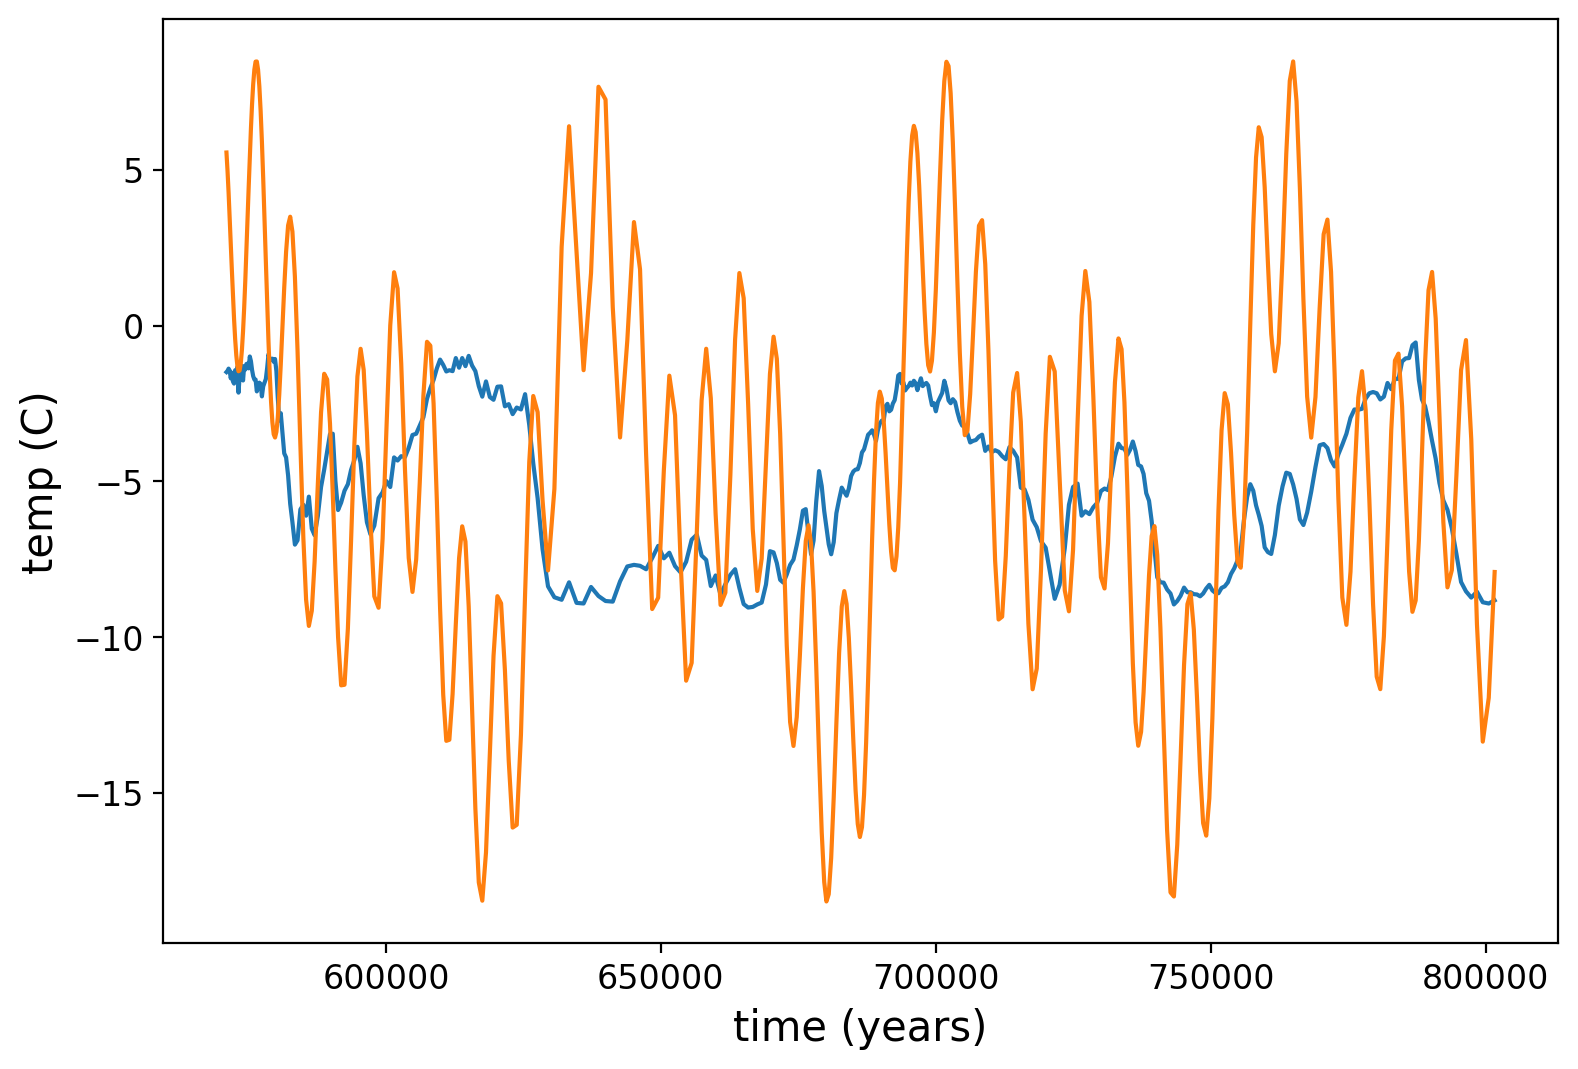

In [37]:
def proposal(x,n=5000):
    return x + np.random.normal(x.shape[0])*1e-3

def prior(like,x):
    #Adjust the likelihood by the prior
    prior=0
    if(x[1] < x[3]) or (x[3] < x[5]) or (x[1] < x[5]):
        prior=1
    return like+np.log(prior)

def func(x,t):
    return x[0]*np.sin(x[1]/10000.*t) +  x[2]*np.sin(x[3]/10000*t) +  x[4]*np.sin(x[5]/10000*t) + x[6]

xinit = np.array([5.,1.,5.,2.,-5.,10.,-5.])
accepted, rejected, likelihood = metropolis_hastings(log_like,prior,proposal,acceptance,xinit,data,150000)
print(len(accepted))

plt.plot(likelihood)
plt.xlabel("iteration")
plt.ylabel("$\mathcal{L}$")
plt.show()

plt.plot(times[0:400],amps[0:400])
plt.plot(times[0:400],func(xinit,times)[0:400])
plt.xlabel('time (years)')
plt.ylabel('temp (C)')
plt.show()


This clearly is a very inefficient way to get to convergence. In light of that, lets see what the professional MCMC samplers actually do. Their strategy is to get closer to the traditional gradient descent methods that we typically perform when trying to fit data when things are differentiable.

Lets go ahead and do that. The strategy will now be to make the minimum searching a little more organized. To do that we will :
  * Search many directions in parallel (call each point a walker)
      * Perform a randomized update on all the Parallel directions
  * Do a more organized stepping relying on random gradient between two walkers
      * In this case we radomly pair walkers and search along the line connecting them
  * As more walkers converge to the best fit the random selection pulls walkers in
  
As a consequence of this, we will define the gradient update for this MCMC method using the existing points built with random selection. We can define this grandient by, given points $X_{i} \in X$, we pick randomly two points $X_{i}$ and $X_{j}$ and we define a random number $Z$, which is greater than 0. We can then define the update as a motion along the line between points $X_{i}$ and $X_{j}$ given by for the $t$ and $t+1$-th step

$$
X_{i}^{t+1} = X_{j}^{t} + Z (X^{t}_{i}-X^{t}_{j})
$$

We can write this update for formally as:

In [39]:
def mc_update(walkers, otherwalkers, logp0, Npars, idata, ifunc, a=2.0,iPrint=False):
    Nw = len(walkers)
    No = len(otherwalkers)

    # Calculates random gradient for the affine linear transformation
    Z = (((a - 1.0) * np.random.rand(Nw) + 1.0) ** 2.0) / a
    if iPrint:
        print("Rand:",Z)

    # gets random indices of the othe rwalkers
    rint = np.random.randint(No, size=(Nw,))
    if iPrint:
        print("Rand Indx:",rint)

    # Propose new positions from the linear transformation
    qt1 = otherwalkers[rint] - Z[:, np.newaxis] * (otherwalkers[rint] - walkers)
    if iPrint:
        print("Rand Updates:", qt1)

    # Calculate the posterior probability of the new position
    logp1 = log_like(qt1, idata,ifunc)
    #logp1 = prior(logp1,qt1)

    #Now do the usual Markov update
    #p_diff = (Npars - 1) * np.log(Z) + logp - logp0
    p_diff = logp1 - logp0

    rshape=np.random.rand(p_diff.shape[0])
    # Determine if the new positions are accepted
    accept = p_diff > np.log(np.random.rand(p_diff.shape[0]))
    return qt1, logp1, accept

#now lets solve a 1 parameter problem
#try to predict a gaussian centered at 10
def tmpfunc(x,t):
    #f(t|x) = val
    #input hyper-parameter x, and value t 
    out=[]
    for pX in x:
        val=pX*np.ones(t.shape)
        out.append(val)
    out = np.array(out)
    return out

def log_like(x,data,ifunc):
    delta = ifunc(x,data[:,0])-data[:,1]*np.ones(x.shape)
    return -1.*np.sum(delta**2,axis=1)

Nwalkers=10
Npars=1
toydata  = np.random.normal(10,2,(10,2))
allWalks = np.array([1 + np.random.randn(Npars) for i in range(Nwalkers)])
logp0    = log_like(allWalks, toydata,tmpfunc)

print("Inital Walks:\n",allWalks,"\nInitial p-vals:\n",logp0)
print("Update first 5:")
newWalks, newlogp, accept = mc_update(allWalks[0:2], allWalks[2:4], logp0[0:2], Npars, toydata, tmpfunc,iPrint=True)
print("Updated Walks:\n",newWalks,"\nUpdated p-vals:\n",newlogp)

print("Update second 5:")
newWalks, newlogp, accept = mc_update(allWalks[2:4], allWalks[0:2], logp0[2:4], Npars, toydata, tmpfunc)
print("Updated Walks:\n",newWalks,"\nUpdated p-vals:\n",newlogp)


Inital Walks:
 [[-1.18959367]
 [ 0.0268012 ]
 [ 2.23453032]
 [ 0.66616188]
 [ 1.86150989]
 [ 2.1014877 ]
 [ 1.62705189]
 [ 0.55758915]
 [ 1.64296564]
 [ 0.24108705]] 
Initial p-vals:
 [-1402.05979552 -1133.67186369  -722.14923342 -1004.46694473
  -784.83672802  -744.18827637  -825.66256367 -1025.83152567
  -822.85674627 -1089.45712717]
Update first 5:
Rand: [1.25303827 0.69044712]
Rand Indx: [1 0]
Rand Updates: [[-1.65917085]
 [ 0.71021011]]
Updated Walks:
 [[-1.65917085]
 [ 0.71021011]] 
Updated p-vals:
 [-1513.5852356   -995.86650648]
Update second 5:
Updated Walks:
 [[4.34532937]
 [0.94502876]] 
Updated p-vals:
 [-419.84990356 -950.67288726]


Ok, so the above code covers an example update. Let's recap exactly what we did above

 * We defined a function that just outputs a single parameter
 * We made some toy data centered around a single parameter
 * We created 10 Walkers
 * We computed the p-values for our 10 walkers
 * We then split our walkers into two parts (walkers and otherwalkers):
     * With each part we fixed otherwalkers and updated walkers
     * We updated walkers following a random sample update along the line of a walker and a random other walker
     * Once we updated, we ran our traditional MCMC sampling
 * We repeat the above steps on the otherwalkers with the walkers fixed


All in all our strategy here is to just do a parallel MCMC updates on a gride of points to progressively get closer to the sample. Because we have many points, we can take advantage of them crawling all over our distribution to get to the minimum.

Note that this walker strategy was developed fairly recently and has had its main use from astrophysics see [here](https://arxiv.org/abs/1710.06068). The actual walker was developed two statisticians (Goodman and Weare) who have worked closely with the astro community.  

Ok now that we have done that, lets go ahead and do this for our more complicated function.


In [40]:
def proposal(q, logp, data, Nwalk, Npars, iFunc):
    half = int(Nwalk / 2)
    first, second = slice(half), slice(half, Nwalk)

    # Alternate slices of the data fixing and updating
    for S0, S1 in [(first, second), (second, first)]:
        # Use stretch move to calculate the proposal
        q_new, logp_new, acc = mc_update(q[S0], q[S1], logp[S0], Npars, data, iFunc)

        # Add accepted values into the chains
        if np.any(acc):
            logp[S0][acc] = logp_new[acc]
            q[S0][acc]    = q_new[acc]

    return q, logp

#def metropolis_hastings(iLikelihood,iPrior,iProposal,iAcceptance,xinit,data,niterations):
def metropolis_hastings_ensemble(xinit, logpinit, data, Npars, Nwalk, Nstep,iFunc):
    samples = np.ndarray((Nwalk, Nstep, Npars))
    samples[:, 0, :] = np.array(xinit)

    lnprob = np.ndarray((Nwalk, Nstep))
    lnprob[:, 0] = np.array(logpinit)

    # Iterate over the Markov steps
    for i in range(1, Nstep):
        if i % 5000 ==0:
            print("Steps:",i)
        q, p = proposal(samples[:,i-1,:], lnprob[:,i-1], data, Nwalk, Npars, iFunc)
        samples[:,i,:] = np.array(q)
        lnprob[:,i] = np.array(p)

    return samples, lnprob

# Set up MCMC parameters
Npars = xinit.shape[0]
Nwalk = 100
Nstep = 25000

def log_like(x,data,iFunc):
    return -1.*np.sum((iFunc(x,data[:,0])-data[:,1])**2,axis=1)

def func(x,t):
    out=[]
    for pX in x:
        val=pX[0]*np.sin(pX[1]/10000.*t) +  pX[2]*np.sin(pX[3]/10000*t) +  pX[4]*np.sin(pX[5]/10000*t) + pX[6]
        out.append(val)
    out = np.array(out)
    return out

q0    = np.array([xinit + 1.0e-4*np.random.randn(Npars) for i in range(Nwalk)])
logp0 = log_like(q0, data, func)
accepted, likelihood = metropolis_hastings_ensemble(q0,logp0,data,Npars,Nwalk,Nstep,func)

Steps: 5000
Steps: 10000
Steps: 15000
Steps: 20000


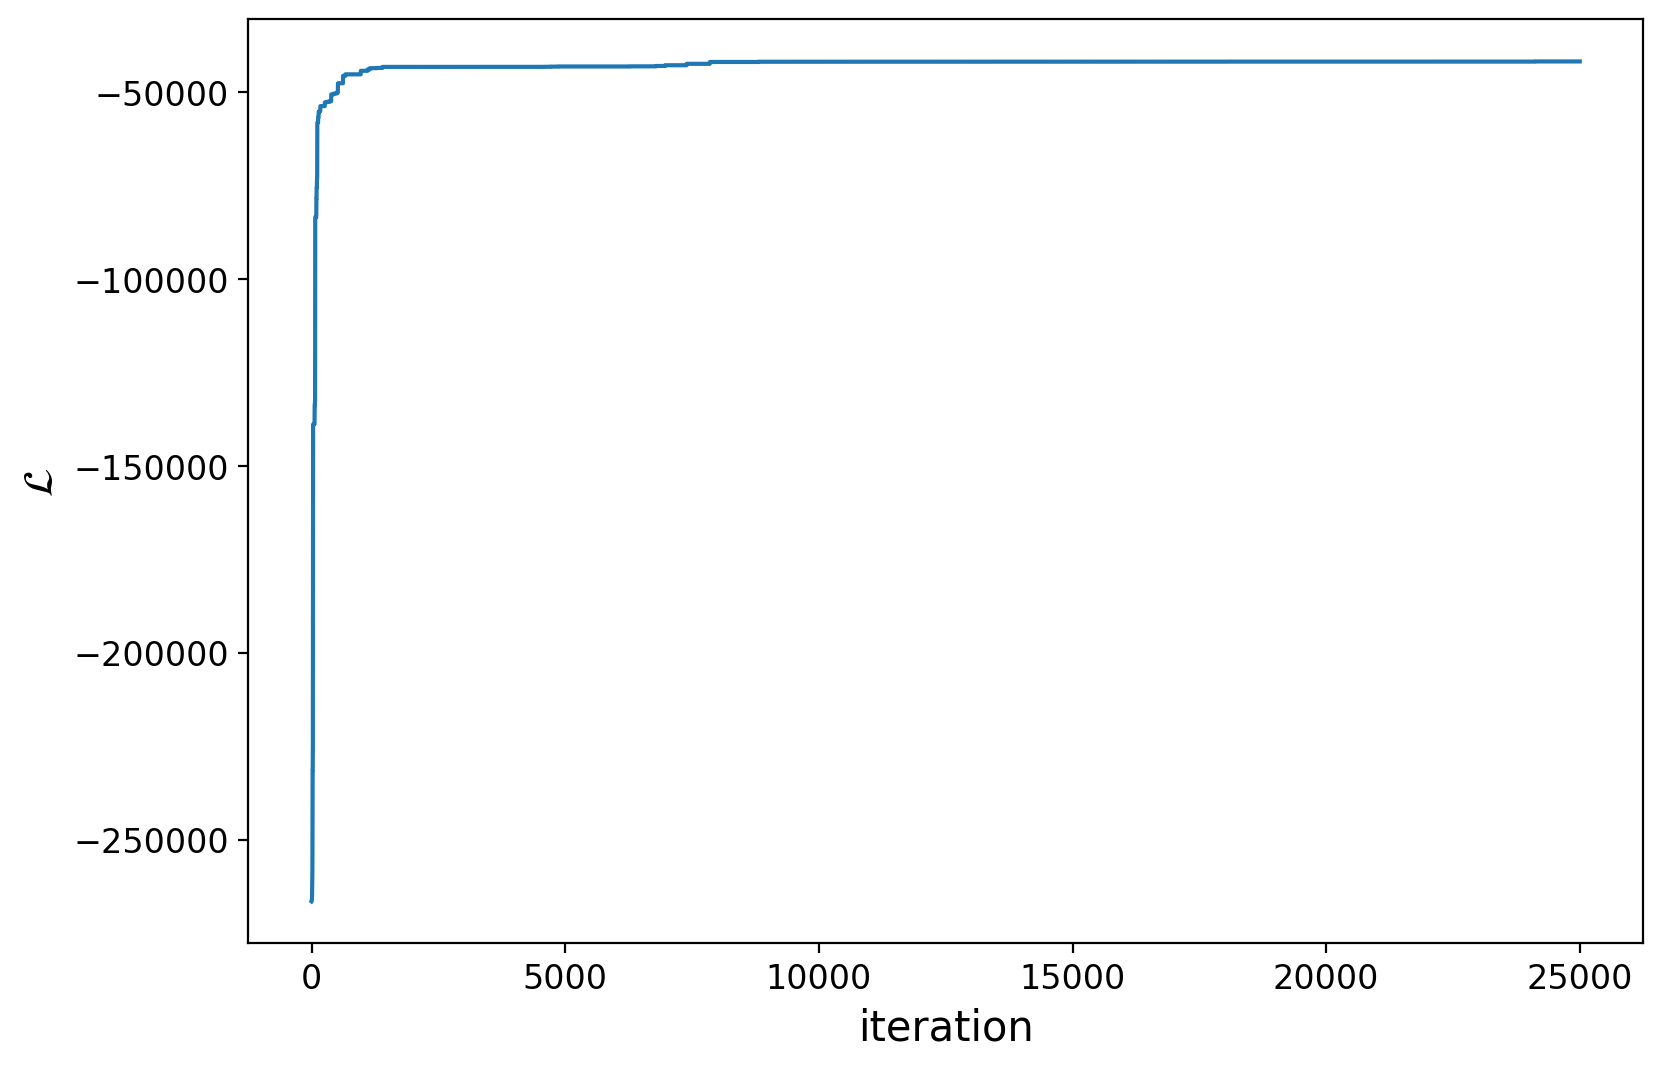

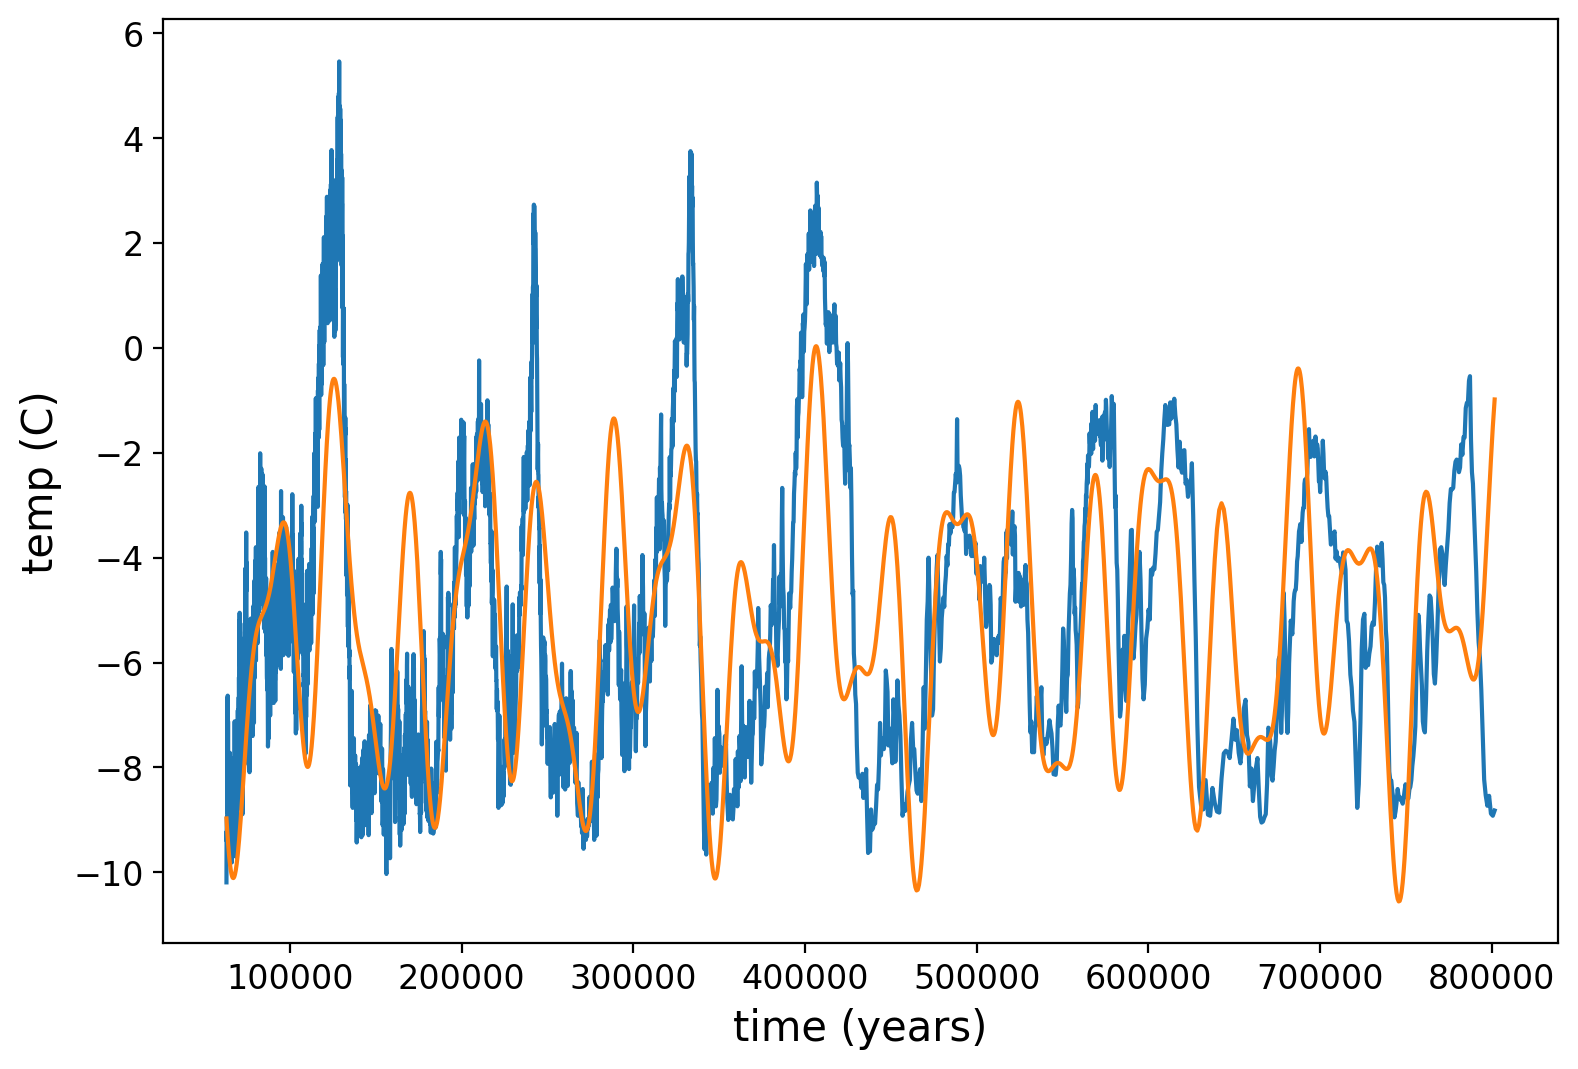

In [41]:
lproj = np.max(likelihood,axis=0)
plt.plot(lproj)
plt.xlabel("iteration")
plt.ylabel("$\mathcal{L}$")
plt.show()

maxval=np.argmax(lproj)
maxy=np.argmax(likelihood[:,maxval])
bestpars=np.array([accepted[maxy,maxval]])
output=func(bestpars,times)

plt.plot(times[0:4000],amps[0:4000])
plt.plot(times[0:4000],output.flatten()[0:4000])
plt.xlabel('time (years)')
plt.ylabel('temp (C)')
plt.show()


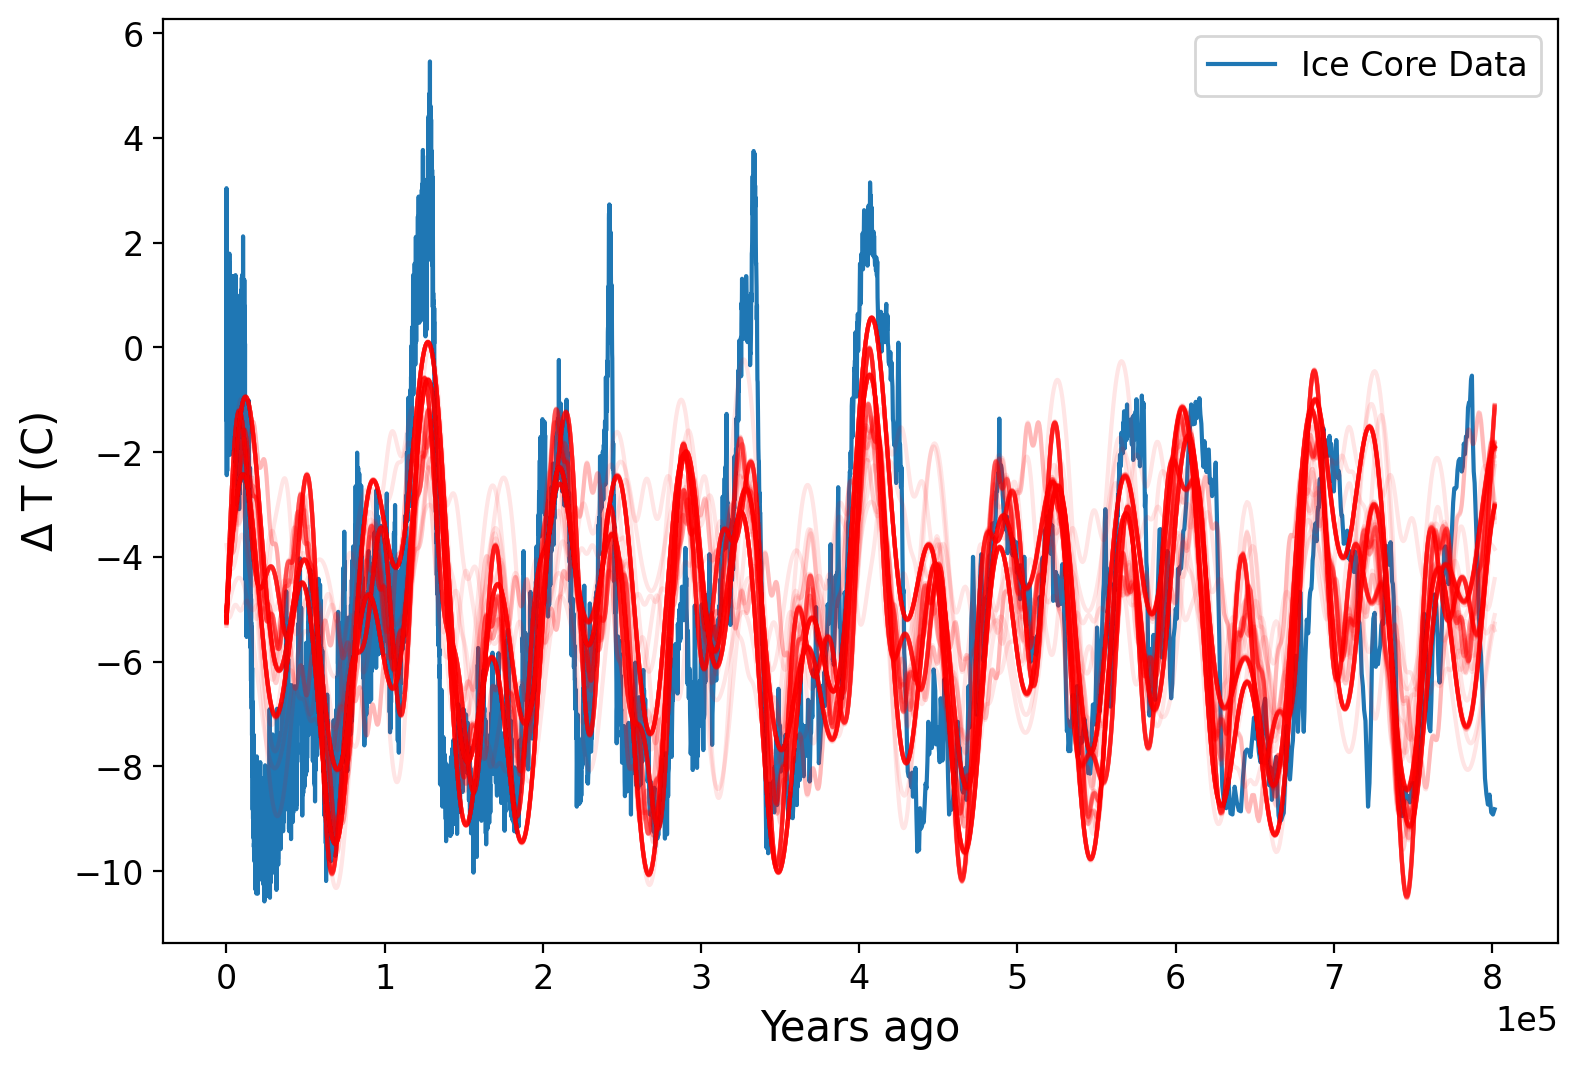

In [36]:
def plotter(accepted,times,amps):
    plt.ion()
    plt.plot(times,amps,label='Ice Core Data')
    output=func(accepted[:,-1],times)
    for i0 in range(100):
        plt.plot(times, output[i0], color="r", alpha=0.1)
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.xlabel('Years ago')
    plt.ylabel(r'$\Delta$ T (C)')
    plt.legend()
    plt.show()

plotter(accepted,times,amps)

<a name='exercises_23_3'></a>     

| [Top](#section_23_0) | [Restart Section](#section_23_3) | [Next Section](#section_23_4) |


<a name='section_21_4'></a>
<hr style="height: 1px;">

## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L21.4 Quantum simulations </h2>  

| [Top](#section_21_0) | [Previous Section](#section_21_3) | [Exercises](#exercises_21_4) | [Next Section](#section_21_5) |

Now in the interest of showing the diversity of Markov Chain Monte Carlo. We would like to show can we use this to augment simulations. The strategy here is to rely on the fact that

 * We have a formula that describes the full behavior of our system and outputs a likelihood of it happening
 * We don't know the parameters to get this system to behave naturally

In this instance the Markov Chain MC step can be used to get the right conditions for the system to work.

To give you a concrete example, let's solve the Hydrogen atom with Markov Chain MC. What we are going to do is solve the Schrodinger's equation for a wave function $\psi$. We can write the equation as

$$
H\psi = E \psi \\
(H-E)\psi = 0 \\
H=\frac{p^2}{2m} + \frac{ke^2}{r^2} \\
-\frac{\hbar^2}{2m}\frac{\partial^{2} \psi}{\partial r^2} - \left(  \frac{ke^2}{r} -\frac{\hbar^2\ell(\ell+1)}{2mr^2}  \right)\psi  - E \psi = 0
$$
Now if we set $\hbar=1=m=k$ we can write
$$
-\frac{1}{2}\frac{\partial^{2} \psi}{\partial r^2} - \left(  \frac{1}{r} -\frac{\ell(\ell+1)}{2r^2}  \right)\psi  - E \psi = 0
$$


This is a differential equation we can solve by minimizing the above equation with a proposal for the wavefunction. That has a form characteristic of our final solution. Given the above equation, we can write a proposed solution of

$$
\psi(r) = \alpha r e^{-\alpha r}   \\
\frac{\partial \psi}{\partial r} = \alpha e^{-\alpha r} -\alpha^{2} e^{-\alpha r} \\
\frac{\partial^{2} \psi}{\partial r^{2}} = -2\alpha^{2} e^{-\alpha r} + \alpha^{3} r e^{-\alpha r}
$$

For that we can plug in the above equation and write

$$
\alpha^{2} e^{-\alpha r} - \frac{1}{2}\alpha^{3} r e^{-\alpha r}  - \left(  \frac{1}{r} -\frac{\ell(\ell+1)}{2r^2}  \right)  \alpha r e^{-\alpha r} - E  \alpha r e^{-\alpha r}= 0 \\
\alpha^{2} -  \frac{1}{2} \alpha^{3} r   - \left(  \frac{1}{r} -\frac{\ell(\ell+1)}{2r^2}  \right)  \alpha r =  E  \alpha r
$$
Then if we set $\ell=0$ we have dividing by $\alpha r$
$$
\frac{\alpha}{r} -  \frac{\alpha^{2}}{2}    -   \frac{1}{r}    =  E_{0}   
$$

Now we can solve for $\alpha$ by finding the minimimum of $E_{0}$.

What we are going to do is compute the expectation of $E_{0}$ defined by

$$
\langle E_{0} \rangle = \frac{\langle \psi | E_{0} | \psi \rangle}{\langle \psi | \psi \rangle}\\
\langle E_{0} \rangle = \frac{\int_{0}^{\infty}\psi(r)^2 E_{0} dr}{\int_{0}^{\infty}\psi(r)^2  dr}
$$

Let's go ahead and plot $\psi(r)$ and look at $\langle E_{0} \rangle (\alpha)$

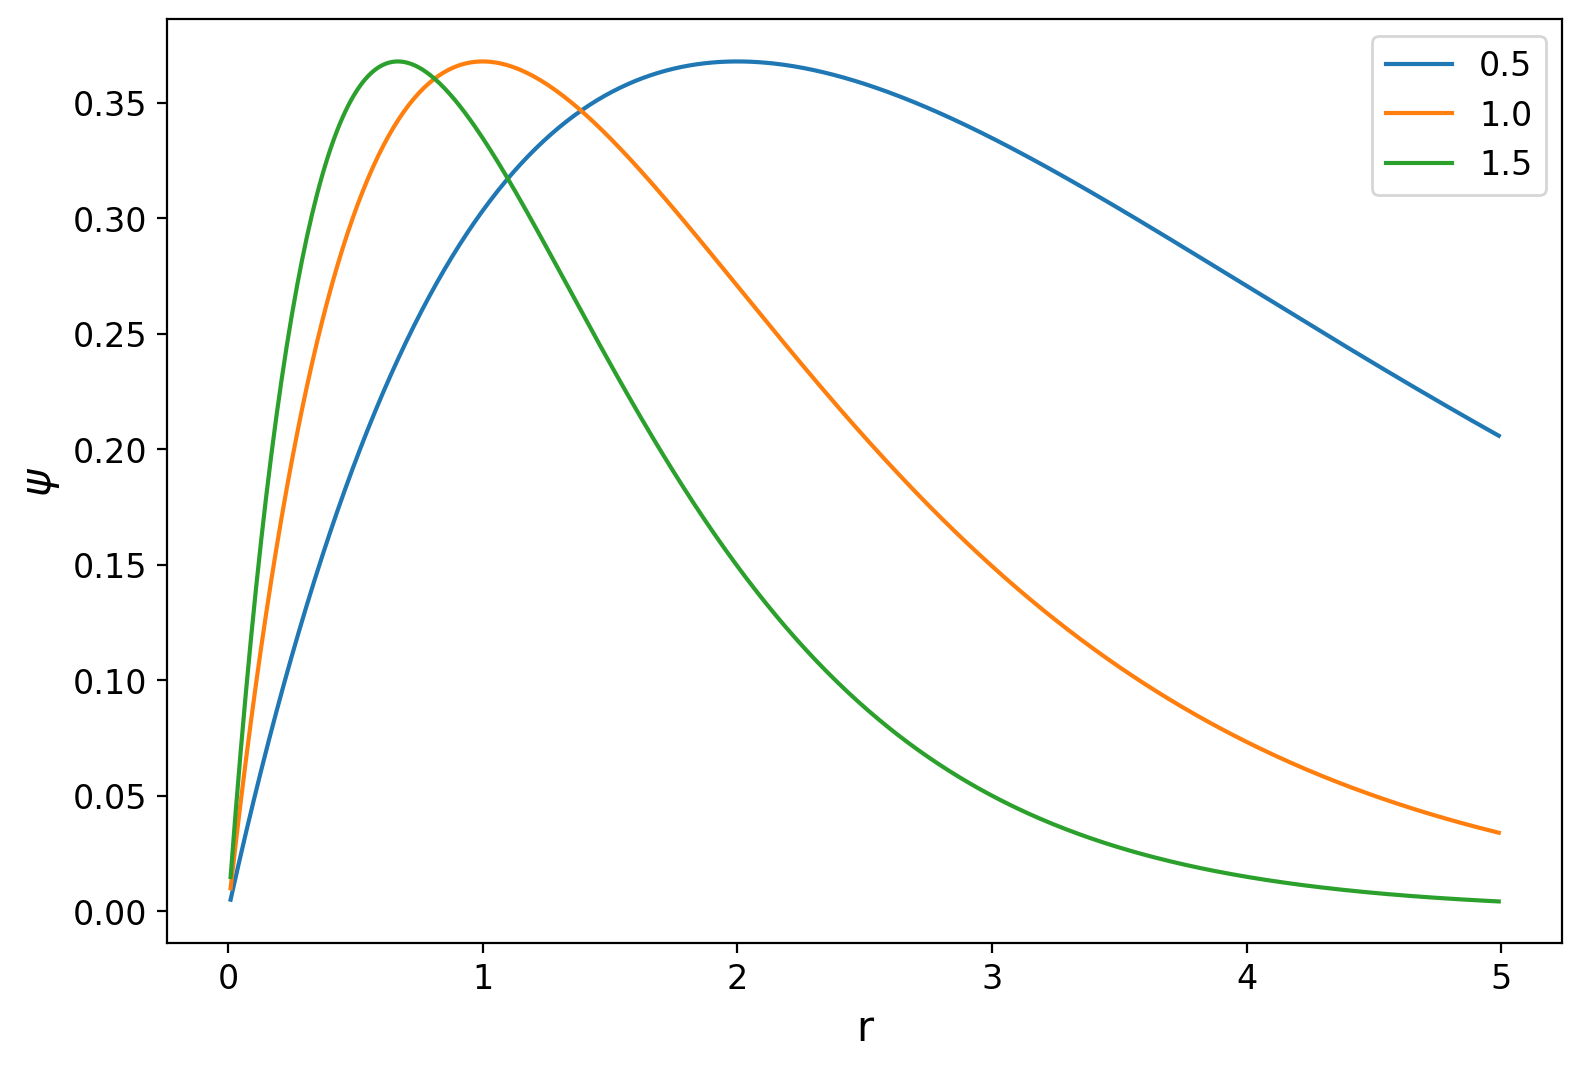

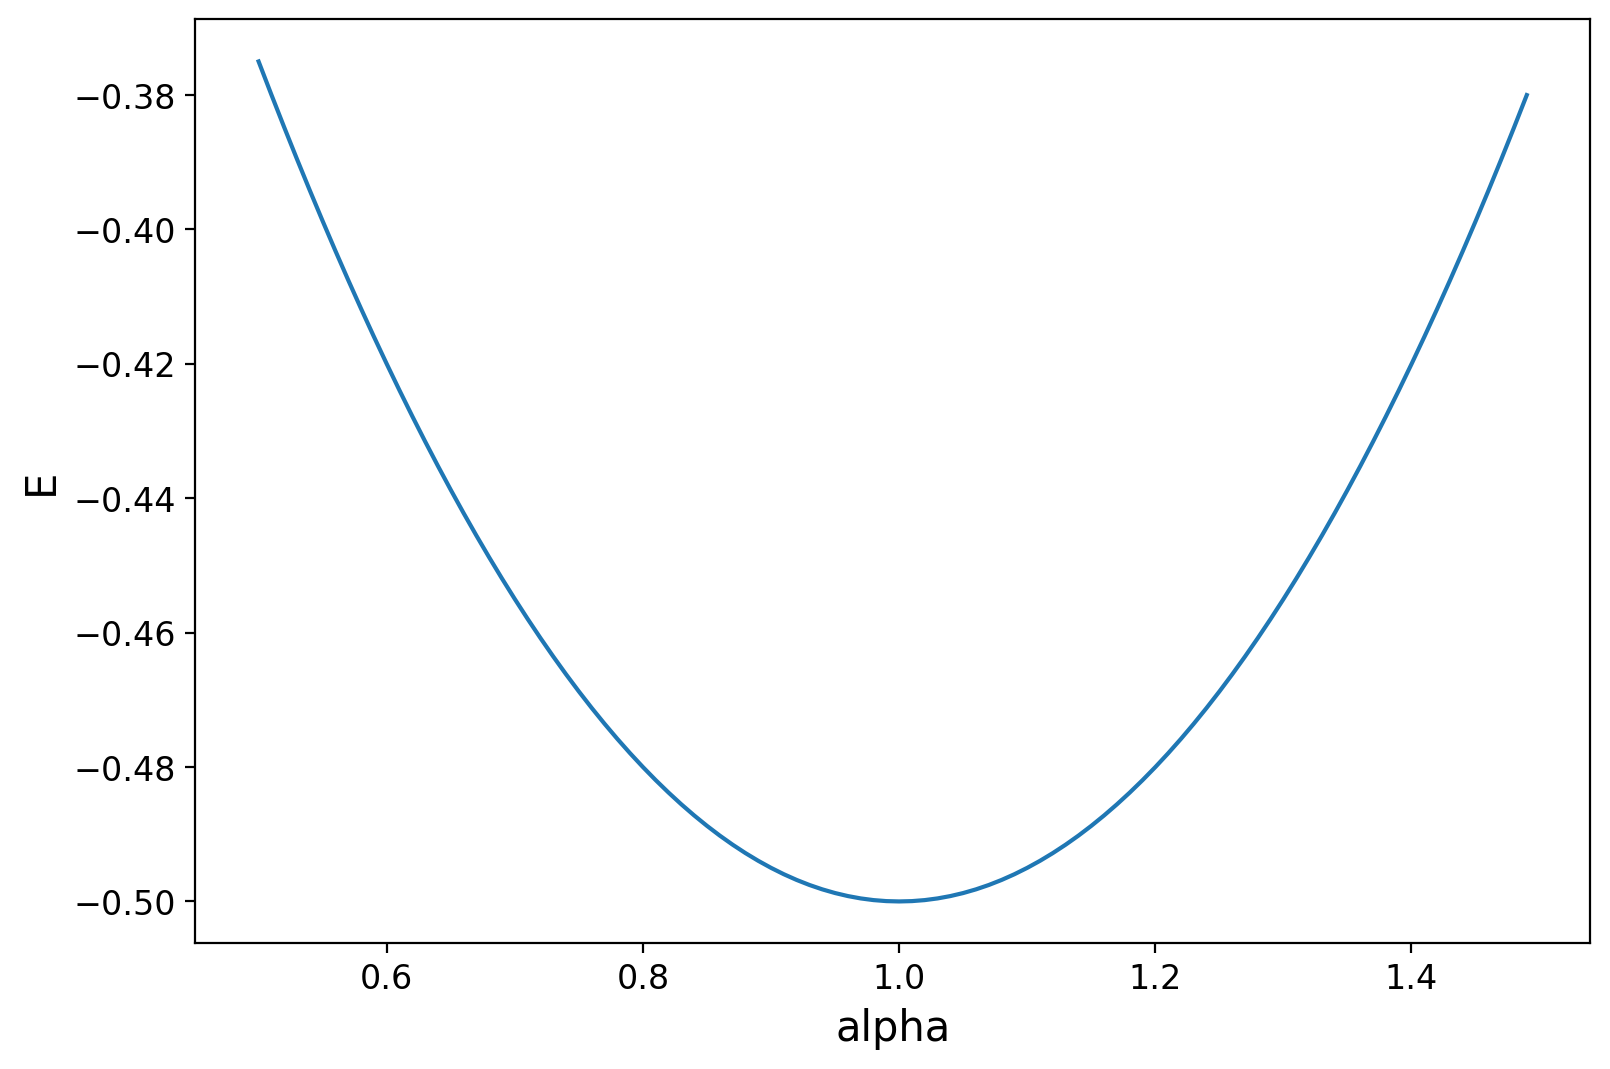

In [38]:
def psi(ialpha,iR):
    return np.where(iR > 0., ialpha*iR*np.exp(-ialpha*iR), 0.)#np.zeros(iR.shape))

def minE0(ialpha,iR):
    return np.where(ialpha > 0, ialpha/iR -ialpha**2/2-1./iR, 0.)

def expect(ialpha,irvals=np.arange(0.01,30,0.01)):
    alphas, rvals = np.meshgrid(ialpha, irvals)
    E0=np.sum(psi(alphas,rvals)*minE0(alphas,rvals)*psi(alphas,rvals),axis=0)
    bot=np.sum(psi(alphas,rvals)*psi(alphas,rvals),axis=0)
    return E0/bot

rvals=np.arange(0.01,5,0.01)
plt.plot(rvals,psi(0.5,rvals),label='0.5')
plt.plot(rvals,psi(1.0,rvals),label='1.0')
plt.plot(rvals,psi(1.5,rvals),label='1.5')
plt.xlabel('r')
plt.ylabel('$\psi$')
plt.legend()
plt.show()

alphas=np.arange(0.5,1.5,0.01)
plt.plot(alphas,expect(alphas),label='alpha')
plt.xlabel('alpha')
plt.ylabel('E')
plt.show()



Now, we can define a variational approach by evolving the wave function over many steps and computing the best fit parameters. The way we evolve the wave function is to note that

$$
p(r) = \psi^{2}(r)
$$

which means that we can create a wave function by taking a variety of samples and evolve them as if they are in a Markov chain with a probability given by the $p(r)$.

To do that, we will follow the chain:
  * Create some random samples
  * Randomly sample a distribution to step
  * Compute the change in probabilities
    * define by weight $w_{i+1} = p_{i+1}/p_{i}$
  * Sample a flat distribuiton get $p_{\rm samp}$
    * Accept the new step if $p_{\rm samp} < w_{i+1}$
  * Compute observables like $E_{0}$  

Lets give this a try

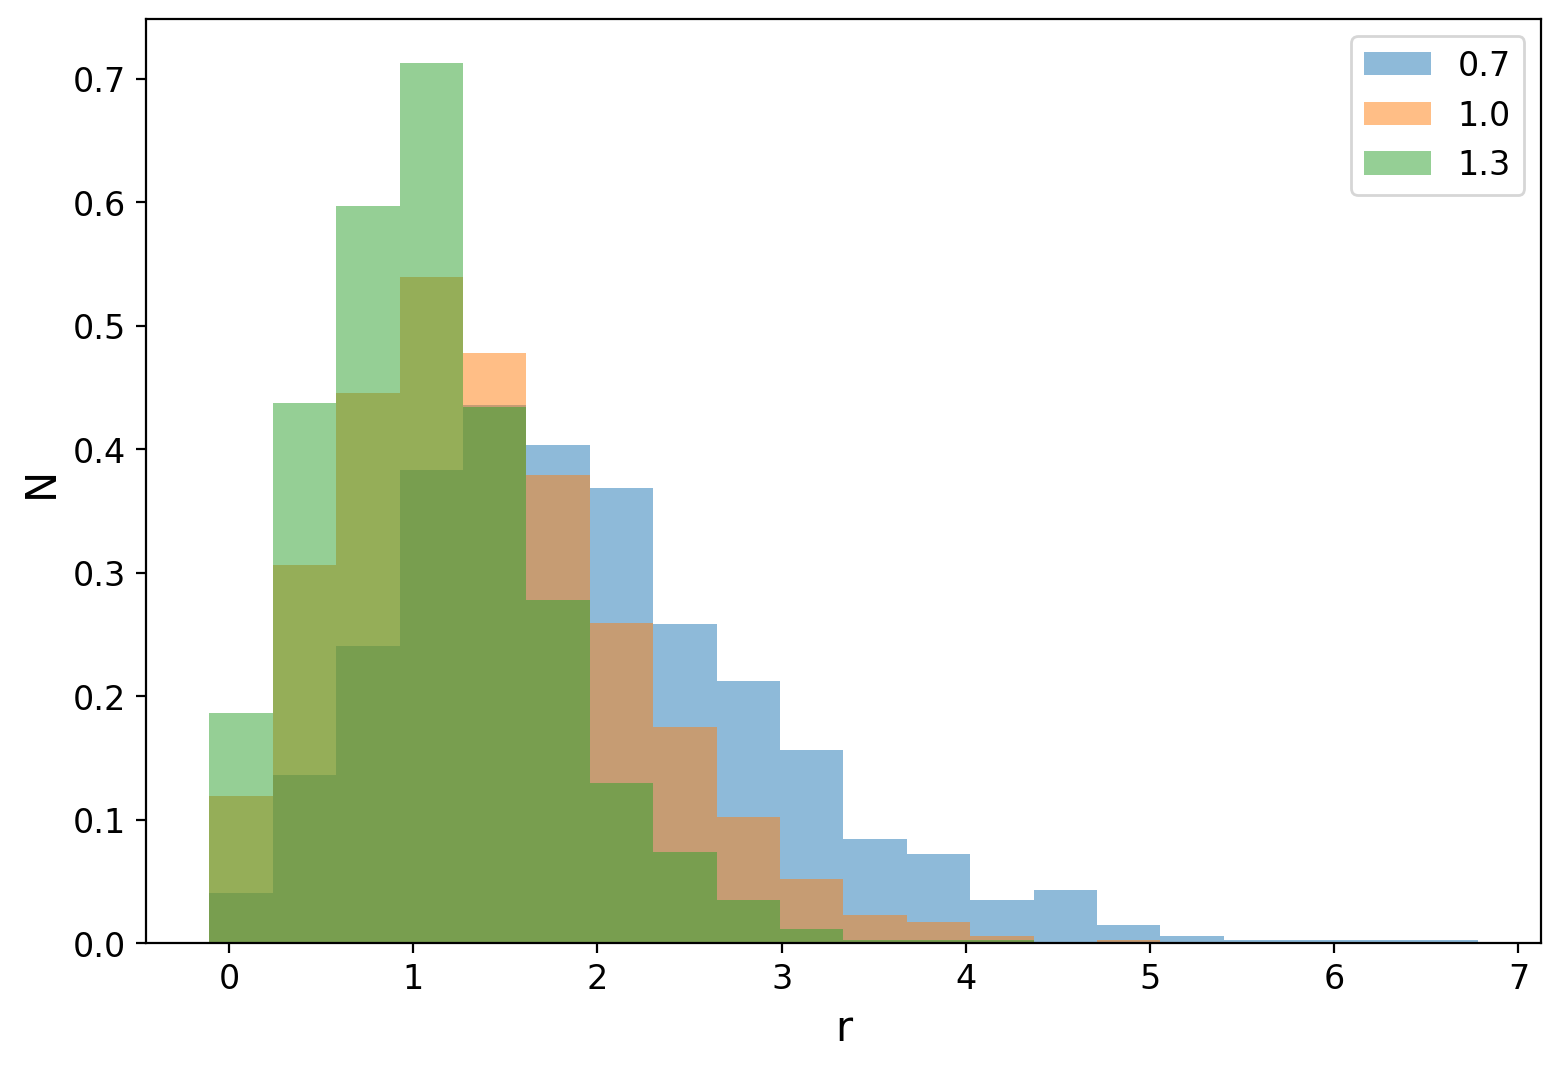

E [-0.45503223] [-0.5] [-0.45545824]


In [39]:
def variational(ialpha=1.0,iR=1.0,iNSteps=2000,iStepSize=0.5,iNSamps=1000):
    Rold=np.random.uniform(0,3,iNSamps)
    for step in range(iNSteps):
        rand=np.random.uniform(-1,1,iNSamps)
        Rnew=Rold+rand*iStepSize
        weight=(psi(ialpha,Rnew)/(psi(ialpha,Rold)+0.01))**2
        randpos=np.random.uniform(0.01,1,iNSamps)
        Rold = np.where(randpos < weight,Rnew,Rold)
    return Rnew,expect(ialpha,Rnew)

R07,E07=variational(0.7)
R10,E10=variational(1.0)
R13,E13=variational(1.3)

_,bins,_ = plt.hist(R07,bins=20,alpha=0.5,label='0.7',density=True)
plt.hist(R10,bins=bins,alpha=0.5,label='1.0',density=True)
plt.hist(R13,bins=bins,alpha=0.5,label='1.3',density=True)
plt.legend()
plt.xlabel("r")
plt.ylabel("N")
plt.show()
print("E",E07,E10,E13)


Ok, now lets finally, go ahead and vary $\alpha$ and the pdf distribution. We can use the above procedure except we will now modify our weight distribution by adding the probabilities for energy given by

$$
p_{e} = e^{-\beta H} \rightarrow w_{i+1} = \frac{p_{i+1}}{p_{i}}\frac{e^{-H_{i+1}}}{e^{-H_{i}}}\\
 w_{i+1} = \frac{\psi^{2}_{i+1}}{\psi^{2}_{i}}e^{H_{i}-H_{i+1}}
$$

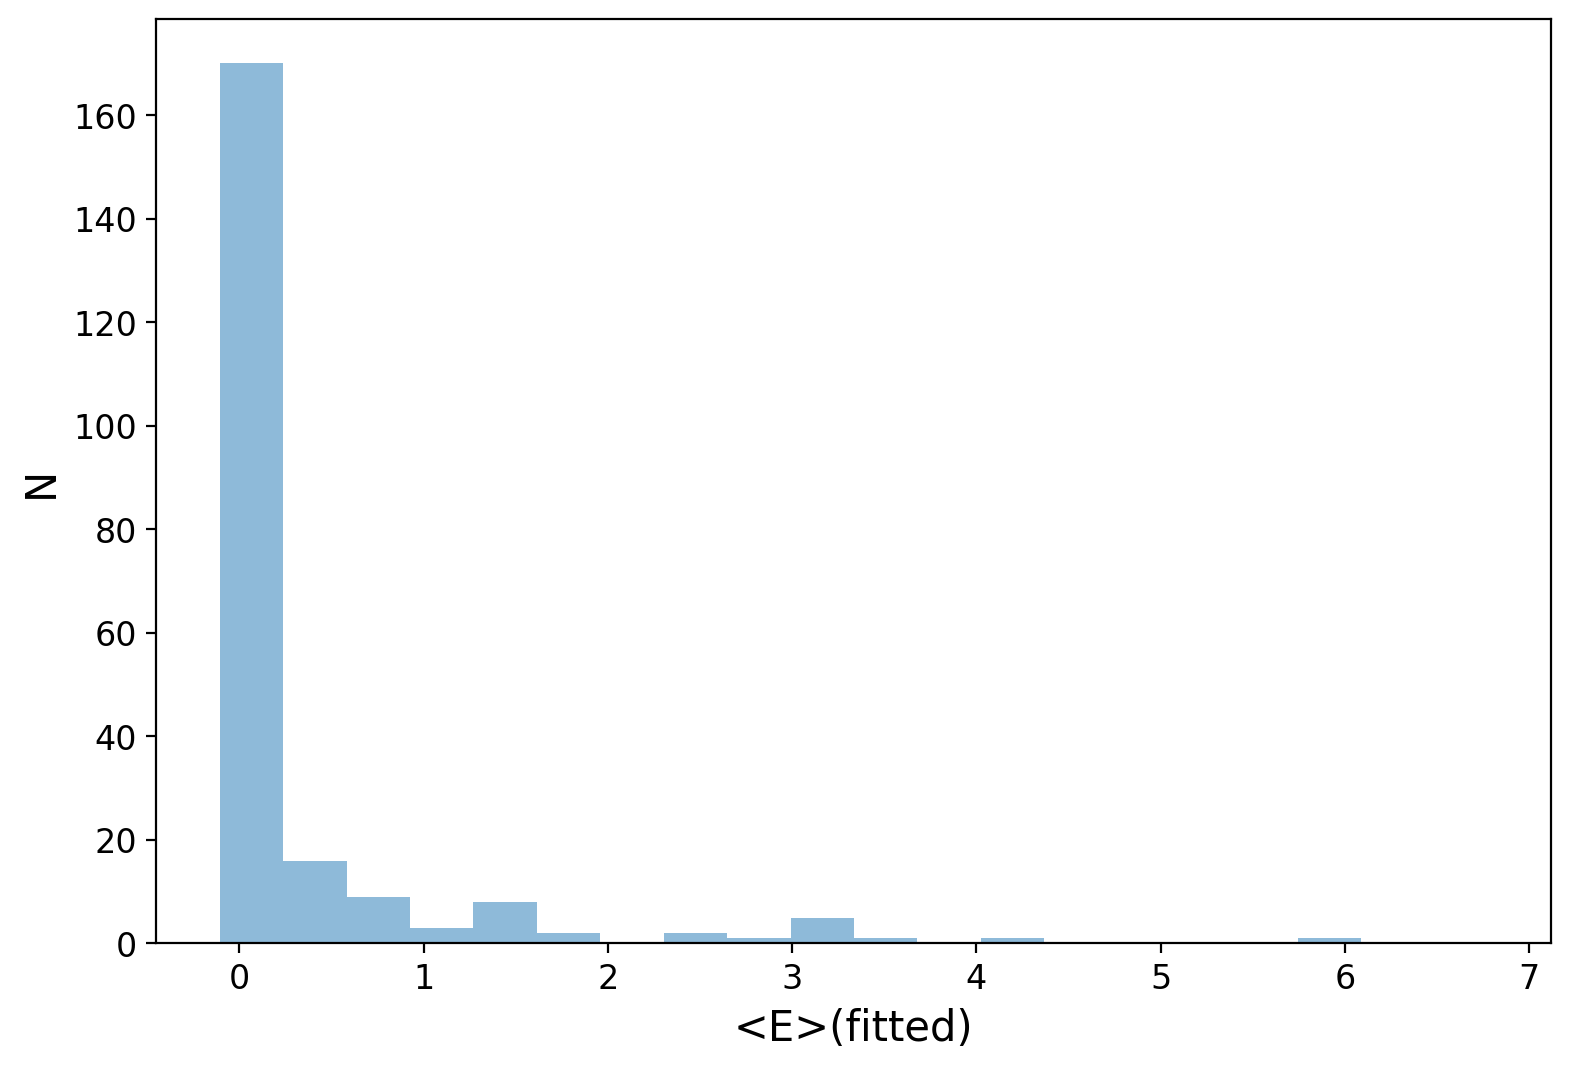

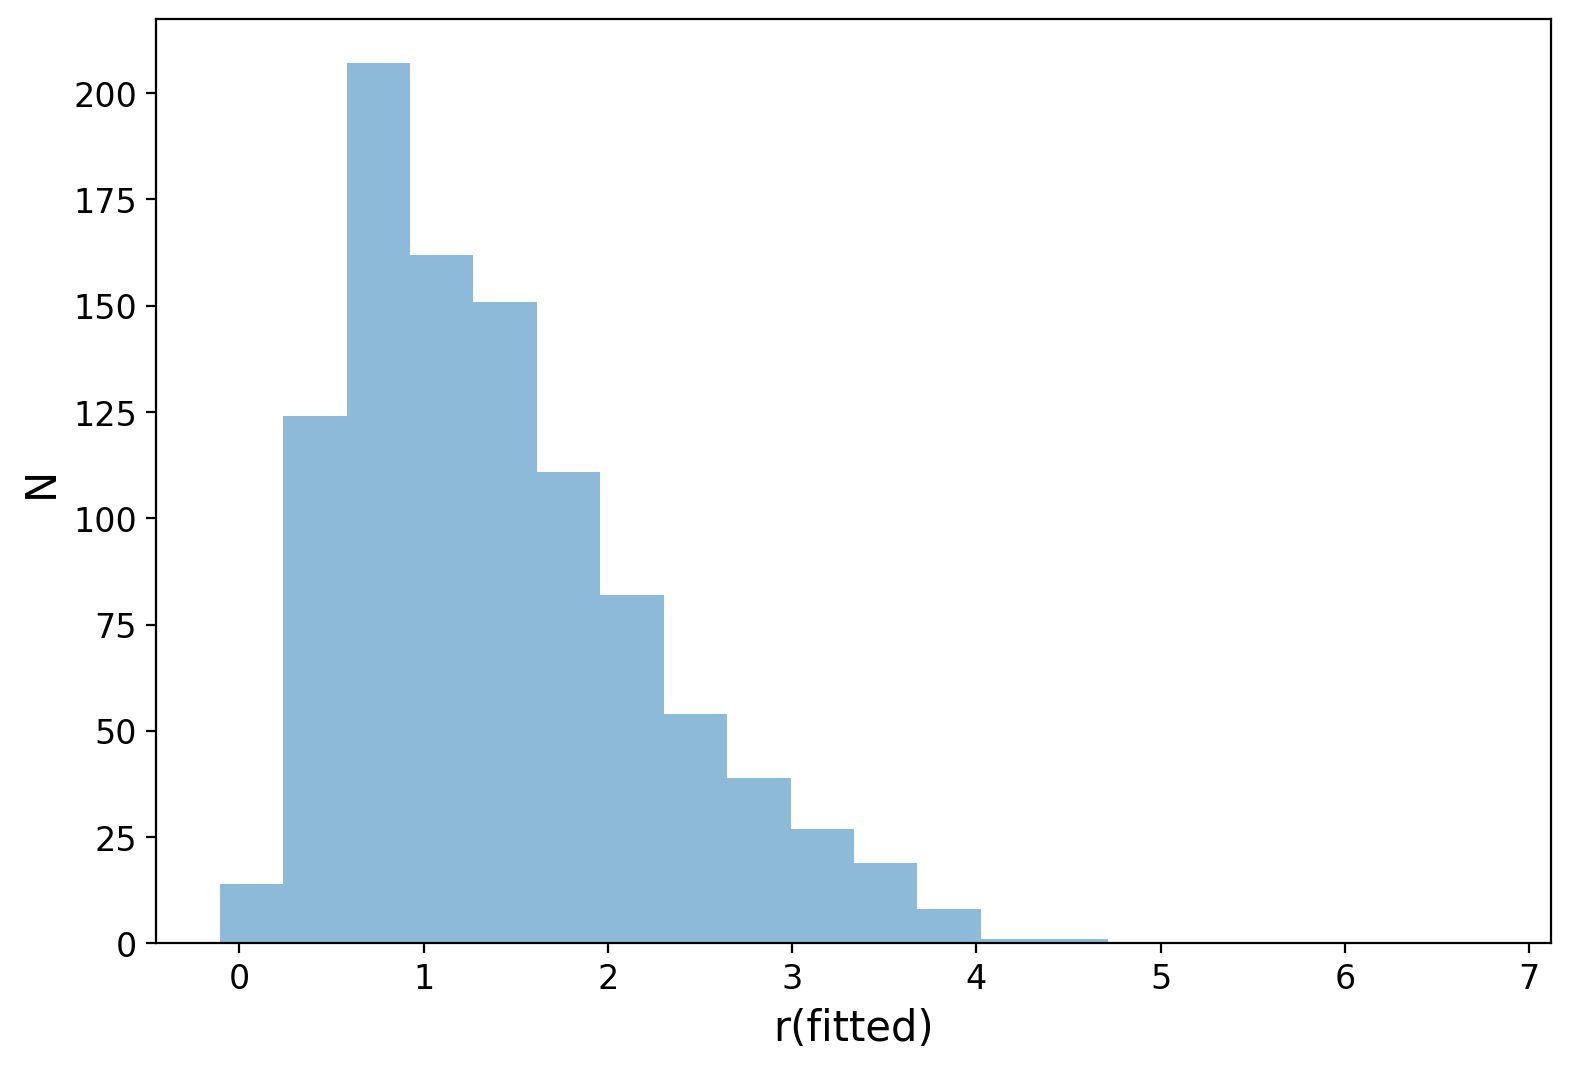

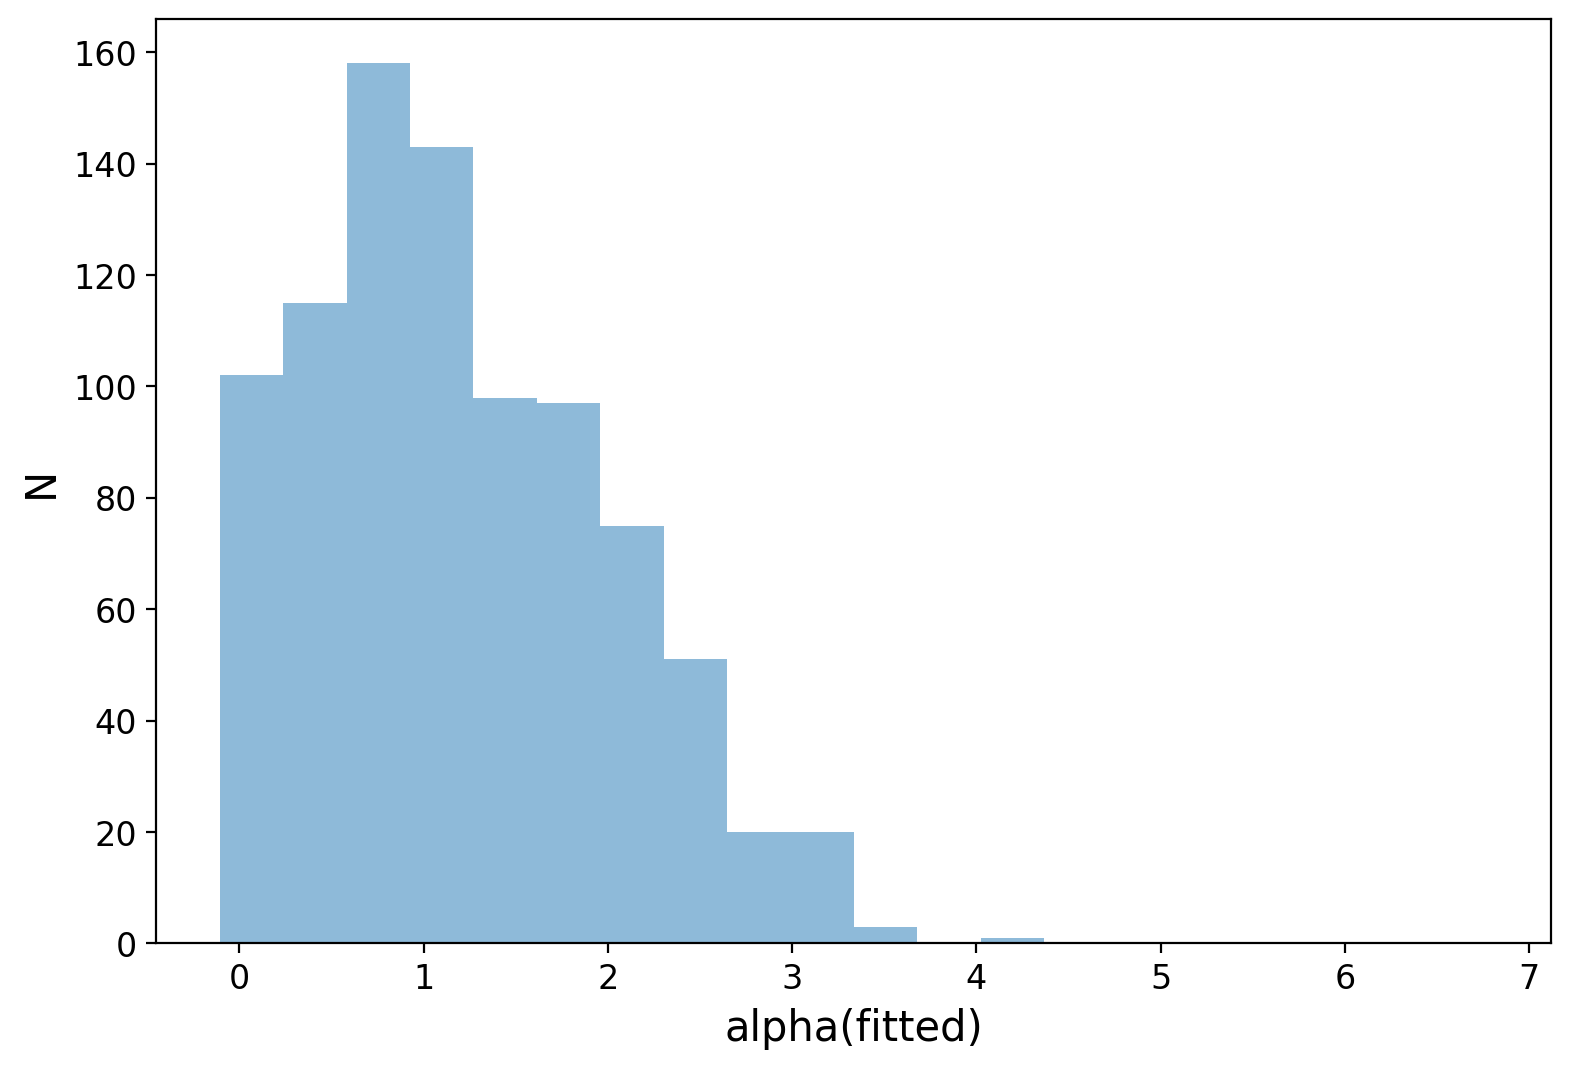

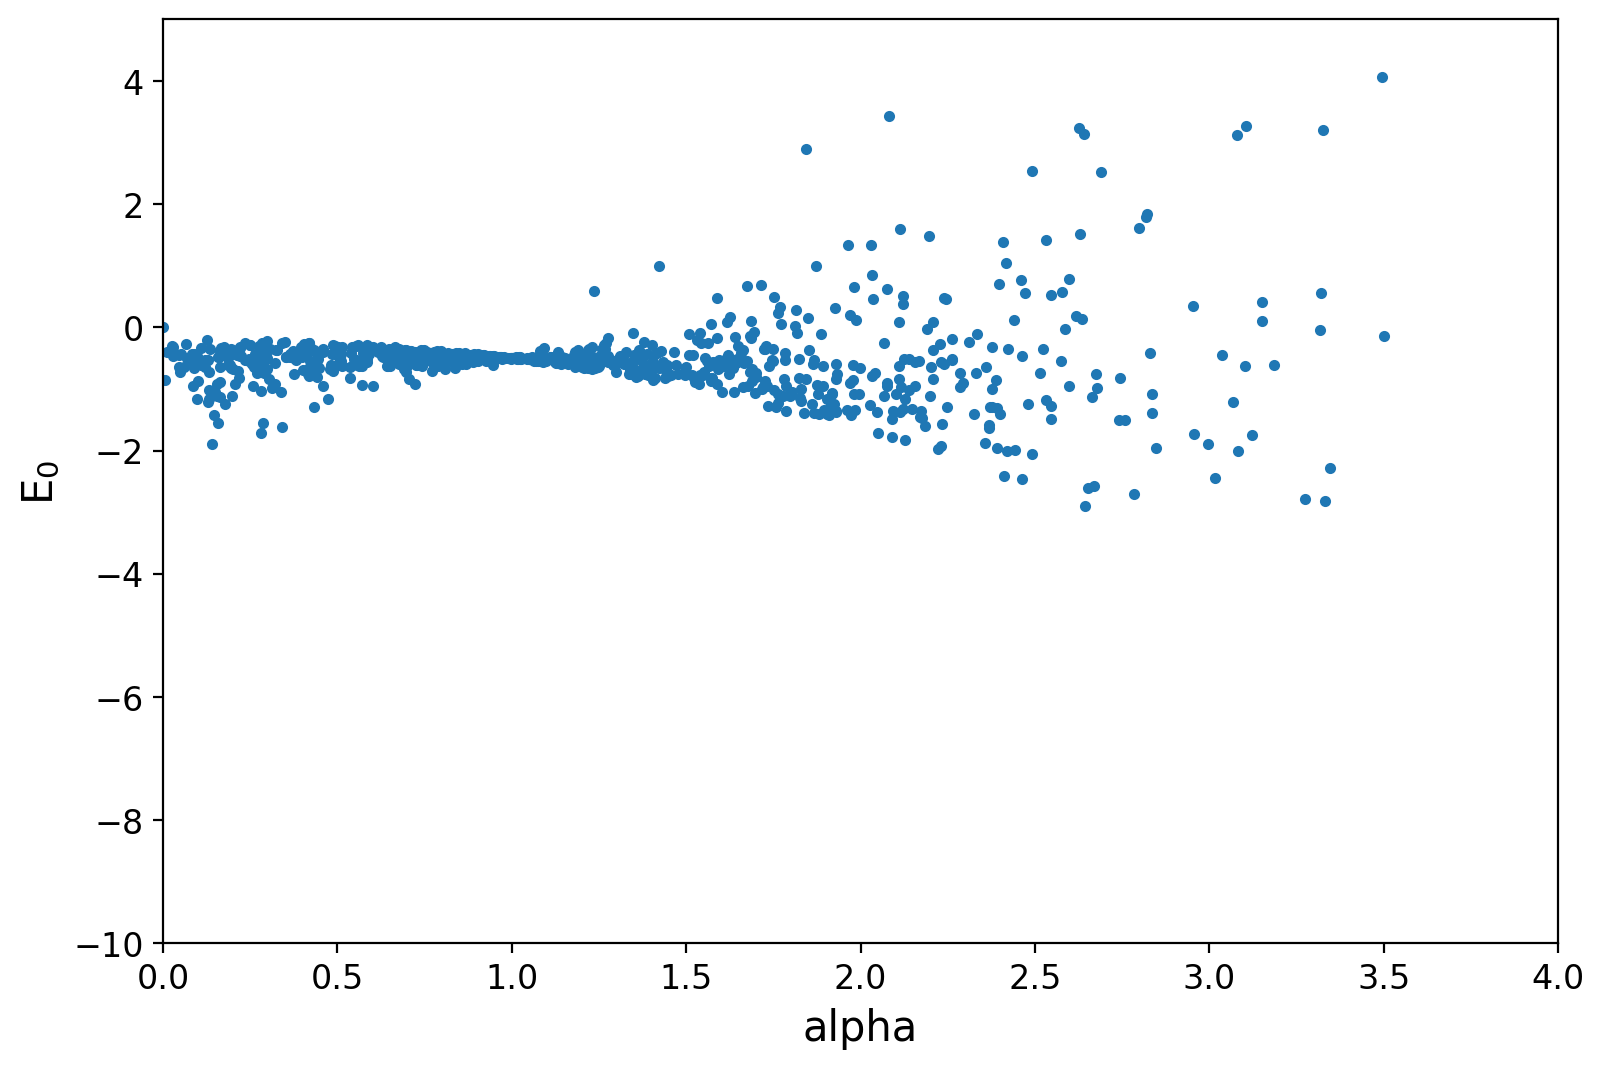

(58,)
(69,)
(65,)
(90,)
(94,)
(73,)
(77,)
(55,)
(63,)
(52,)
(43,)
(35,)
(28,)
(18,)


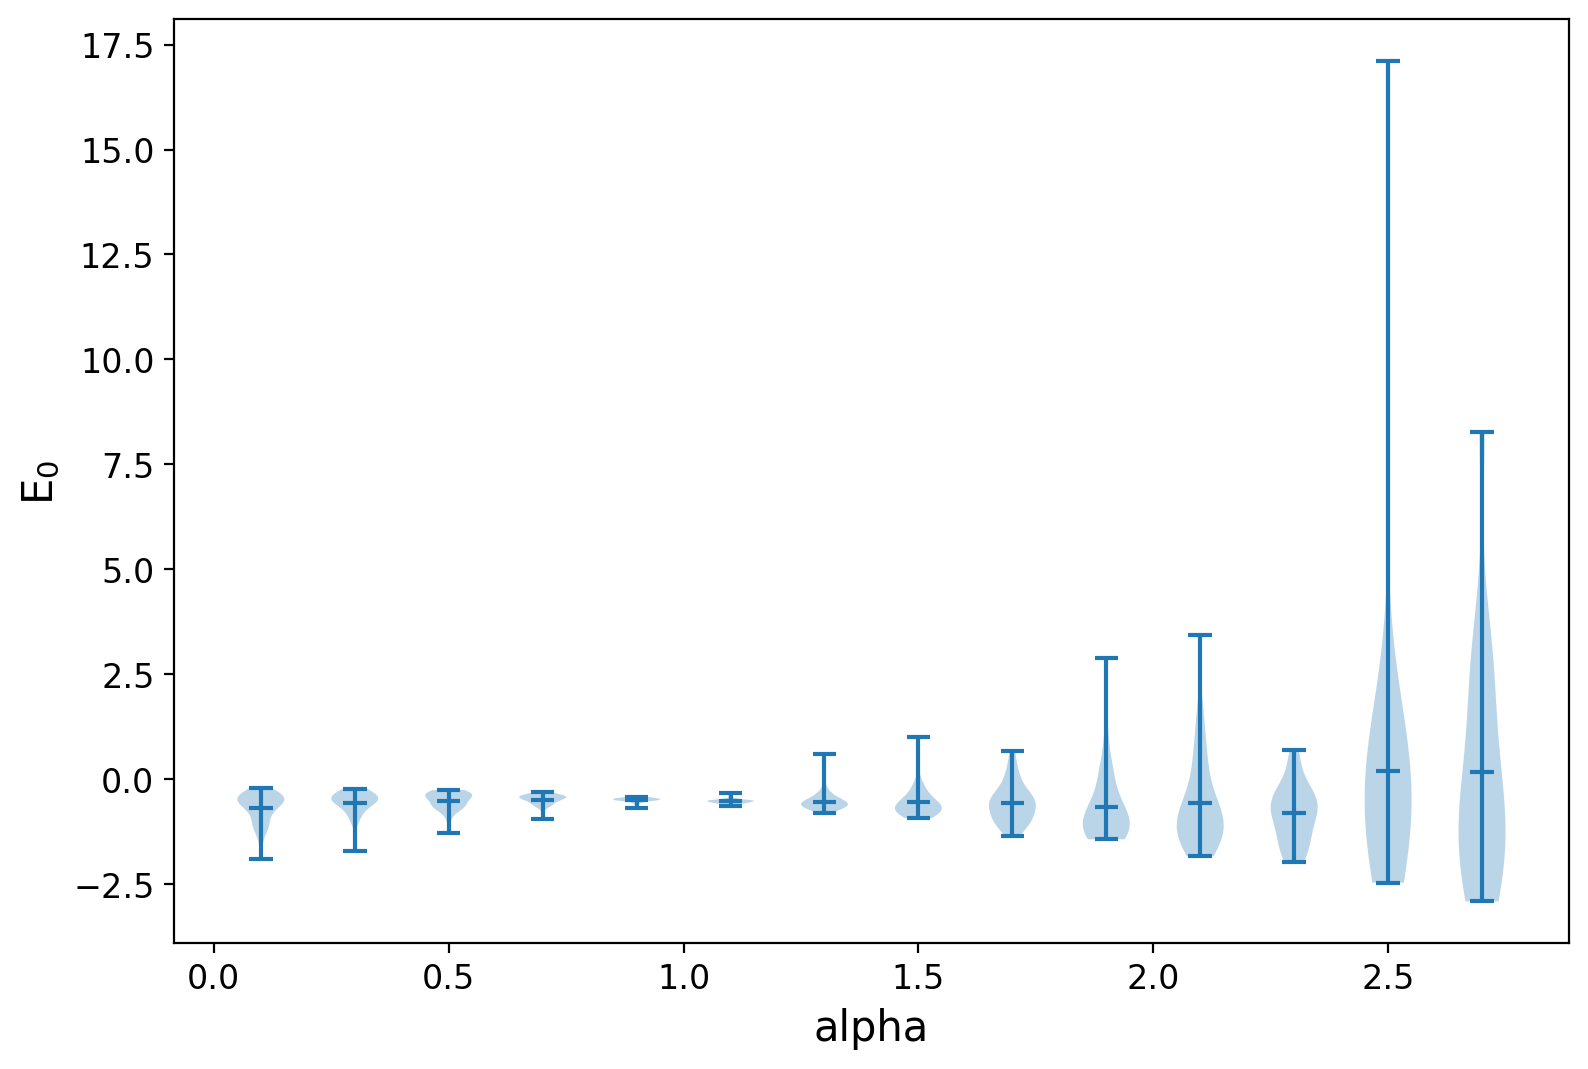

E -0.3995946690653419
alpha 0.9972511449099793
r 1.4145451098621435
alpha: 0.1 Emin -0.6722244143591813 std: 0.3546712203994202
alpha: 0.30000000000000004 Emin -0.5702189355915354 std: 0.299815635354722
alpha: 0.5 Emin -0.5164659401784282 std: 0.21568304061380755
alpha: 0.7000000000000001 Emin -0.4825628396752213 std: 0.12327177349404864
alpha: 0.9 Emin -0.484485580124976 std: 0.04938974948839006
alpha: 1.1 Emin -0.5168860755098368 std: 0.0531819865616729
alpha: 1.3000000000000003 Emin -0.536816316292467 std: 0.19376495337981936
alpha: 1.5 Emin -0.5480455750101655 std: 0.3398584945579488
alpha: 1.7000000000000002 Emin -0.5560713537765939 std: 0.4717761109139226
alpha: 1.9 Emin -0.6625085995467779 std: 0.8244743019722779
alpha: 2.1 Emin -0.5704519723015242 std: 1.0785065100485423
alpha: 2.3000000000000003 Emin -0.8104860479913037 std: 0.6947305592540353
alpha: 2.5 Emin 0.21046275360448868 std: 3.4832853584414547
alpha: 2.7 Emin 0.1737571375599775 std: 2.75567237502923


In [47]:
def expectFlat(ialpha,irvals=np.arange(0.01,30,0.01)):
    E0=np.sum(psi(ialpha,irvals)*minE0(ialpha,irvals)*psi(ialpha,irvals),axis=0)
    bot=np.sum(psi(ialpha,irvals)*psi(ialpha,irvals),axis=0)
    return E0/bot

def split(iAVals,iEVals):
    arange = np.arange(0,3,0.2)
    aesplit = []
    for i0 in range(len(arange)-1):
        avalL  = arange[i0]
        avalM  = arange[i0+1]
        pEVals = iEVals[(iAVals > avalL) & (iAVals < avalM) ]
        aesplit.append(pEVals)
        print(pEVals.shape)
    #print(aesplit)
    return arange,aesplit

def variational(iNSteps=25000,iStepSize=0.01,iNSamps=1000):
    alphas=np.random.uniform(0.5,1.4,iNSamps)
    Rold=np.random.uniform(0,3,iNSamps)
    for step in range(iNSteps):
        rand1=np.random.uniform(-1,1,iNSamps)
        Rnew=Rold+rand1*iStepSize
        rand2=np.random.uniform(-1,1,iNSamps)
        alphasNew=alphas+rand2*iStepSize
        weight1=(psi(alphas,Rnew)/(psi(alphas,Rold)+0.01))**2
        #weight1=(psi(alphasNew,Rnew)/(psi(alphas,Rold)+0.01))**2
        deltaE=minE0(alphas,Rold)-minE0(alphasNew,Rnew)
        weight2=np.exp(0.1*deltaE)
        randpos1=np.random.uniform(0.01,1,iNSamps)
        randpos2=np.random.uniform(0.01,1,iNSamps)
        Rold   = np.where(randpos1 < weight1,Rnew,Rold)
        alphas = np.where(randpos2 < weight2,alphasNew,alphas)
    return Rold,minE0(alphas,Rold),alphas

R10,E10,A10=variational()

plt.hist(E10,bins=bins,alpha=0.5)
plt.xlabel("<E>(fitted)")
plt.ylabel("N")
plt.show()

plt.hist(R10,bins=bins,alpha=0.5)
plt.xlabel("r(fitted)")
plt.ylabel("N")
plt.show()

plt.hist(A10,bins=bins,alpha=0.5)
plt.xlabel("alpha(fitted)")
plt.ylabel("N")
plt.show()

plt.plot(A10,E10,'.')
plt.ylim(-10,5)
plt.xlim(0,4)
plt.ylabel('E$_{0}$')
plt.xlabel('alpha')
plt.show()

ar,ae = split(A10,E10)
ac    = 0.5*(ar[:-1] + ar[1:])
#print('\n',ae.shape,ac.shape)
plt.violinplot(ae, ac, widths=0.1, showmeans=True,showextrema=True, showmedians=False, bw_method=0.5)
plt.ylabel('E$_{0}$')
plt.xlabel('alpha')
plt.show()

print("E",np.mean(E10))
print("alpha",np.mean(A10))
print("r",np.mean(R10))
for i0,evals in enumerate(ae):
    print("alpha:",ac[i0],"Emin",np.mean(evals),"std:",np.std(evals))

While we can see that there is a clear stability in our dataset. However, this variation is clearly biasing us, not populating the full wave function at each point. So whats the solution?

Let's go back a step.

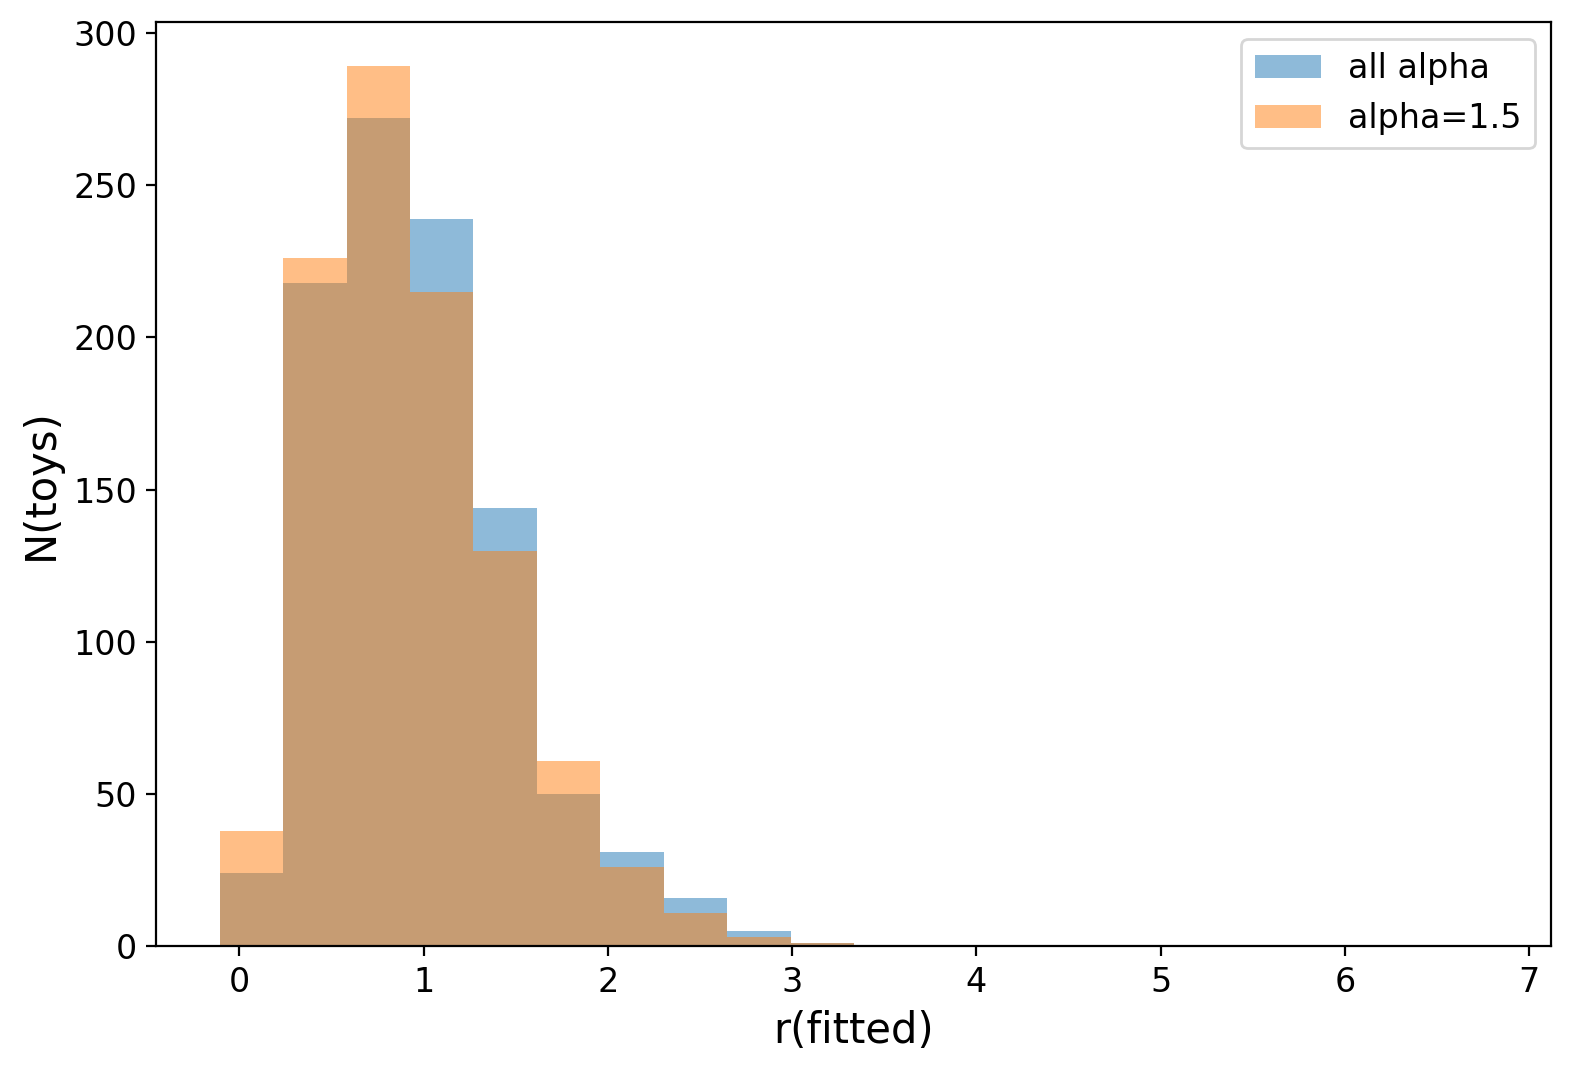

/var/folders/4t/mwl83f3x1ls0jvy35v4qzj7c0000gp/T/ipykernel_35937/2771332563.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


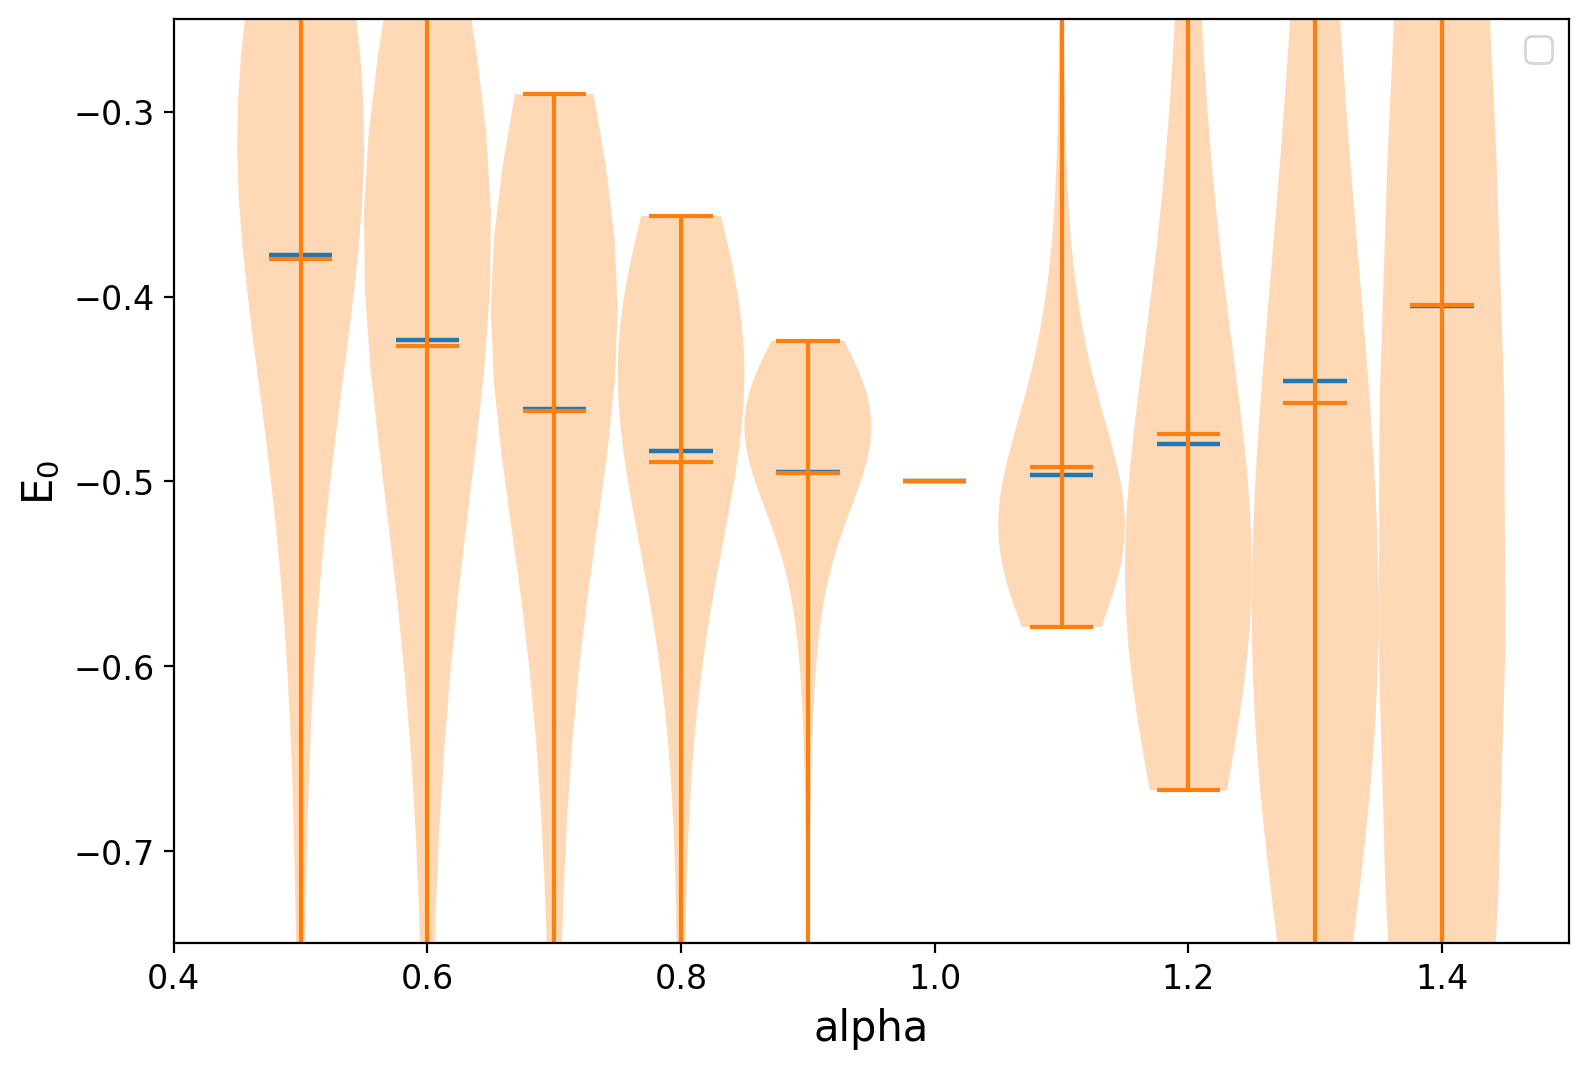

In [48]:
#compute the full integral
def variational(iNSteps=2000,iStepSize=0.5,iNSamps=10000):
    #fix alpha to 10 points
    alpharange=np.arange(0.5,1.5,0.1)
    lNSamps = int(iNSamps/len(alpharange))
    alphas = np.array([])
    for pAlpha in alpharange:
        alrange = pAlpha*np.ones(lNSamps)
        alphas = np.append(alphas,alrange)
    #now with fixed alpha solve for the wave function distribution
    Rold  =np.random.uniform(0,3,iNSamps)
    for step in range(iNSteps):
        rand1=np.random.uniform(-1,1,iNSamps)
        Rnew=Rold+rand1*iStepSize
        weight1=(psi(alphas,Rnew)/(psi(alphas,Rold)+0.01))**2
        randpos1=np.random.uniform(0.01,1,iNSamps)
        Rold   = np.where(randpos1 < weight1,Rnew,Rold)
    return Rold,minE0(alphas,Rold),alphas


#compute just the expected energy
def variationalOne(ialpha=1.0,iNSteps=2000,iStepSize=0.5,iNSamps=1000):
    Rold=np.random.uniform(0,3,iNSamps)
    for step in range(iNSteps):
        rand=np.random.uniform(-1,1,iNSamps)
        Rnew=Rold+rand*iStepSize
        weight=(psi(ialpha,Rnew)/(psi(ialpha,Rold)+0.01))**2
        randpos=np.random.uniform(0.01,1,iNSamps)
        Rold = np.where(randpos < weight,Rnew,Rold)
    return Rold,expect(ialpha,Rold)


R10,E10,A10=variational()
R15,E15=variationalOne(1.5)
plt.hist(R10[-1000:],bins=bins,alpha=0.5,label='all alpha')
plt.hist(R15,bins=bins,alpha=0.5,label='alpha=1.5')
plt.xlabel('r(fitted)')
plt.ylabel('N(toys)')
plt.legend()
plt.show()

#ar,ae = split(A10,E10)
#ac    = 0.5*(ar[:-1] + ar[1:])
ac = np.arange(0.5,1.5,0.1)
ae = np.reshape(E10,(10,1000))
ae1 = []
ae2 = []
for i0 in range(ae.shape[0]):
    pR,pE=variationalOne(ac[i0])
    ae1.append(pE)
    ae2.append(ae[i0])
plt.violinplot(ae1, ac, widths=0.1, showmeans=True,showextrema=True, showmedians=False, bw_method=0.5)
plt.violinplot(ae2, ac, widths=0.1, showmeans=True,showextrema=True, showmedians=False, bw_method=0.5)
plt.ylabel('E$_{0}$')
plt.xlabel('alpha')
plt.ylim(-0.75,-0.25)
plt.legend()
plt.show()


Alright, so our conclusion from all of this is that MCMC is a good way to populate a wave function. What this really means is that its a good way to compute an integral without going through the pain of analytically integrating. As we saw above the key here is to be able to ensure that we populate the phase space with the right proability. Using Metropolis to populate, provided we have a good notion of the ratio of probabilities is a great way to do this.

Now, in the above, we showed a solution to the Hydrogen Atom. It shouldn't come as a surpise to anybody that the wave equation solution to the Hydrogen atom is an exponential of the above form. In. light of this, what we can now consider is an approximte solution to an equation that doesn't have a perfect form. This solution is the solution to the Helium Atom. Let's go ahead and do this.

The Helium atom has a potential akin ot our n-body equations that we were solving a few classes ago. The Hamiltonian for that is :

$$
r_{12} = \left|\vec{r_{1}} - \vec{r_{2}}\right| \\
\mathcal{H} = \frac{p_{1}^2}{2m} + \frac{p_{2}^2}{2m} - \frac{2ke^2}{r_{1}} - \frac{2ke^2}{r_{2}} + \frac{ke^2}{r_{12}}  \\
\hat{\mathcal{H}} = \frac{\hbar\nabla^2}{2m} + \frac{\hbar\nabla^2}{2m} - \frac{2ke^2}{r_{1}} - \frac{2ke^2}{r_{2}} + \frac{ke^2}{r_{12}}  
$$
The solution to the Shroedinger's equation is not an anlytic form and it has been approximated through various perturbative methods to get the form of the interactions. The key issue here is that there is this repulsive term between the electrons $r_{12}$ that makes the modelling particularly difficult.

To make a long story short, we can make an intellectual guess for the shape of the atom by assuming an approximate functional form given by


$$
\psi\left(\vec{r_{1}},\vec{r_{2}}\right) = A \exp\left(-\alpha\left(r_{1} + r_{2}\right) - \frac{1}{2} \frac{r_{12}}{1+\beta r_{12}} \right)
$$

Now applying the above equation to Schroedinger's equation above using natural units, we can solve for the Energy under this functional form assumption.

This gives us:


$$
E_{1} \psi  = \left(\left(\alpha - Z\right)\left(\frac{1}{r_{1}} + \frac{1}{r_{2}} \right)  + \frac{1}{r_{12}}-\alpha^{2}\right)\psi
$$

This is an example based on this link [here](http://compphysics.github.io/ComputationalPhysics2/doc/pub/vmc/html/vmc-bs.html)

Now what we can do is go ahead and code up this setup. Since we are now dealing with two particles, our problem goes from a 1 dimensional problem in $\r$ to a 2 dimensional problem in the plan of both of the particles.

0.5
0.75
1.0
1.25
1.5
1.75
2.0
2.25
2.5
2.75
3.0
3.25
3.5
3.75


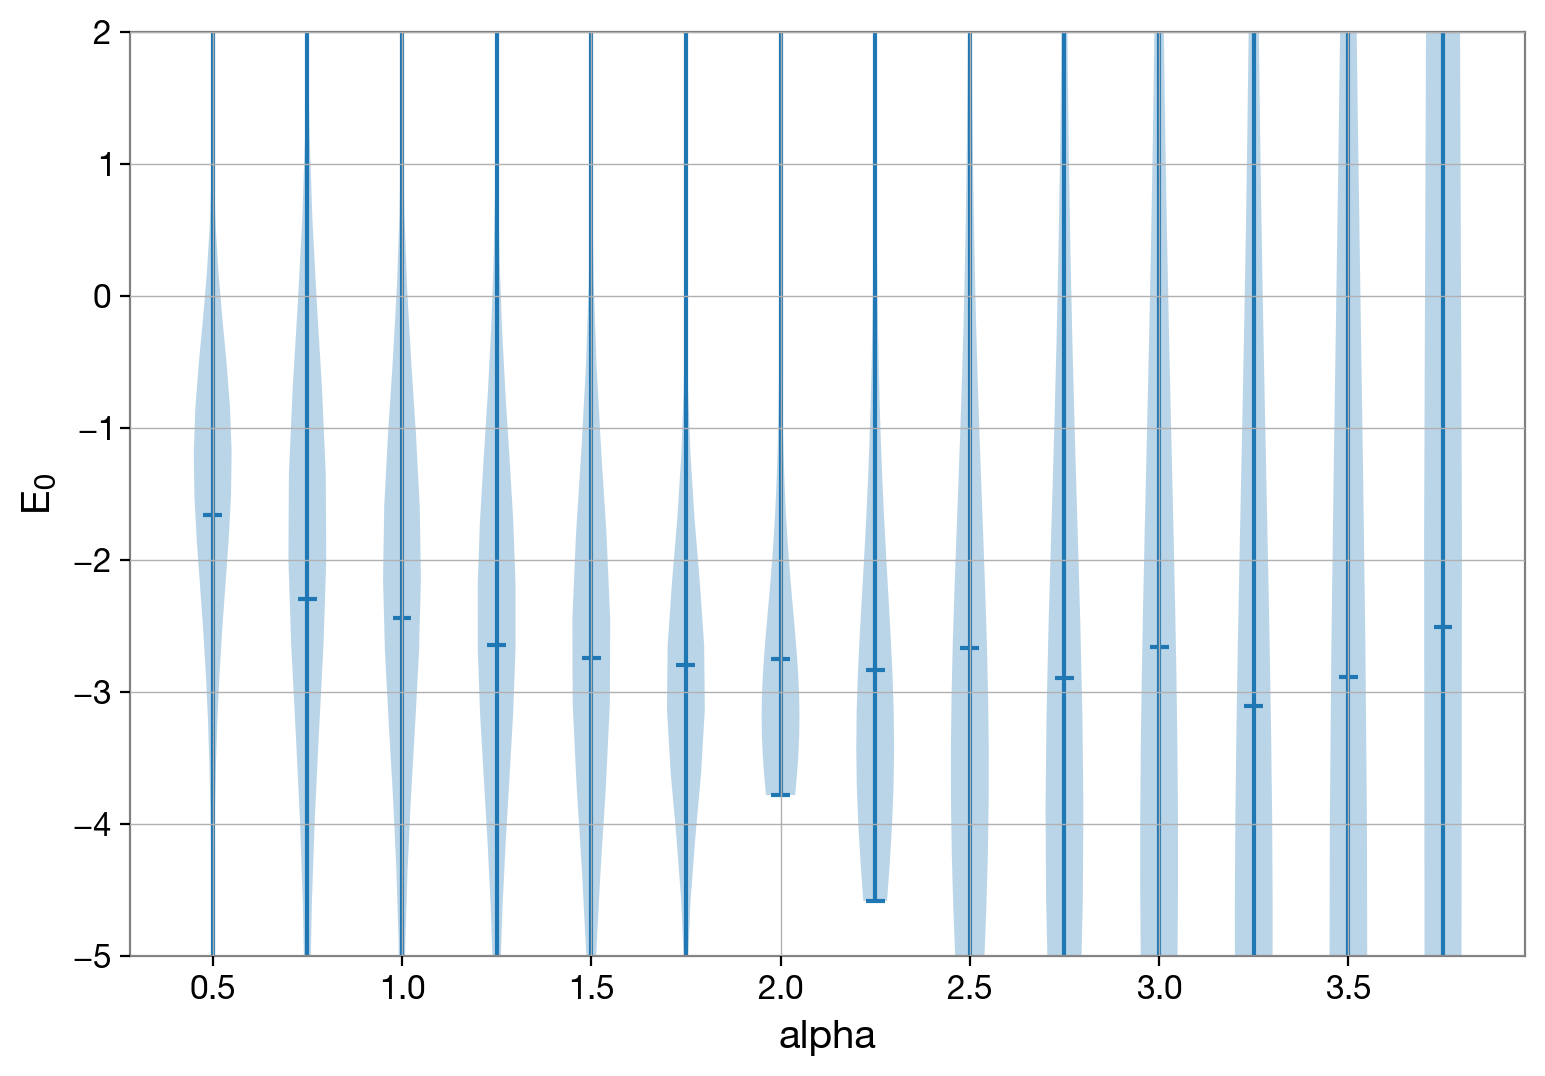

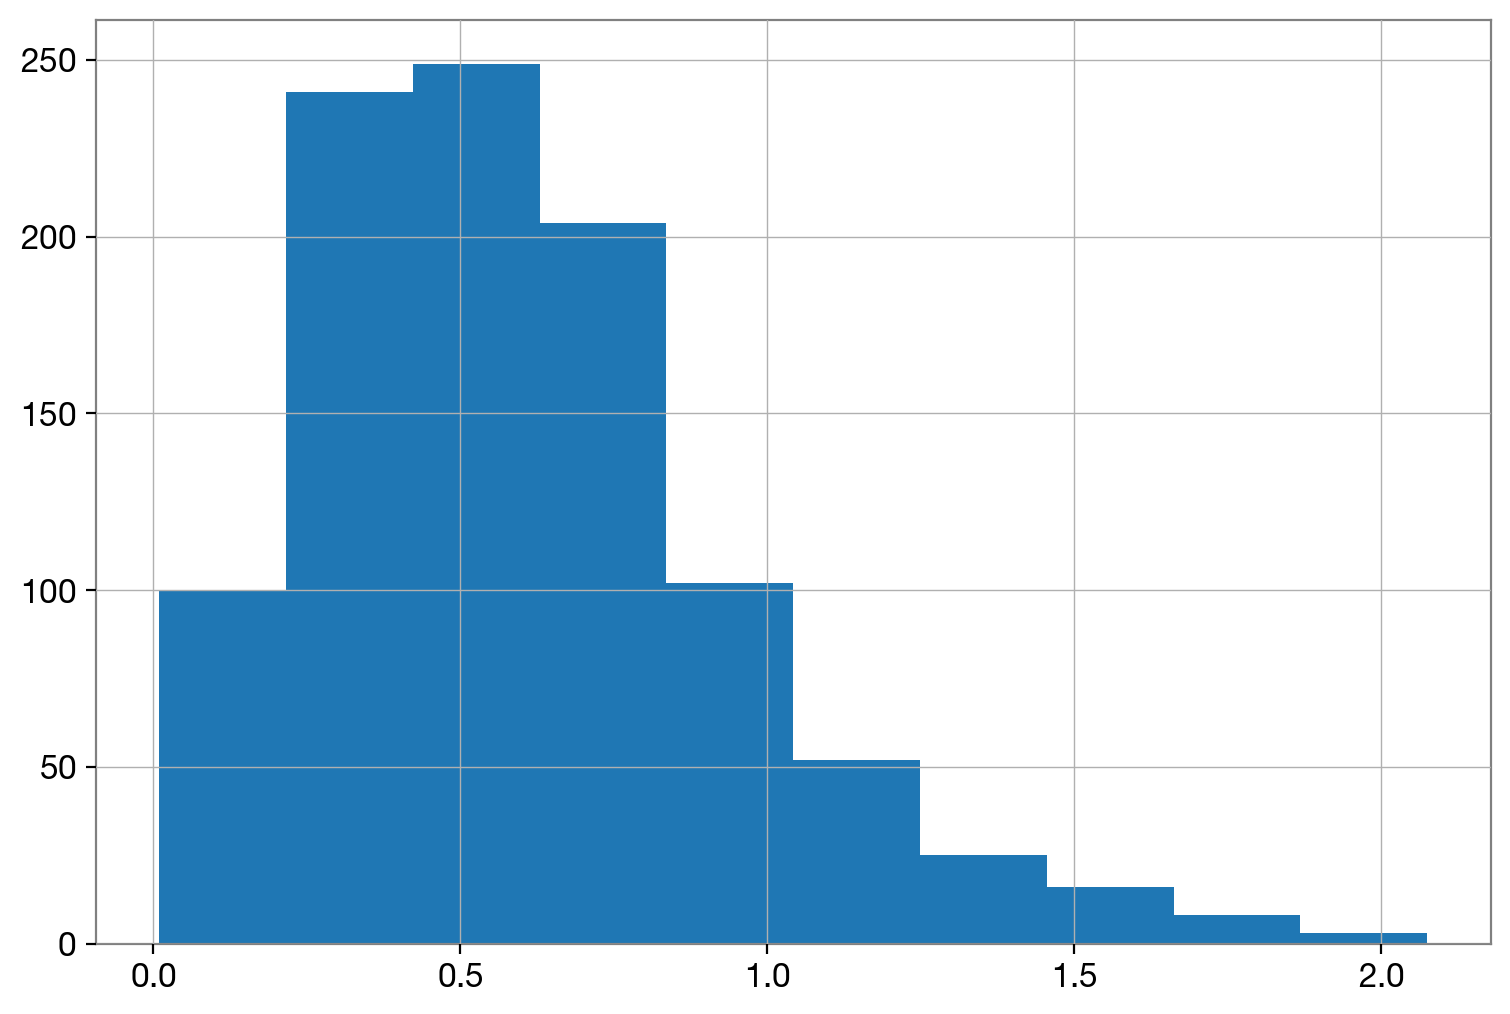

In [151]:
def psi(r,alpha,beta): #input r[0,0],r[0,1] = part 1 x and y => r[1,0],r[1,1] = part 2 x and y
    r1 = np.sqrt(r[:,0,0]**2 + r[:,0,1]**2)
    r2 = np.sqrt(r[:,1,0]**2 + r[:,1,1]**2)
    #r12 = np.sqrt((r[:,0,0]-r[:,1,0])**2 + (r[:,0,1]-r[:,1,1])**2)
    #d = r12/(1+beta*r12)
    return np.exp(-0.5*alpha*(r1+r2))#+d)

def minE0(r,alpha,beta):
    r1 = np.sqrt(r[:,0,0]**2 + r[:,0,1]**2)
    r2 = np.sqrt(r[:,1,0]**2 + r[:,1,1]**2)
    r12 = np.sqrt((r[:,0,0]-r[:,1,0])**2 + (r[:,0,1]-r[:,1,1])**2)
    #deno = 1.0/(1+beta*r12)
    #deno2 = deno*deno
    return (alpha-2)*(1./r1 + 1./r2) + 1./r12 -alpha**2 #+ 1.0/r12+deno2*(alpha*r12-deno2+2*beta*deno-1.0/r12)


def variationalHe(ialpha=1.0,ibeta=1.0,iR=1.0,iNSteps=10000,iStepSize=0.5,iNSamps=1000):
    Rold = np.zeros((iNSamps,2,2), np.double)
    Rnew = np.zeros((iNSamps,2,2), np.double)
    Rold = np.random.uniform(-1,1,Rold.shape)*iStepSize
    for step in range(iNSteps):
        rand=np.random.uniform(-1,1,Rold.shape)
        Rnew=Rold+rand*iStepSize
        weight=(psi(Rnew,ialpha,ibeta)/(psi(Rold,ialpha,ibeta)+0.01))**2
        randpos=np.random.uniform(0.01,1,iNSamps)
        updaterows = np.where(randpos < weight)
        Rold[updaterows] = Rnew[updaterows]
    return Rnew,minE0(Rnew,ialpha,ibeta)

alphascan = np.arange(0.5,4.0,0.25)
escan = []
for alpha in alphascan:
    print(alpha)
    pR,pE=variationalHe(alpha)
    escan.append(pE)

plt.violinplot(escan, alphascan, widths=0.1, showmeans=True,showextrema=True, showmedians=False, bw_method=0.5)
plt.ylabel('E$_{0}$')
plt.xlabel('alpha')
plt.ylim(-5,2)
plt.show()

pR,pE=variationalHe(alpha)
plt.hist( np.sqrt(pR[:,0,0]**2 + pR[:,0,1]**2) )
plt.show()

Ok, now we can go with the full "modern-ish" approximation of the Helium atom. We can write the wave equation for this as :

$$
\psi\left(\vec{r_{1}},\vec{r_{2}}\right) = A \exp\left(-\alpha\left(r_{1} + r_{2}\right) - \frac{1}{2} \frac{r_{12}}{1+\beta r_{12}} \right)
$$


We can also write the energy for the updated system as:

$$
E_{2} \psi  = E_{1} \psi + \frac{1}{\left(1+\beta r_{12}\right)^{2}}\left( -\frac{1}{r_{12}} + \frac{\beta}{\left(1+\beta r_{12}\right)} - \frac{1}{4}\left(\frac{1}{1+\beta r_{12}}\right)^{2}  + \alpha\hat{r}_{12}\cdot\left(\hat{r_{1}}-\hat{r_{2}}\right) \right)\psi
$$


NameError: name 'FormatStrFormatter' is not defined

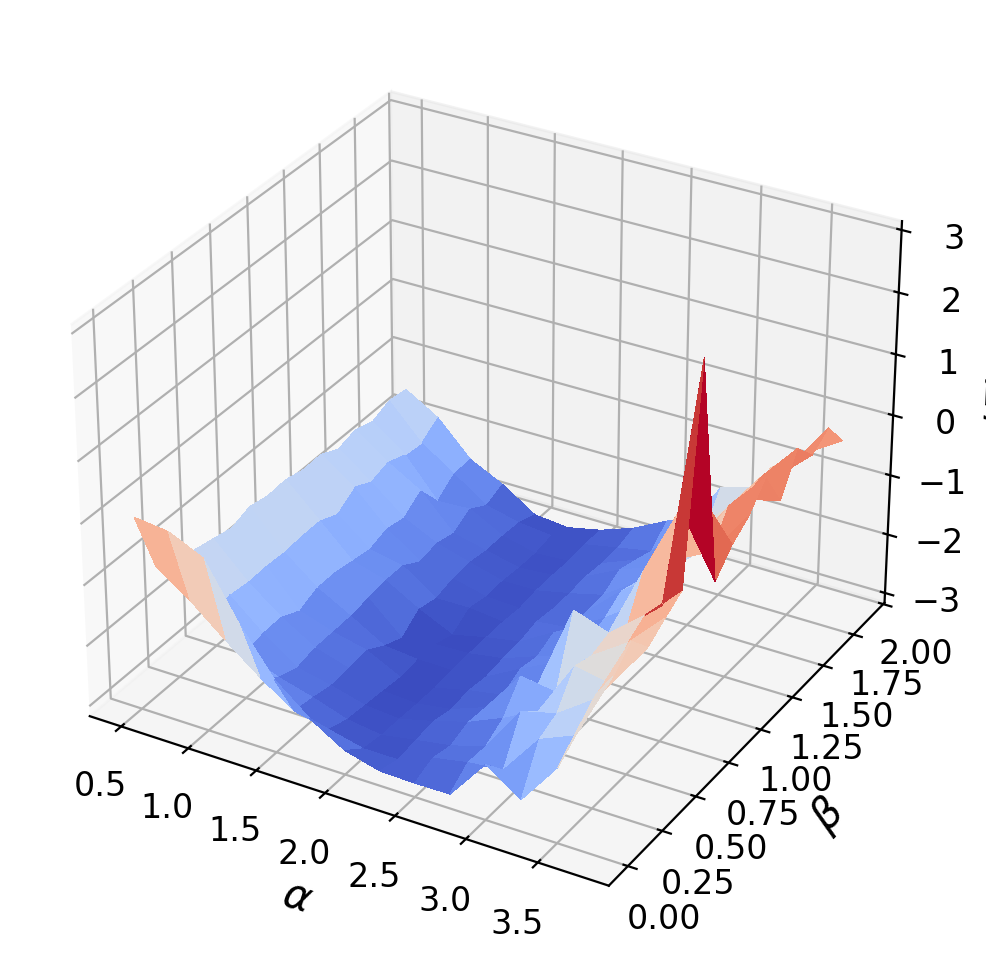

In [49]:

def psi(r,alpha,beta): #input r[0,0],r[0,1] = part 1 x and y => r[1,0],r[1,1] = part 2 x and y
    r1 = np.sqrt(r[:,0,0]**2 + r[:,0,1]**2)
    r2 = np.sqrt(r[:,1,0]**2 + r[:,1,1]**2)
    r12 = np.sqrt((r[:,0,0]-r[:,1,0])**2 + (r[:,0,1]-r[:,1,1])**2)
    d = r12/(1+beta*r12)
    return np.exp(-0.5*alpha*(r1+r2)+0.5*d)

def minE0(r,alpha,beta):
    r1 = np.sqrt(r[:,0,0]**2 + r[:,0,1]**2)
    r2 = np.sqrt(r[:,1,0]**2 + r[:,1,1]**2)
    r12 = np.sqrt((r[:,0,0]-r[:,1,0])**2 + (r[:,0,1]-r[:,1,1])**2)
    dr12hatx = (r[:,0,0]/r1-r[:,1,0]/r2)*(r[:,0,0]-r[:,1,0])/r12#r12x*(r1x-r2x)
    dr12haty = (r[:,0,1]/r1-r[:,1,1]/r2)*(r[:,0,1]-r[:,1,1])/r12#r12y*(r1y-r2y)
    d    = 1.0/(1+beta*r12)
    E1   = (alpha-2)*(1./r1 + 1./r2) + 1./r12 -alpha**2
    E2   = (d**2)*(-1/r12 + beta*d - 0.25*d**2 + 0.5*alpha*(dr12hatx+dr12haty))
    return E1 + E2

def variationalHe(ialpha=1.0,ibeta=1.0,iR=1.0,iNSteps=10000,iStepSize=1.0,iNSamps=1000):
    Rold = np.zeros((iNSamps,2,2), np.double)
    Rnew = np.zeros((iNSamps,2,2), np.double)
    Rold = np.random.uniform(-2,2,Rold.shape)*iStepSize
    Eavg = np.zeros(iNSteps)
    for step in range(iNSteps):
        rand=np.random.uniform(-1,1,Rold.shape)
        Rnew=Rold+rand*iStepSize
        weight=(psi(Rnew,ialpha,ibeta)/(psi(Rold,ialpha,ibeta)))**2
        randpos=np.random.uniform(0.0,1,iNSamps)
        updaterows = np.where(randpos < weight)
        Rold[updaterows] = Rnew[updaterows]
        Eavg[step] = np.mean(minE0(Rold,ialpha,ibeta))
    return Rold,minE0(Rold,ialpha,ibeta),Eavg

alphascan = np.arange(0.5,4.0,0.25)
betascan  = np.arange(0.0,2.0,0.125)
#alphascan = np.arange(0.5,4.0,0.5)
#betascan  = np.arange(0.0,2.0,1.0)
coords = []
escan = []
X, Y = np.meshgrid(alphascan, betascan)
eavg = np.zeros(X.shape)
for i0,beta in enumerate(betascan):
    for i1,alpha in enumerate(alphascan):
        pR,pE,pEAvg=variationalHe(alpha,beta)
        escan.append(pE)
        eavg[i0,i1] = np.mean(pE[-2000:])
        coords.append(np.array([alpha,beta]))

# Prepare for plots

import matplotlib.cm as cm
fig = plt.figure()
ax = plt.axes(projection="3d")
# Plot the surface.
surf = ax.plot_surface(X, Y, eavg,cmap=cm.coolwarm,linewidth=0, antialiased=False)
# Customize the z axis.
zmin = np.matrix(eavg).min()
zmax = np.matrix(eavg).max()
ax.set_zlim(zmin, zmax)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\beta$')
ax.set_zlabel(r'$\langle E \rangle$')
#ax.zaxis.set_major_locator(LinearLocator(10))
#ax.zaxis.set_major_formatter(FormatStrFormatter('%.02f'))
# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

# Prepare for plots
fig = plt.figure()
ax = plt.axes()
# Plot the surface.
plt.pcolor(X, Y, eavg,cmap=cm.coolwarm)
# Customize the z axis.
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\beta$')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

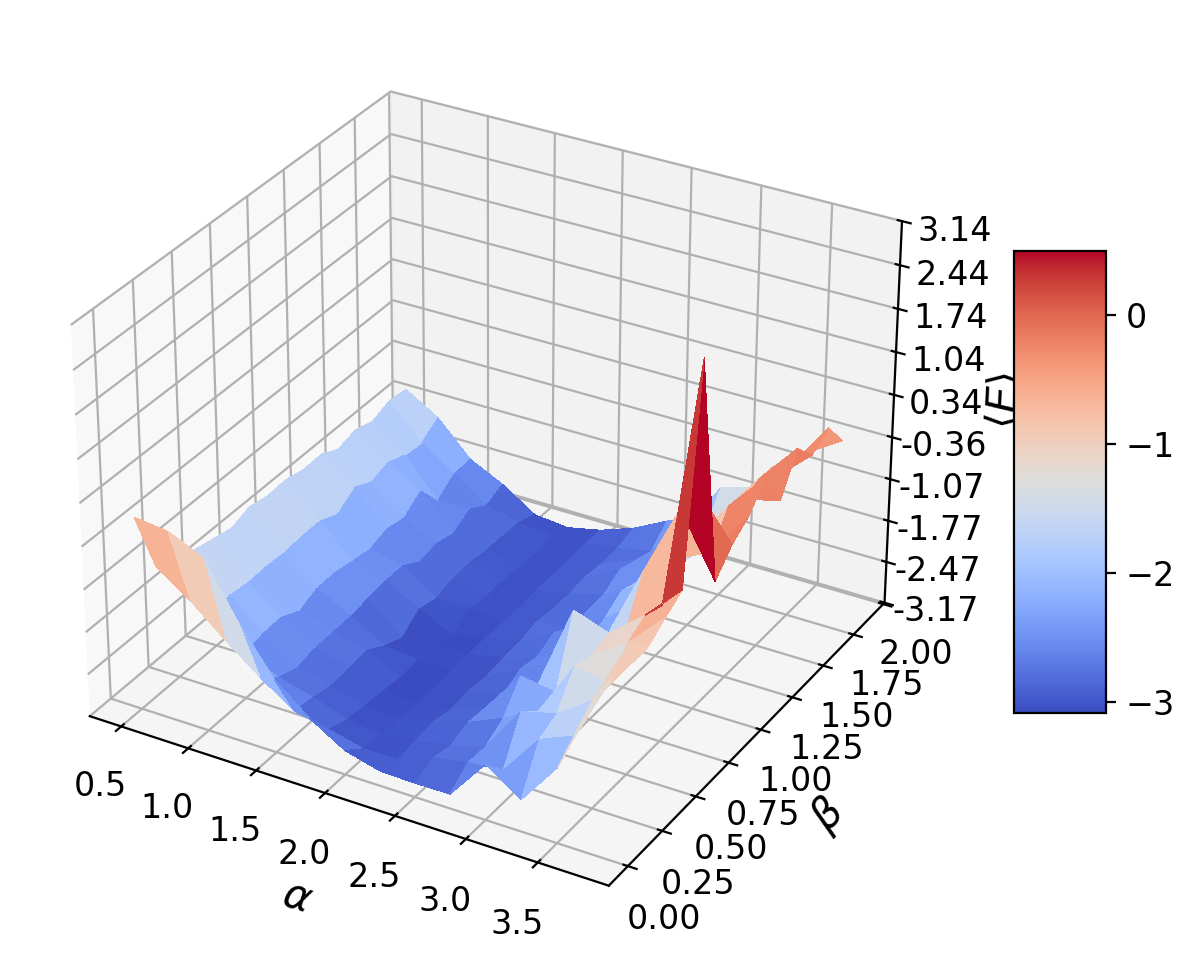

/var/folders/4t/mwl83f3x1ls0jvy35v4qzj7c0000gp/T/ipykernel_35937/2874043128.py:30: UserWarning: Adding colorbar to a different Figure <Figure size 900x600 with 3 Axes> than <Figure size 900x600 with 1 Axes> which fig.colorbar is called on.
  fig.colorbar(surf, shrink=0.5, aspect=5)


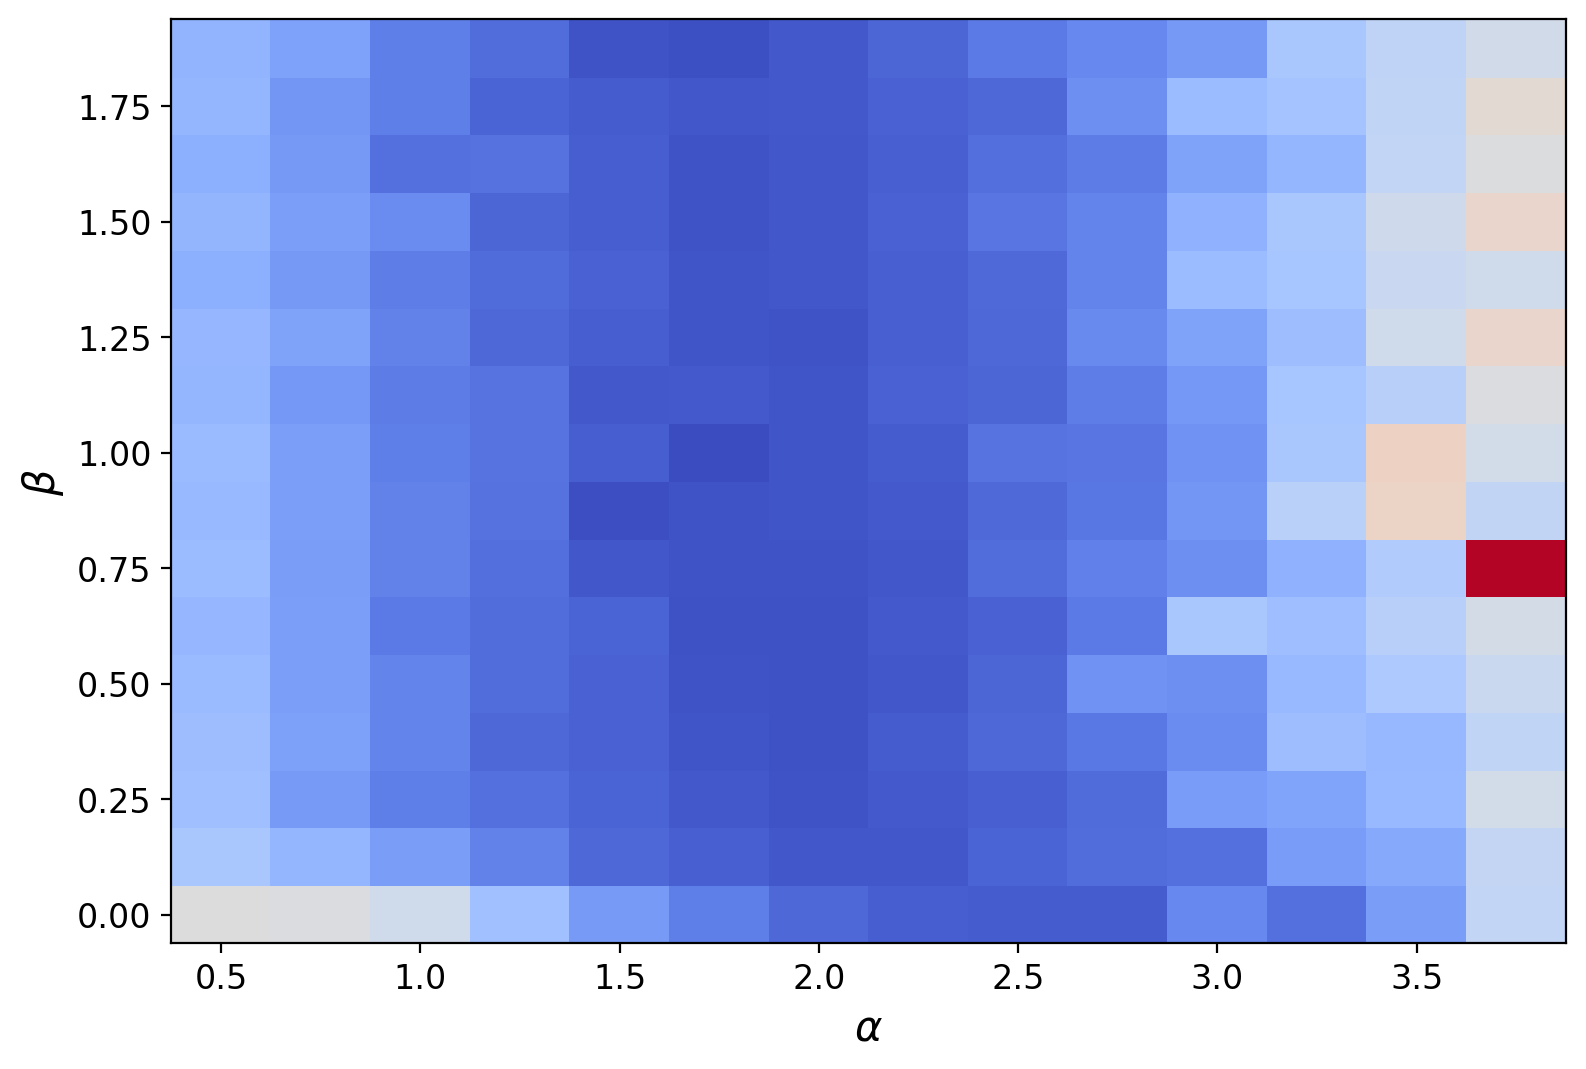

In [50]:
# Prepare for plots
import matplotlib.cm as cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

fig = plt.figure()
ax = plt.axes(projection="3d")
# Plot the surface.
surf = ax.plot_surface(X, Y, eavg,cmap=cm.coolwarm,linewidth=0, antialiased=False)
# Customize the z axis.
zmin = np.matrix(eavg).min()
zmax = np.matrix(eavg).max()
ax.set_zlim(zmin, zmax)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\beta$')
ax.set_zlabel(r'$\langle E \rangle$')
ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.02f'))
# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

# Prepare for plots
fig = plt.figure()
ax = plt.axes()
# Plot the surface.
plt.pcolor(X, Y, eavg,cmap=cm.coolwarm)
# Customize the z axis.
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\beta$')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

<a name='exercises_23_4'></a>     

| [Top](#section_23_0) | [Restart Section](#section_23_4) | [Next Section](#section_23_5) |


### <span style="border:3px; border-style:solid; padding: 0.15em; border-color: #90409C; color: #90409C;">Exercise 23.4.1</span>

<br>

<a name='section_23_5'></a>
<hr style="height: 1px;">

## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L23.5 MCMC using a professional sampler</h2>  

| [Top](#section_23_0) | [Previous Section](#section_23_4) | [Exercises](#exercises_23_5) | [Next Section](#section_23_6) |

In the interest of showing MCMC in the wild, we are going to show how to use the BILBY package, which is used for gravitational waves. While there are other packages that exist, we thought this one would be good considering the laboratory that we did early on.

For this package, we are first going to do a very basic example of fitting a line. What we will do is define the likelihood of fitting a line with the formula

$$
f(x) = m x + c \\
\mathcal{L} = \exp\left(-\sum_{i} \left(\frac{f(x_{i})-y_{i}}{2\sigma_{i}}\right)^{2}\right)
$$

The above is written in Bilby using a standardized function "GaussianLikelihood"

Lets go ahead and setup the problem.

68.11448711416878


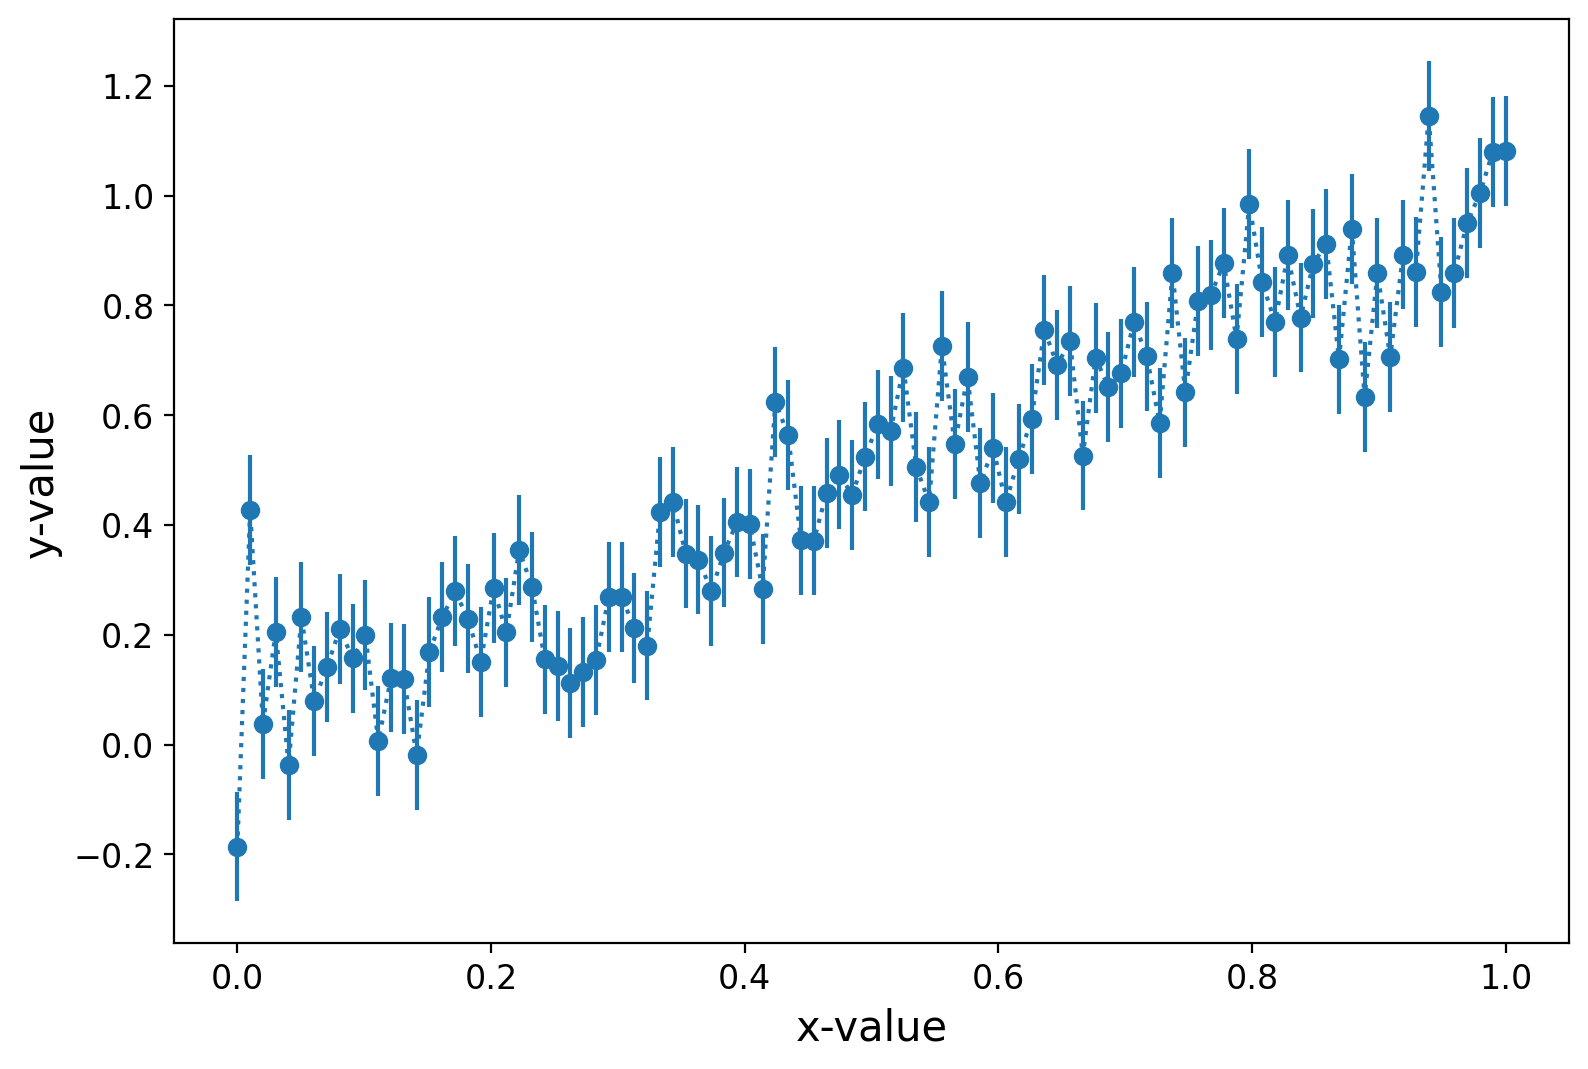

In [2]:
import bilby

def model(x, m, c):
    return m * x + c

#make some toy data mx+c (m=1,c=0) smear y with sigma=0.1
m = 1
c = 0
sigma = 0.1
N = 100
x = np.linspace(0, 1, N)
y = model(x, m, c) + np.random.normal(0, sigma, N)

#Now compute likelihood
likelihood = bilby.core.likelihood.GaussianLikelihood(x, y, model,sigma=0.1)
likelihood.parameters['m'] = 0.9
likelihood.parameters['c'] = 0.1
print(likelihood.log_likelihood())

plt.errorbar(x,y,yerr=0.1*np.ones(len(y)),marker='o',linestyle='dotted')
plt.xlabel('x-value')
plt.ylabel('y-value')
plt.show()



Now to do a linear fit with an MCMC we are going to have to make proposals for what to do. To make some proposals, all we need to do is define a bunch of priors.

10:34 bilby INFO    : Running for label 'full', output will be saved to 'test'
10:34 bilby INFO    : Analysis priors:
10:34 bilby INFO    : m=Uniform(minimum=0, maximum=5, name='m', latex_label='m', unit=None, boundary=None)
10:34 bilby INFO    : c=Uniform(minimum=-2, maximum=2, name='c', latex_label='c', unit=None, boundary=None)
10:34 bilby INFO    : sigma=0.1
10:34 bilby INFO    : Analysis likelihood class: <class 'bilby.core.likelihood.GaussianLikelihood'>
10:34 bilby INFO    : Analysis likelihood noise evidence: nan
10:34 bilby INFO    : Single likelihood evaluation took 1.077e-04 s
10:34 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
10:34 bilby INFO    : Checkpoint every check_point_delta_t = 600s
10:34 bilby WARNING : Using cached r

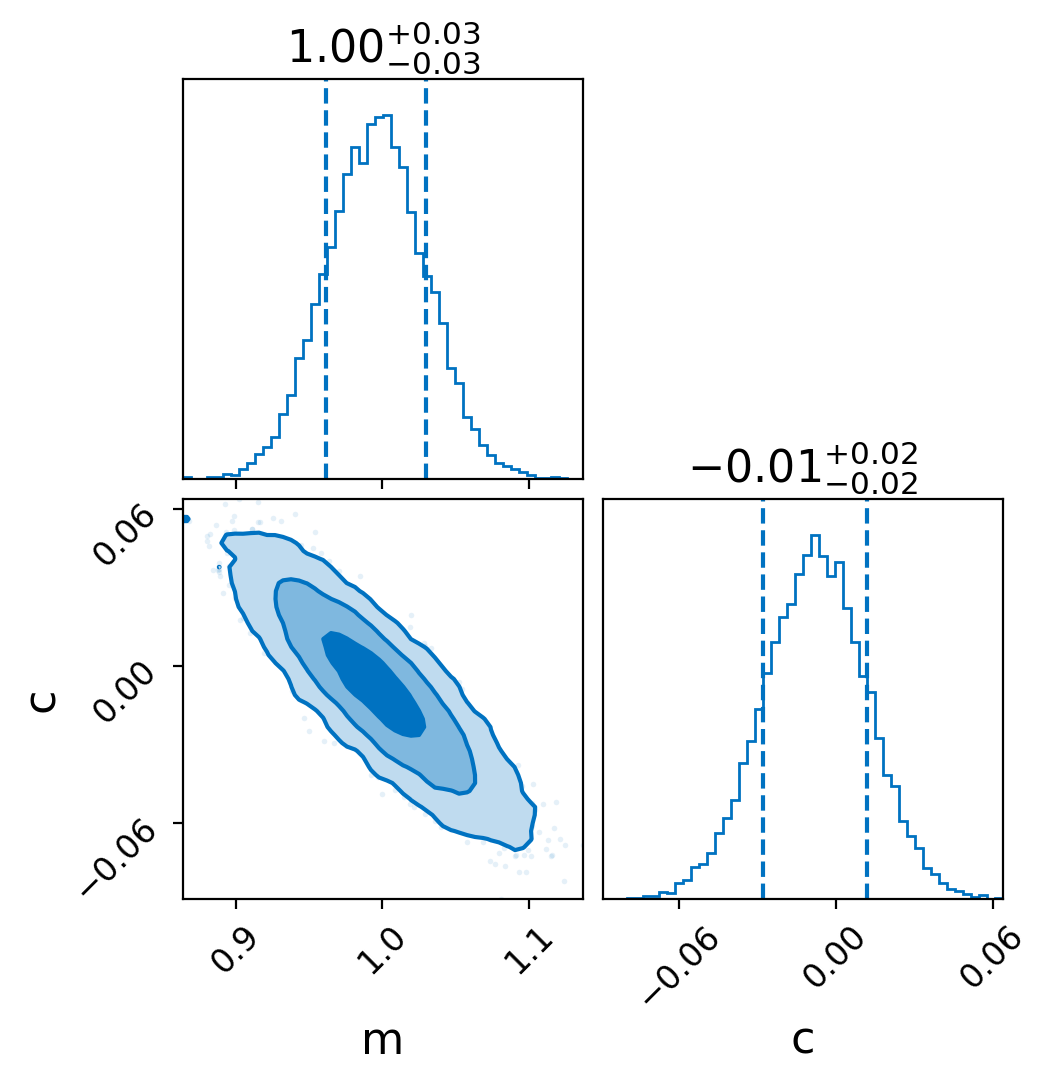

In [3]:
priors = dict()
priors['m'] = bilby.core.prior.Uniform(0, 5, 'm')
priors['c'] = bilby.core.prior.Uniform(-2, 2, 'c')
priors['sigma'] = sigma

full_result = bilby.run_sampler(likelihood=likelihood, priors=priors, sampler='dynesty', npoints=5000,outdir='test', label='full')
full_result.plot_corner()

Now if we ant to play with the fit, we can consider constraining one of the parameters and fitting.

10:34 bilby INFO    : Running for label 'test2', output will be saved to 'pptest2'
10:34 bilby INFO    : Analysis priors:
10:34 bilby INFO    : m2=Uniform(minimum=-1.01, maximum=1.01, name='m2', latex_label='m2', unit=None, boundary=None)
10:34 bilby INFO    : m1=Uniform(minimum=0, maximum=6, name='m1', latex_label='m1', unit=None, boundary=None)
10:34 bilby INFO    : c=Uniform(minimum=-2, maximum=2, name='c', latex_label='c', unit=None, boundary=None)
10:34 bilby INFO    : sigma=0.1
10:34 bilby INFO    : Analysis likelihood class: <class 'bilby.core.likelihood.GaussianLikelihood'>
10:34 bilby INFO    : Analysis likelihood noise evidence: nan
10:34 bilby INFO    : Single likelihood evaluation took 1.168e-04 s
10:34 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.

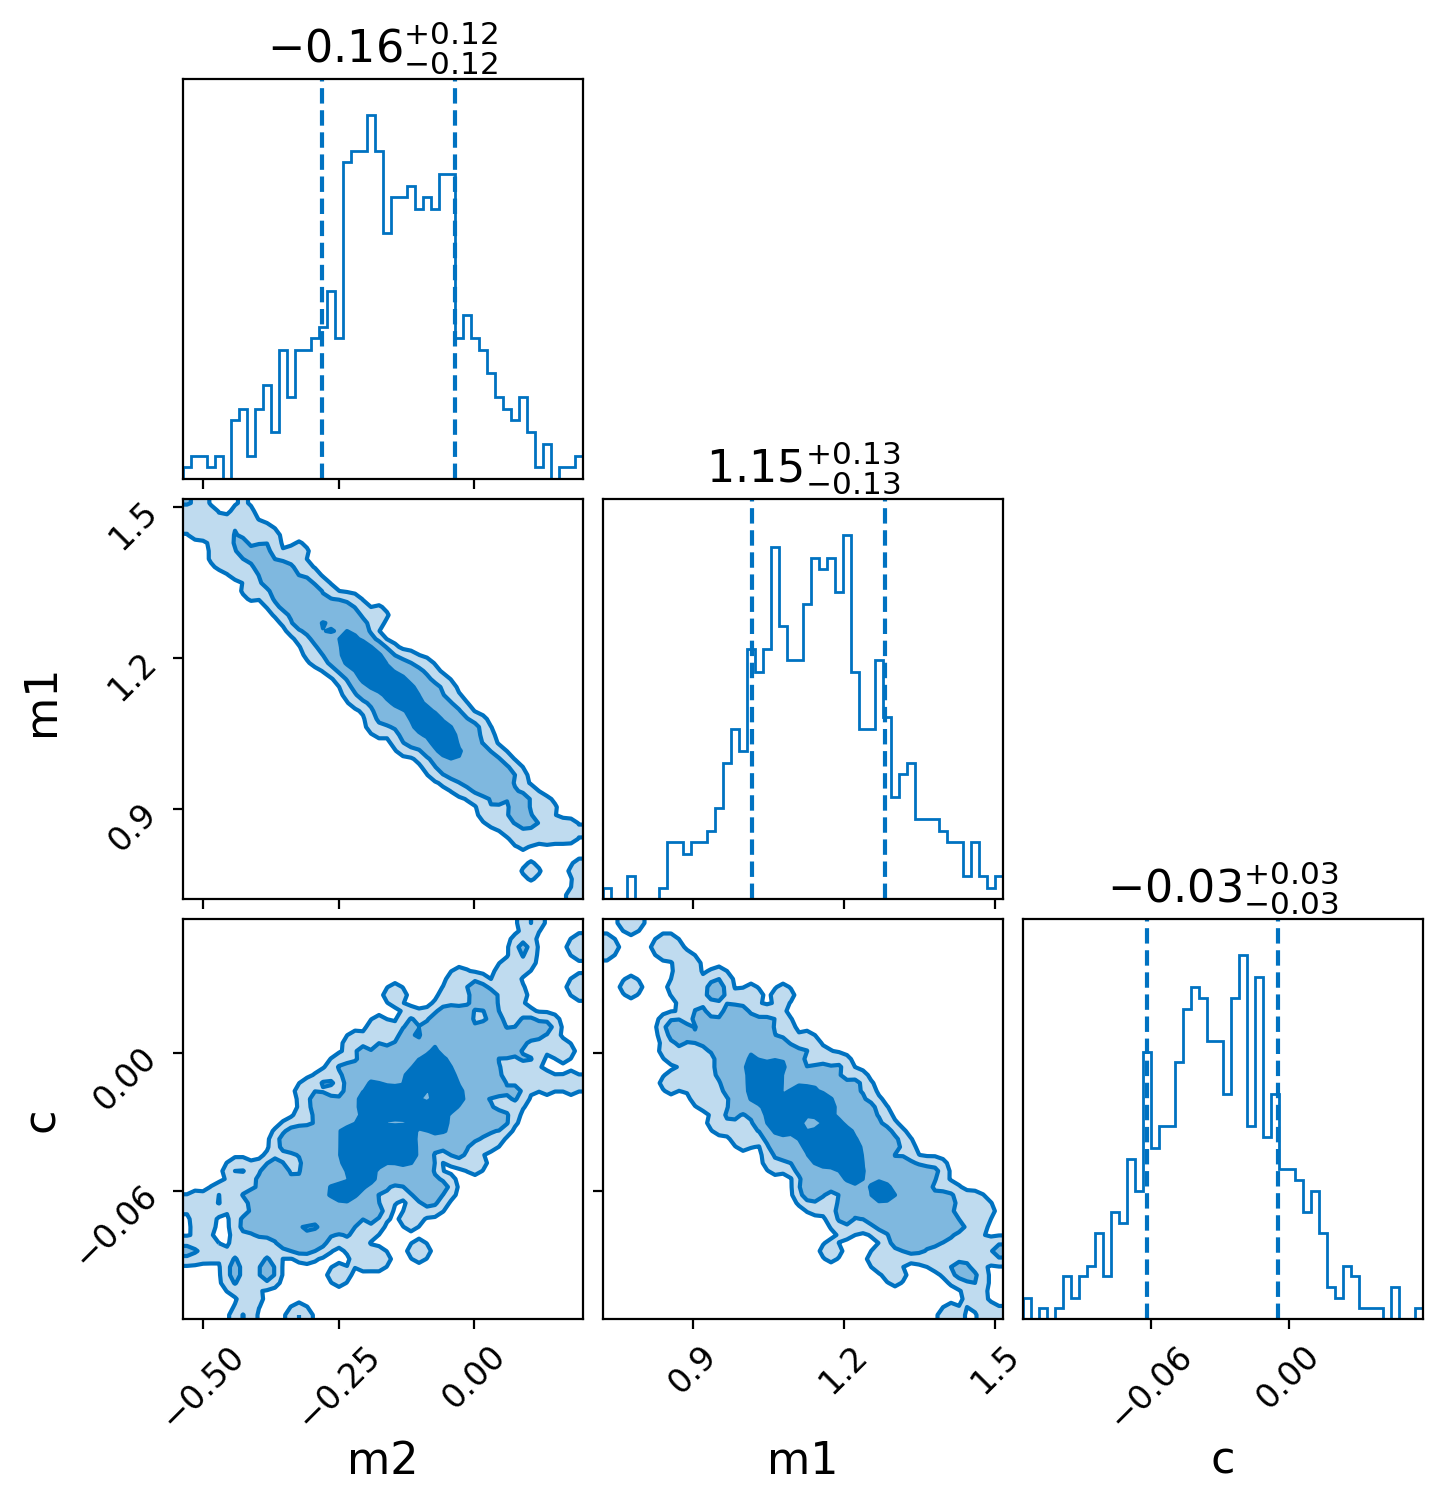

In [4]:
def model1(x,m2,m1,c):
    return m2*x**2+m1*x+c

likelihood = bilby.core.likelihood.GaussianLikelihood(x, y, model1,sigma=0.1)

priors = dict()
priors['m2'] = bilby.core.prior.Uniform(-1.01, 1.01, 'm2')
priors['m1'] = bilby.core.prior.Uniform(0, 6, 'm1')
priors['c'] = bilby.core.prior.Uniform(-2, 2, 'c')
priors['sigma'] = 0.1
partial_result = bilby.run_sampler(likelihood=likelihood, priors=priors, sampler='dynesty', dlogz=1, npoints=500,outdir='pptest2', label='test2',check_point=False
)
partial_result.plot_corner()



Ok, so now we see how to build such fits. You can see clearly this is definitely not the most efficient way to fit a line. However, it does do the job and it does give us a MC smattering of results that we can use to analysis on.

<a name='exercises_23_5'></a>     

| [Top](#section_23_0) | [Restart Section](#section_23_5) | [Next Section](#section_23_6) |


### <span style="border:3px; border-style:solid; padding: 0.15em; border-color: #90409C; color: #90409C;">Exercise 23.5.1</span>

<br>

<a name='section_23_6'></a>
<hr style="height: 1px;">

## <h2 style="border:1px; border-style:solid; padding: 0.25em; color: #FFFFFF; background-color: #90409C">L23.6 Gravitational Waves </h2>  

| [Top](#section_23_0) | [Previous Section](#section_23_5) | [Exercises](#exercises_23_6) |

As you might have remembered from the gravitational wave lab the fit was not particularly good. That is becasue the full fit really involves using the gravitational waves. For LIGO, they have developed a MCMC sampler that is built on the emcee library. In practice the procedure follows exaclty like what we have done above.  However, now we need to have an approach to minimize the likelihood and perform parameter estimation.

To do this, we are going to perform a very basic MCMC fit of the black hole masses of our laboratory 1 setup, just to see how this works.

Our first step is to install the Bilby library, which gives us both waveforms and a wrapper for performing MCMC fits. Let's do that.

In [5]:
import scipy.signal as sig
from bilby.gw.source import lal_binary_black_hole
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters

Now before we do anything, lets learn how to generate our own waveform. With Bilby it is relatively straightforward to generate waveforms. In fact, we cna make a little function to generate waveforms. Let's make the function and then stare at what its doing.

10:35 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


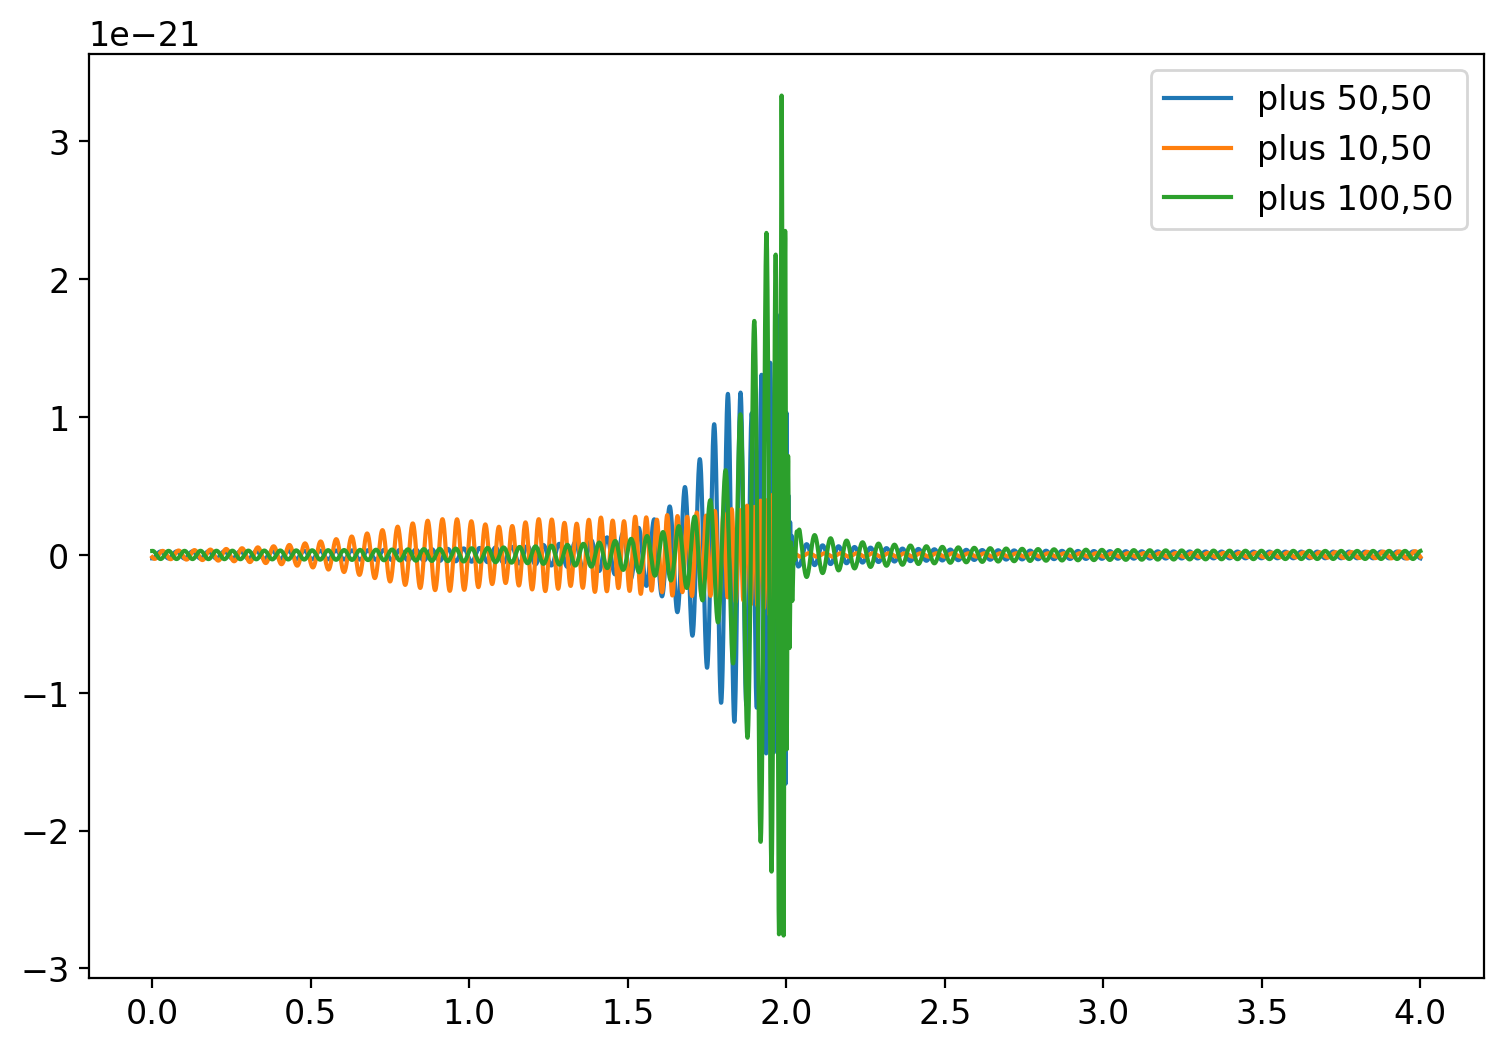

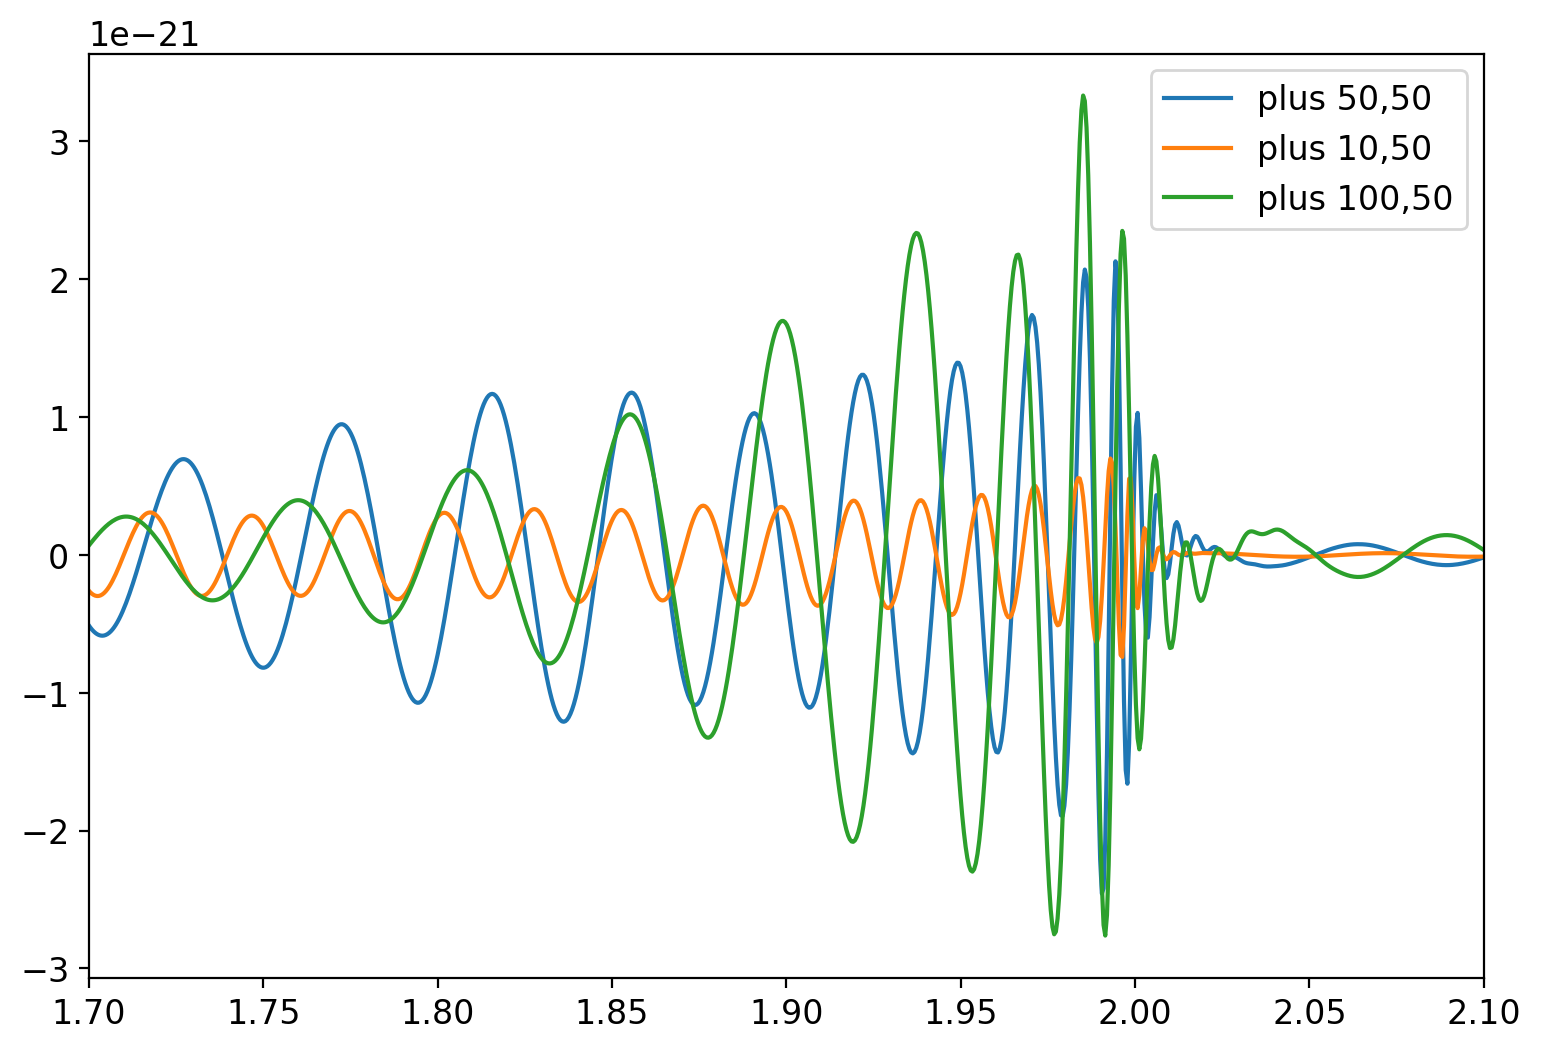

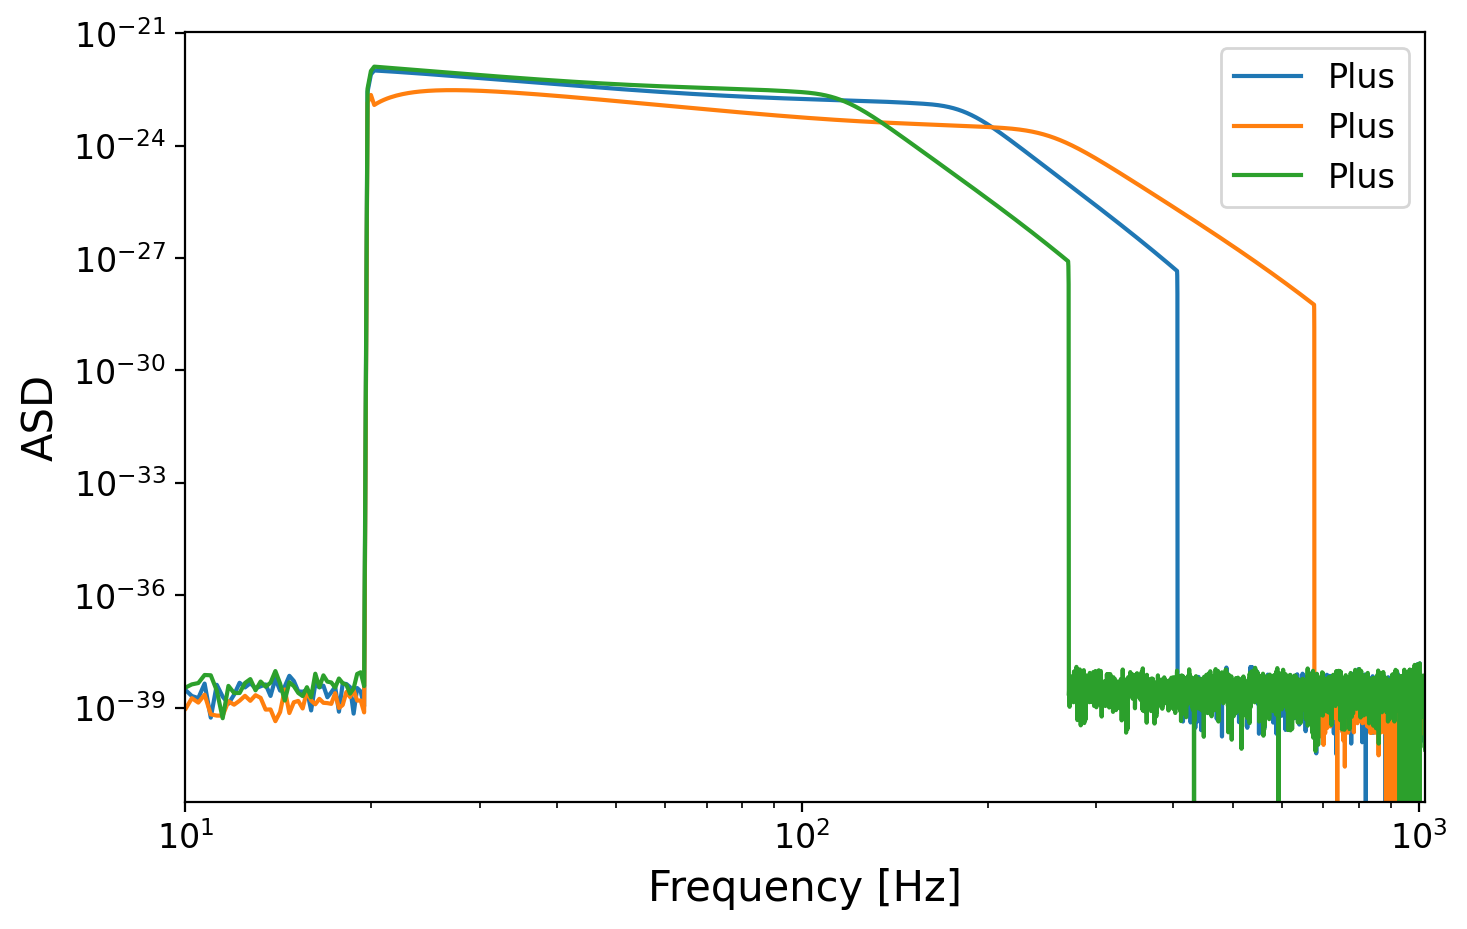

In [6]:
duration = 4.#4s
sampling_frequency = 2048.#Hz
waveform_arguments = {
    'waveform_approximant': 'IMRPhenomPv2',
    'reference_frequency': 50.,  # most sensitive frequency
    'minimum_frequency': 20.
}
waveform_generator = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    frequency_domain_source_model=lal_binary_black_hole,
    waveform_arguments=waveform_arguments)

def generateWaveForm(iM1,iM2):
    injection_parameters = dict(
    mass_1=iM1, mass_2=iM2, a_1=0., a_2=0., tilt_1=0., tilt_2=0.,
    phi_12=0., phi_jl=0., luminosity_distance=500, theta_jn=0., psi=0.,
    phase=0.2, geocent_time=1243309096, ra=0., dec=0.)
    polarizations_td = waveform_generator.time_domain_strain(injection_parameters)
    return polarizations_td

def shiftplus(iPolar,sampling,duration):
    plus_td  = np.roll(iPolar['plus'],  int(sampling * duration/2.))
    cross_td = np.roll(iPolar['cross'], int(sampling * duration/2.))
    return plus_td

polarizations_td0 = generateWaveForm(50,50)
polarizations_td1 = generateWaveForm(10,50)
polarizations_td2 = generateWaveForm(100,50)

plus_td0=shiftplus(polarizations_td0,sampling_frequency,duration)
plus_td1=shiftplus(polarizations_td1,sampling_frequency,duration)
plus_td2=shiftplus(polarizations_td2,sampling_frequency,duration)

time = np.linspace(0.,duration,len(plus_td0))

plt.plot(time, plus_td0, label='plus 50,50')
plt.plot(time, plus_td1, label='plus 10,50')
plt.plot(time, plus_td2, label='plus 100,50')
plt.legend()
plt.show()

plt.plot(time, plus_td0, label='plus 50,50')
plt.plot(time, plus_td1, label='plus 10,50')
plt.plot(time, plus_td2, label='plus 100,50')
plt.legend()
plt.xlim(1.7,2.1)
plt.show()

# And their ASD
def asd(its):
    NFFT = int(4 * sampling_frequency)
    freq, plus_psd = sig.welch(its, fs=sampling_frequency, nperseg=NFFT)
    plus_asd = np.sqrt(plus_psd)
    return freq, plus_asd

freq, plus_asd0 = asd(plus_td0)
freq, plus_asd1 = asd(plus_td1)
freq, plus_asd2 = asd(plus_td2)

fig = plt.figure(figsize=(8, 5))
plt.loglog(freq, plus_asd0, label='Plus')
plt.loglog(freq, plus_asd1, label='Plus')
plt.loglog(freq, plus_asd2, label='Plus')
plt.xlim(10, 1024)
plt.xlabel('Frequency [Hz]')
plt.ylabel('ASD')
plt.legend()
plt.show()


Now that we have created a functional form, we can go ahead and come up witha likelihood. The Likelihood that we are going to look at for this is effectively a $\chi^{2}$ in the fourier domain. We can write out the likelihood as

$$
\log\left(\mathcal{L}\right) = -\frac{1}{2}\sum_{i} \left(\frac{d_{i}-\mu\left(\vec{\theta}\right)}{\sigma_{i}}\right)^{2} + \log\left(2\pi\sigma_{i}\right)
$$

where $d_{i}$ is the amplitude in a specific fourier bin, $\sigma_{k}$ is the uncertainty in that bin from the noise, as computed by the ASD, and $\mu\left(\vec{\theta}\right)$ is our predicted waveform. This drives our whole fit now using the full library for the waveform.

Now, before we do the officieal, we need fetch the data and prep it to be fit. Since we did this already in the project, we will go through this quickly.

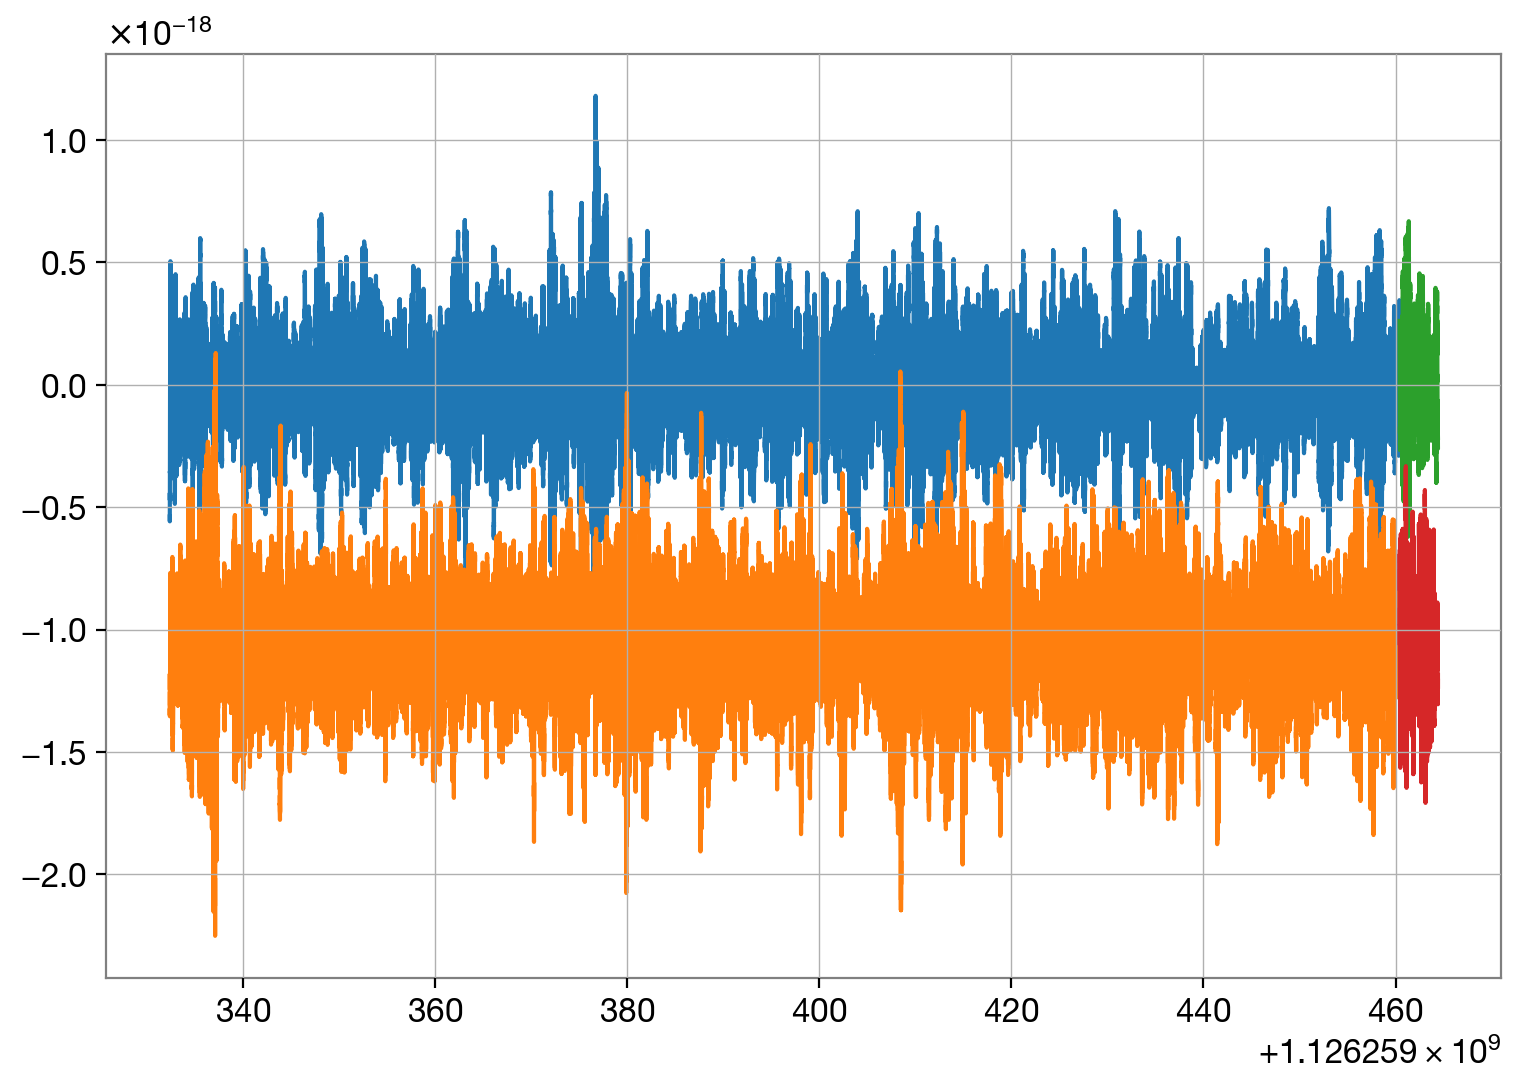

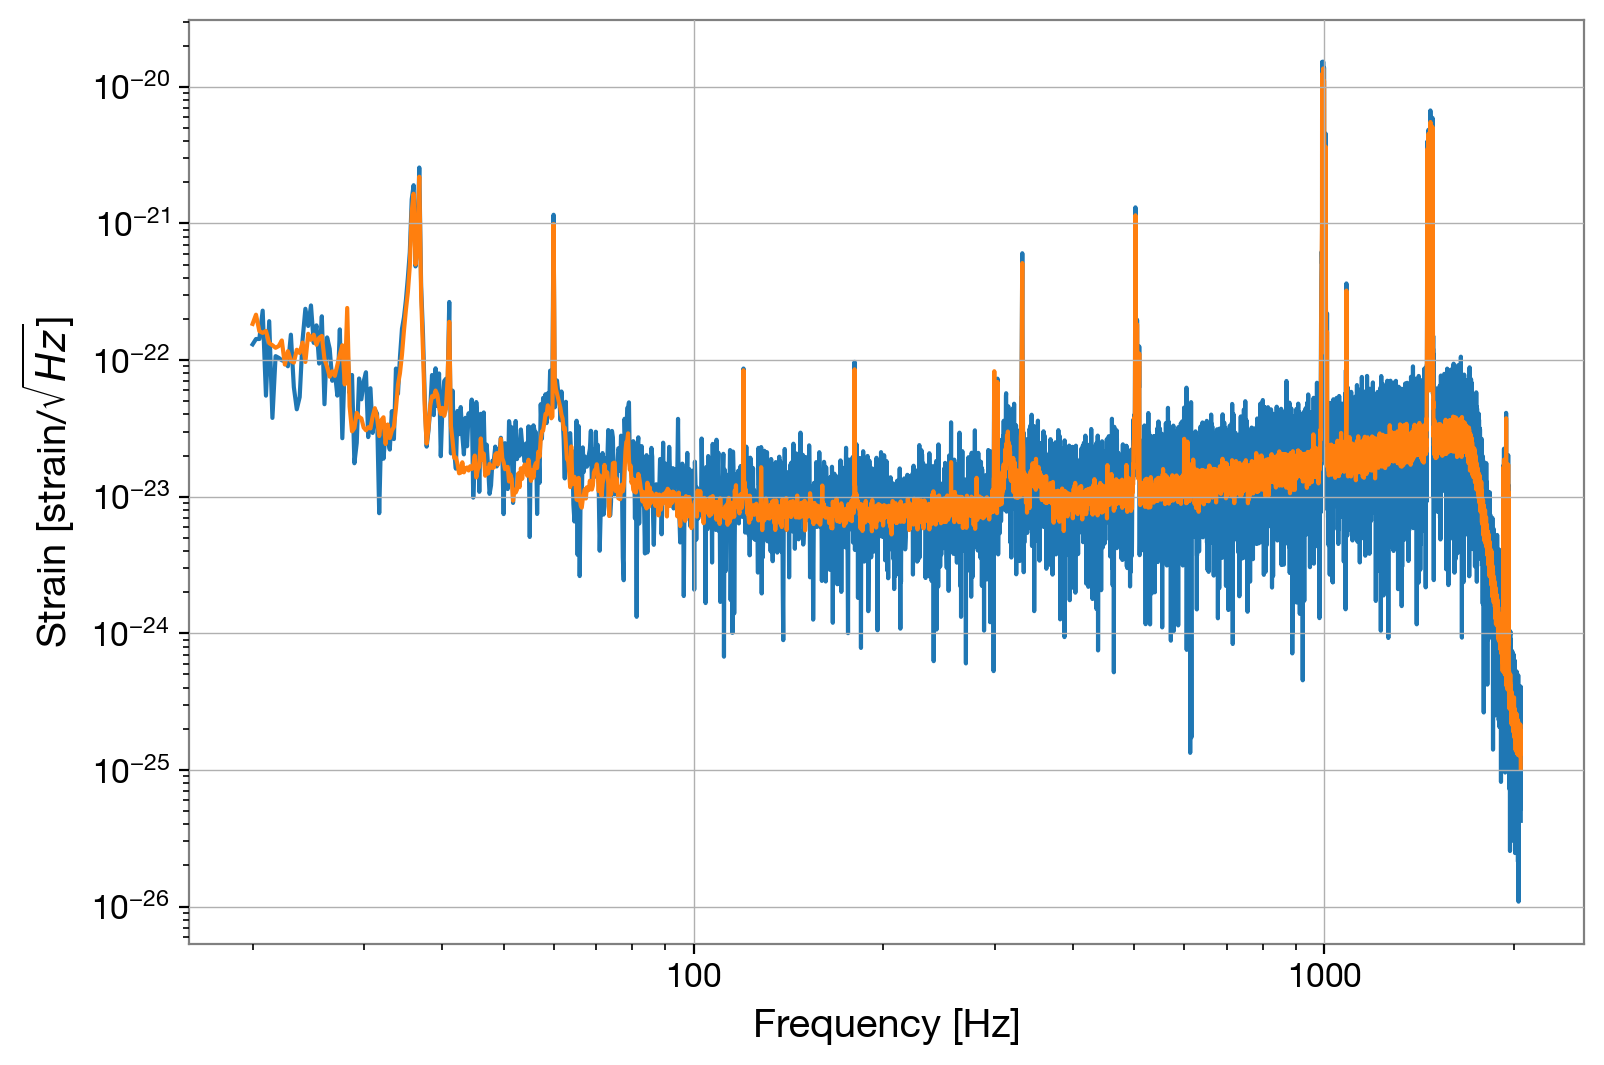

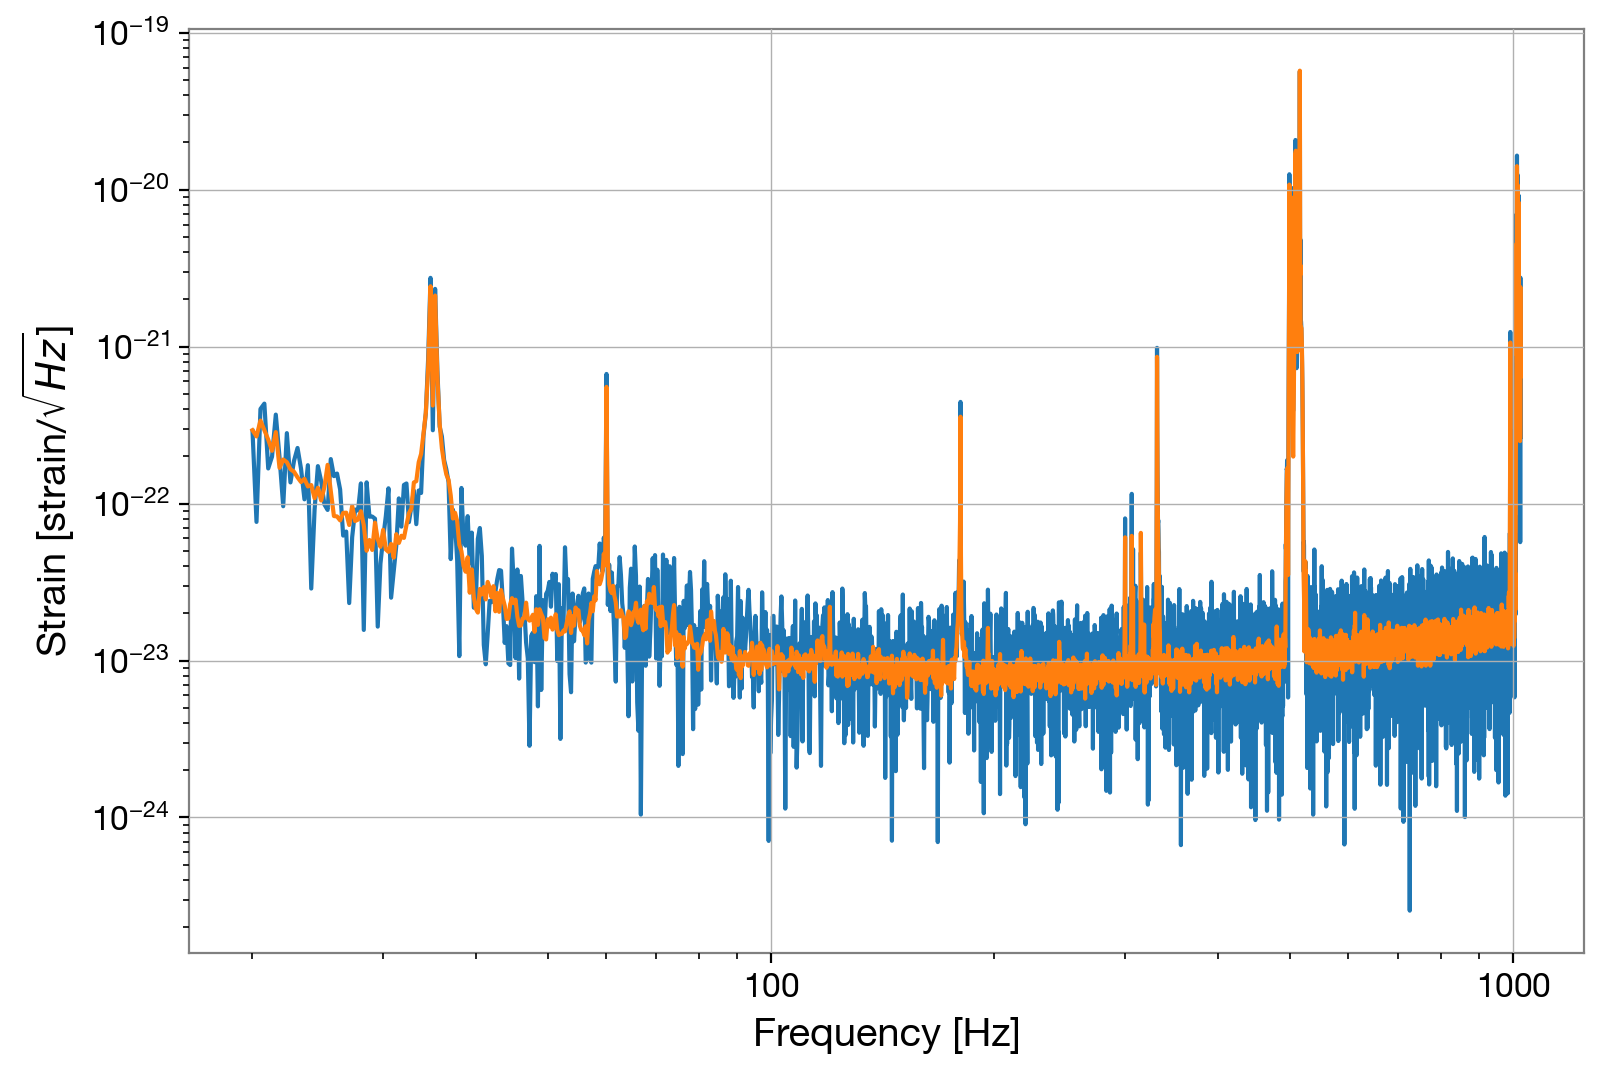

In [7]:
%matplotlib inline
from gwpy.timeseries import TimeSeries

time_of_event = 1126259462.413

H1 = bilby.gw.detector.get_empty_interferometer("H1")
L1 = bilby.gw.detector.get_empty_interferometer("L1")

# Definite times in relatation to the trigger time (time_of_event), duration and post_trigger_duration
post_trigger_duration = 2
duration = 4
analysis_start = time_of_event + post_trigger_duration - duration
#ok so get the data we are going to use for the fit
H1_analysis_data = TimeSeries.fetch_open_data("H1", analysis_start, analysis_start + duration, sample_rate=4096, cache=True)
L1_analysis_data = TimeSeries.fetch_open_data("L1", analysis_start, analysis_start + duration, sample_rate=4096, cache=True)

# Use gwpy to fetch the open data and get the data around the time to compute the psd
psd_duration = duration * 32
psd_start_time = analysis_start - psd_duration
H1_psd_data = TimeSeries.fetch_open_data( "H1", psd_start_time, psd_start_time + psd_duration, sample_rate=4096, cache=True)
L1_psd_data = TimeSeries.fetch_open_data( "L1", psd_start_time, psd_start_time + psd_duration, sample_rate=4096, cache=True)
plt.plot(H1_psd_data)
plt.plot(L1_psd_data)
plt.plot(H1_analysis_data)
plt.plot(L1_analysis_data)
plt.show()

#Set this to our model
H1.set_strain_data_from_gwpy_timeseries(H1_analysis_data)
L1.set_strain_data_from_gwpy_timeseries(L1_analysis_data)

#Now compute the PSDs and set this
psd_alpha = 2 * H1.strain_data.roll_off / duration
H1_psd = H1_psd_data.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
L1_psd = L1_psd_data.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
H1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(frequency_array=H1_psd.frequencies.value, psd_array=H1_psd.value)
L1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(frequency_array=L1_psd.frequencies.value, psd_array=L1_psd.value)

fig, ax = plt.subplots()
idxs = H1.strain_data.frequency_mask  # This is a boolean mask of the frequencies which we'll use in the analysis
ax.loglog(H1.strain_data.frequency_array[idxs],np.abs(H1.strain_data.frequency_domain_strain[idxs]))
ax.loglog(H1.power_spectral_density.frequency_array[idxs], H1.power_spectral_density.asd_array[idxs])
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Strain [strain/$\sqrt{Hz}$]")
plt.show()

H1.maximum_frequency = 1024
L1.maximum_frequency = 1024

fig, ax = plt.subplots()
idxs = L1.strain_data.frequency_mask  # This is a boolean mask of the frequencies which we'll use in the analysis
ax.loglog(L1.strain_data.frequency_array[idxs],np.abs(L1.strain_data.frequency_domain_strain[idxs]))
ax.loglog(L1.power_spectral_density.frequency_array[idxs], L1.power_spectral_density.asd_array[idxs])
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Strain [strain/$\sqrt{Hz}$]")
plt.show()



Ok now with all of that done, lets go ahead and creat our likelihood object, and our fit function. Because this code is taylor made for LIGO it will be relatively easy to put it all together. However, there is a lot under the hood that we are not covering here.

In [8]:
# First, put our "data" created above into a list of interferometers (the order is arbitrary)
interferometers = [H1, L1]

# Next create a dictionary of arguments which we pass into the LALSimulation waveform - we specify the waveform approximant here
waveform_arguments = dict(waveform_approximant='IMRPhenomPv2',
                          reference_frequency=100., catch_waveform_errors=True)

# Next, create a waveform_generator object. This wraps up some of the jobs of converting between parameters etc
waveform_generator = bilby.gw.WaveformGenerator(
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    waveform_arguments=waveform_arguments,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters)


10:35 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


Now finally, lets list all of our priors and run the fit!

In [9]:
from bilby.core.prior import Uniform

prior = bilby.core.prior.PriorDict()
prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=25.0,maximum=35.5)
prior['mass_ratio'] = Uniform(name='mass_ratio', minimum=0.5, maximum=1)
prior['phase']        = 1.3#Uniform(name="phase", minimum=0, maximum=2*np.pi)
prior['geocent_time'] = Uniform(name="geocent_time", minimum=time_of_event-0.1, maximum=time_of_event+0.1)
prior['a_1'] =  0.0
prior['a_2'] =  0.0
prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0
prior['dec'] =  -1.2232
prior['ra'] =  2.19432
prior['theta_jn'] =  1.89694
prior['psi'] =  0.532268
prior['luminosity_distance'] = 412.066

# Finally, create our likelihood, passing in what is needed to get going
likelihood = bilby.gw.likelihood.GravitationalWaveTransient(interferometers, waveform_generator, priors=prior,
    time_marginalization=True, phase_marginalization=False, distance_marginalization=False)

result_short = bilby.run_sampler(
    likelihood, prior, sampler='dynesty', outdir='short3', label="GW150914",
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    sample="unif", nlive=500, dlogz=3  # <- Arguments are used to make things fast - not recommended for general use
)

10:35 bilby INFO    : Running for label 'GW150914', output will be saved to 'short3'
10:35 bilby INFO    : Using lal version 7.3.1
10:35 bilby INFO    : Using lal git version Branch: None;Tag: lalsuite-v7.14;Id: c1be3b4393c305f7d4244b707604d603a10bc764;;Builder: Duncan Macleod <duncan.macleod@ligo.org>;Repository status: CLEAN: All modifications committed
10:35 bilby INFO    : Using lalsimulation version 5.1.0
10:35 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsuite-v7.14;Id: c1be3b4393c305f7d4244b707604d603a10bc764;;Builder: Duncan Macleod <duncan.macleod@ligo.org>;Repository status: CLEAN: All modifications committed
10:35 bilby INFO    : Analysis priors:
10:35 bilby INFO    : chirp_mass=Uniform(minimum=25.0, maximum=35.5, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
10:35 bilby INFO    : mass_ratio=Uniform(minimum=0.5, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
10:35 bilby INFO    : time_jitter=Uni

1it [00:00, ?it/s]

10:42 bilby INFO    : Written checkpoint file short3/GW150914_resume.pickle
10:42 bilby INFO    : Rejection sampling nested samples to obtain 167 posterior samples
10:42 bilby INFO    : Sampling time: 0:06:39.493572
10:42 bilby INFO    : Computing per-detector log likelihoods.


  0%|          | 0/167 [00:00<?, ?it/s]

10:42 bilby INFO    : Reconstructing marginalised parameters.


...

10:42 bilby INFO    : Generating sky frame parameters.


  0%|          | 0/167 [00:00<?, ?it/s]

10:42 bilby INFO    : Computing SNRs for every sample.


  0%|          | 0/167 [00:00<?, ?it/s]

10:42 bilby INFO    : Summary of results:
nsamples: 167
ln_noise_evidence: -8483.570
ln_evidence: -8220.990 +/-  0.401
ln_bayes_factor: 262.579 +/-  0.401



Now having run this fit, we can go ahead and look at the parameters and start to make some real statements about the best fit gravitational wave. Let's go ahead and plot the posteriors of our fit.

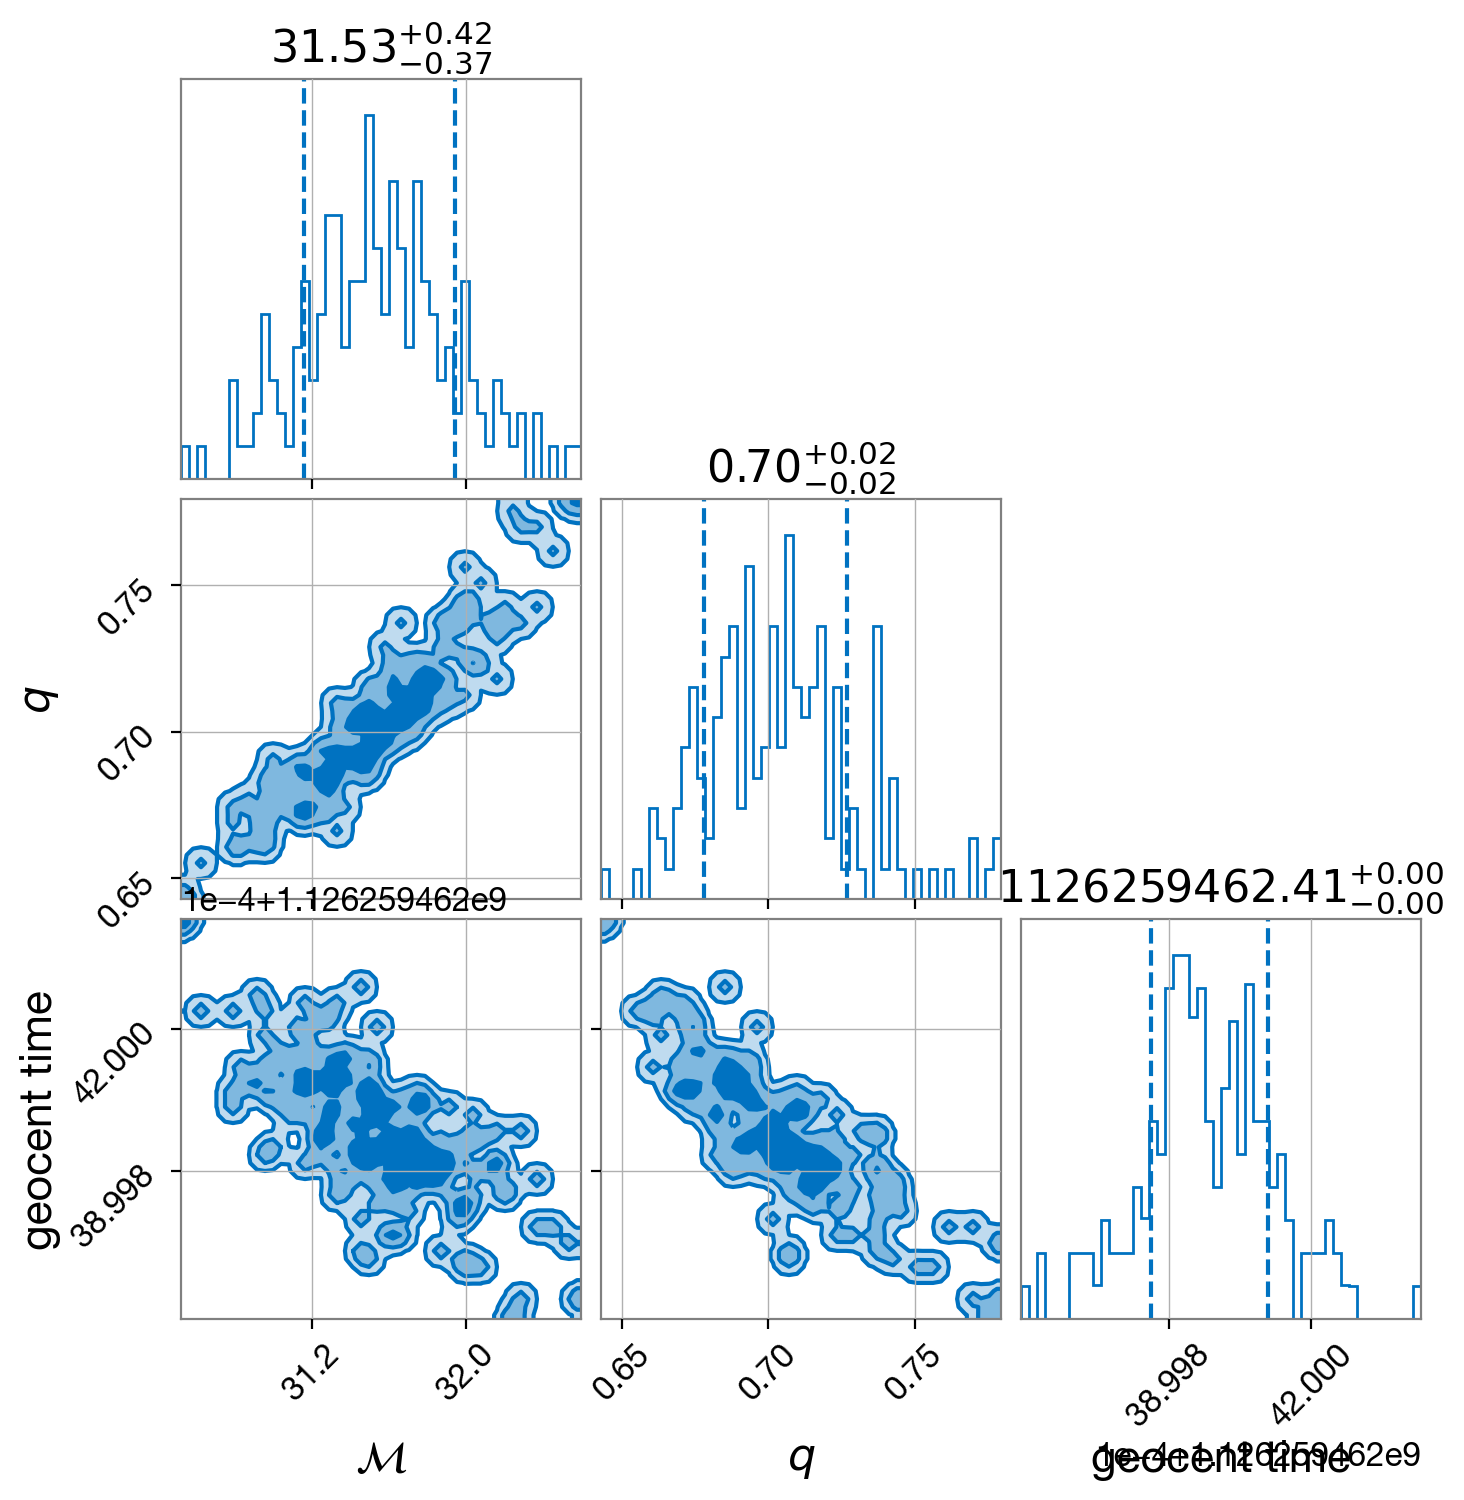

In [10]:
result_short.plot_corner(parameters=["chirp_mass", "mass_ratio", "geocent_time"], prior=True)
#plt.show()
#print(result_short.posterior)

Notice now that our chirp mass is spot on! Why is this this so much better? Well this is really because are finally using the actual Gravitational Waveform that defines our fit. Le's go ahead and look at the best fit for this guy.

10:42 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
10:42 bilby INFO    : Generating waveform figure for H1
10:42 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


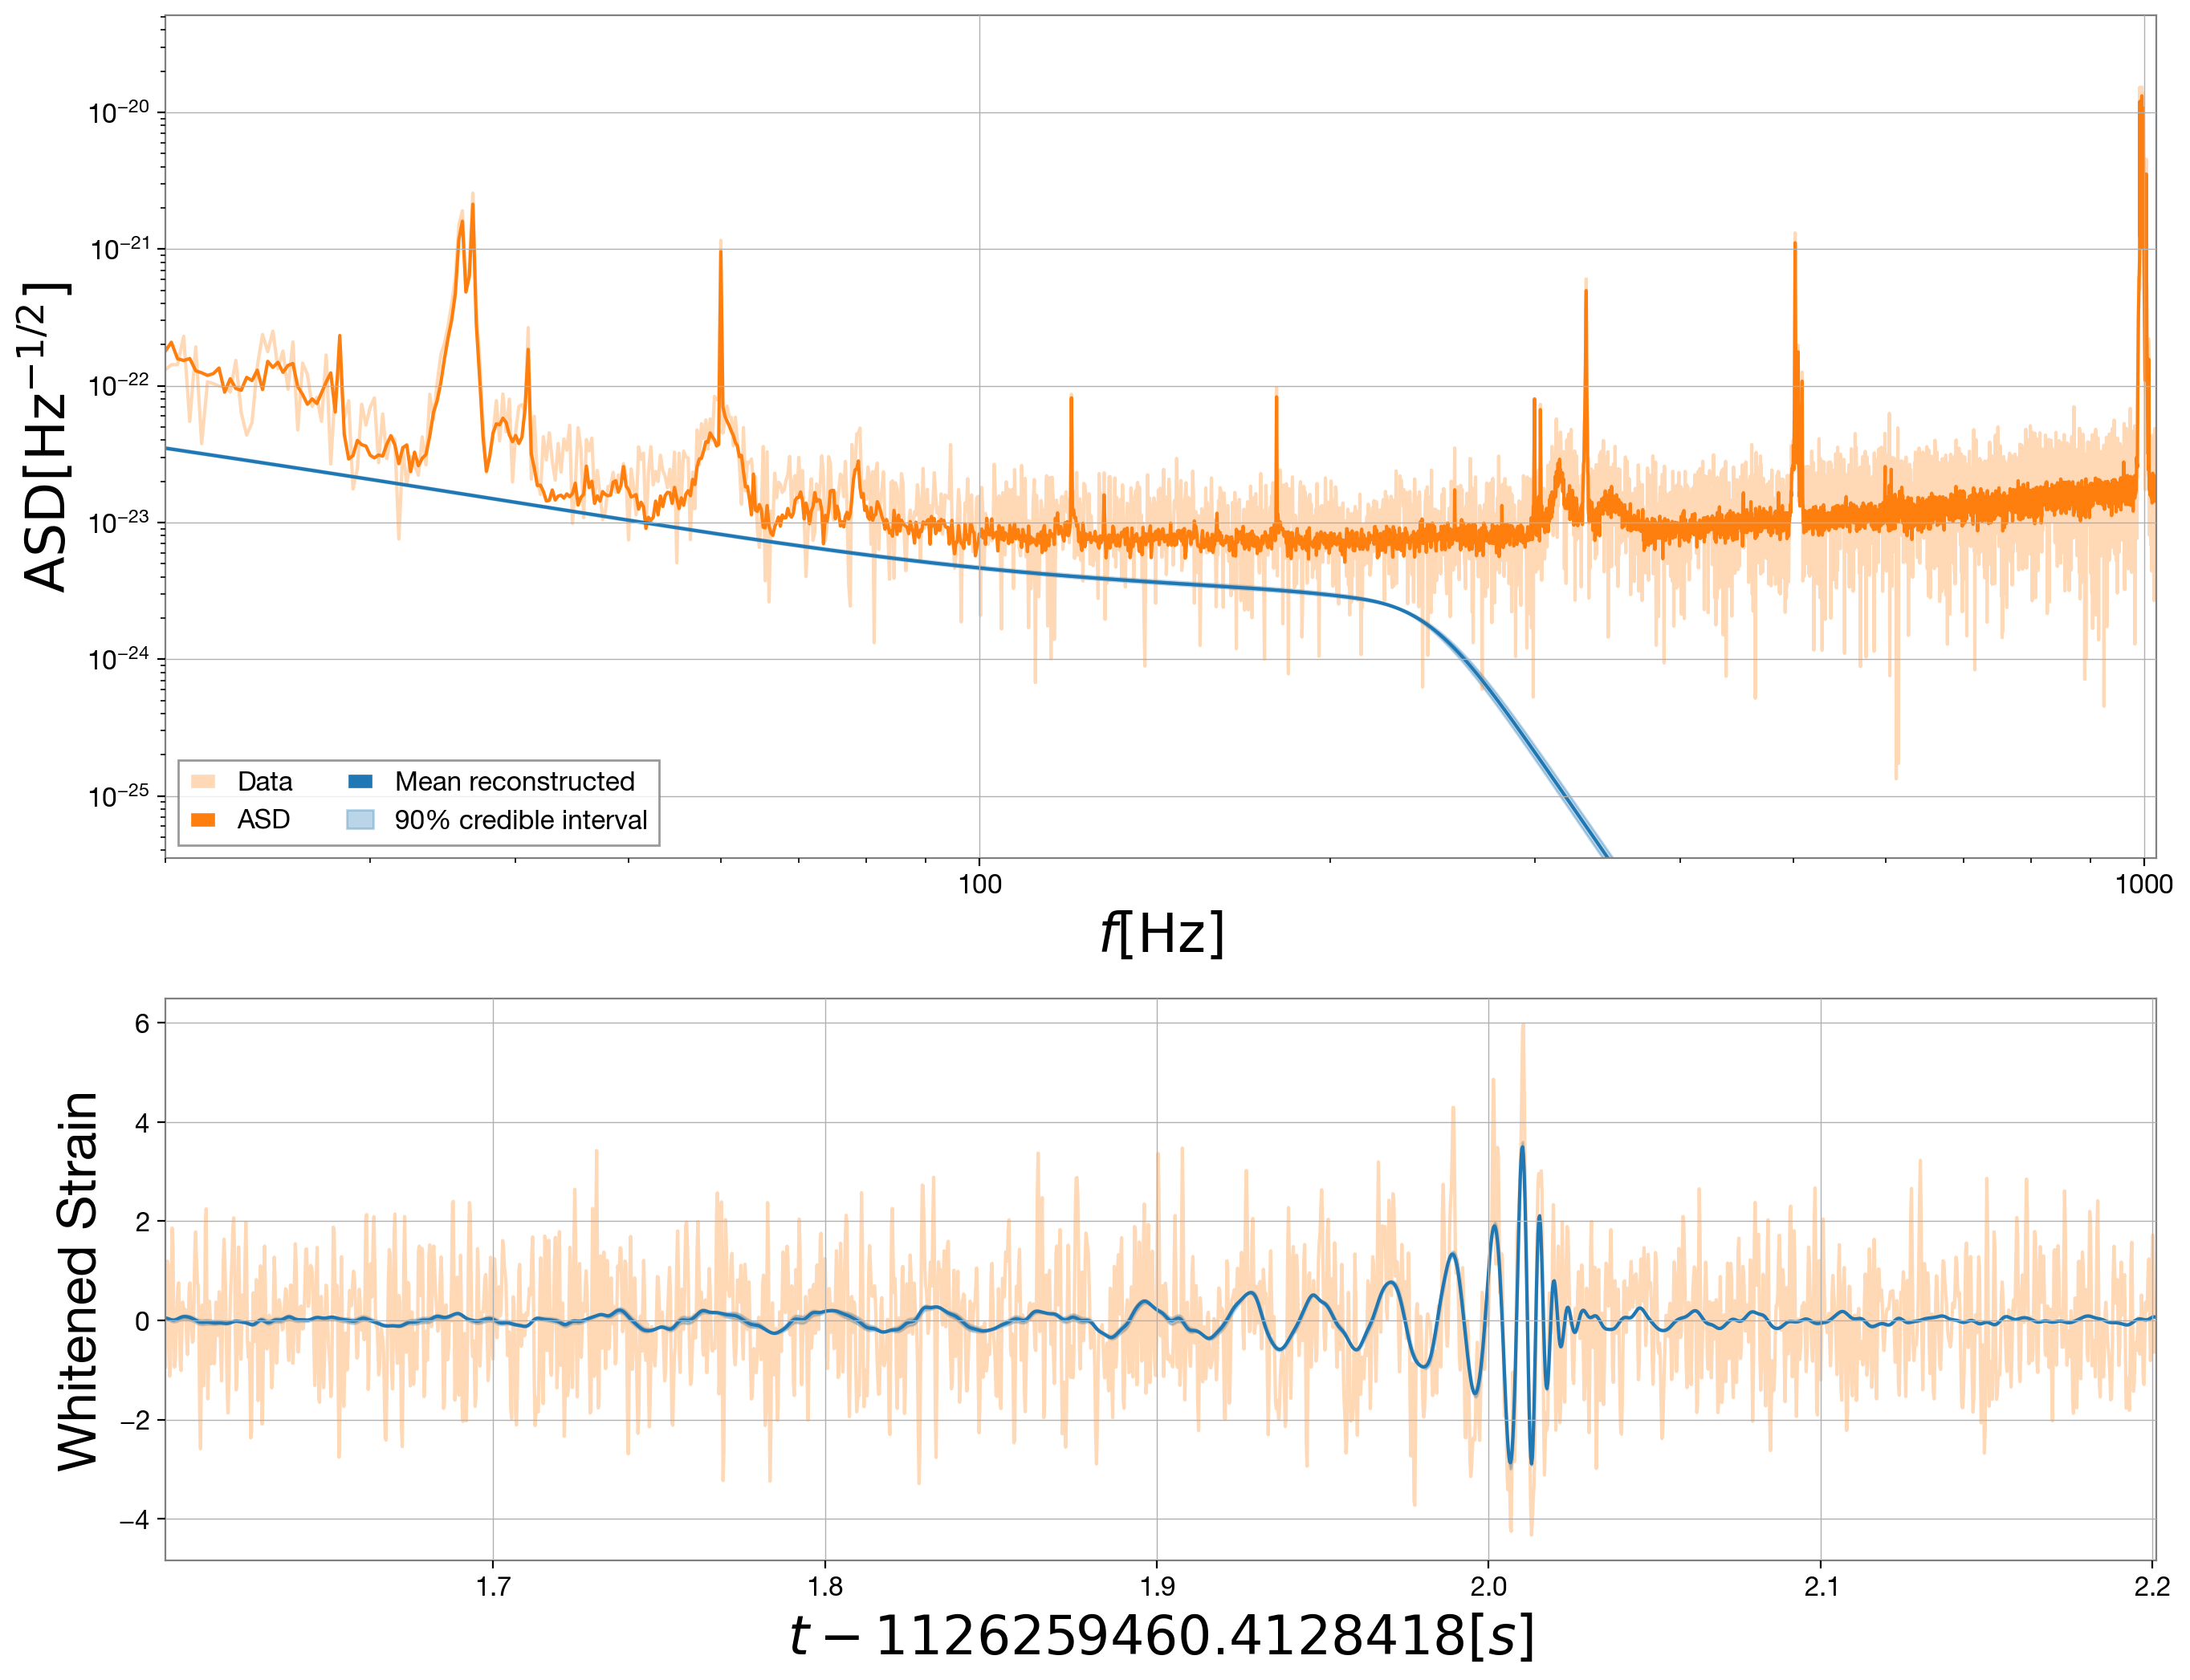

10:42 bilby INFO    : Generating waveform figure for L1
10:42 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


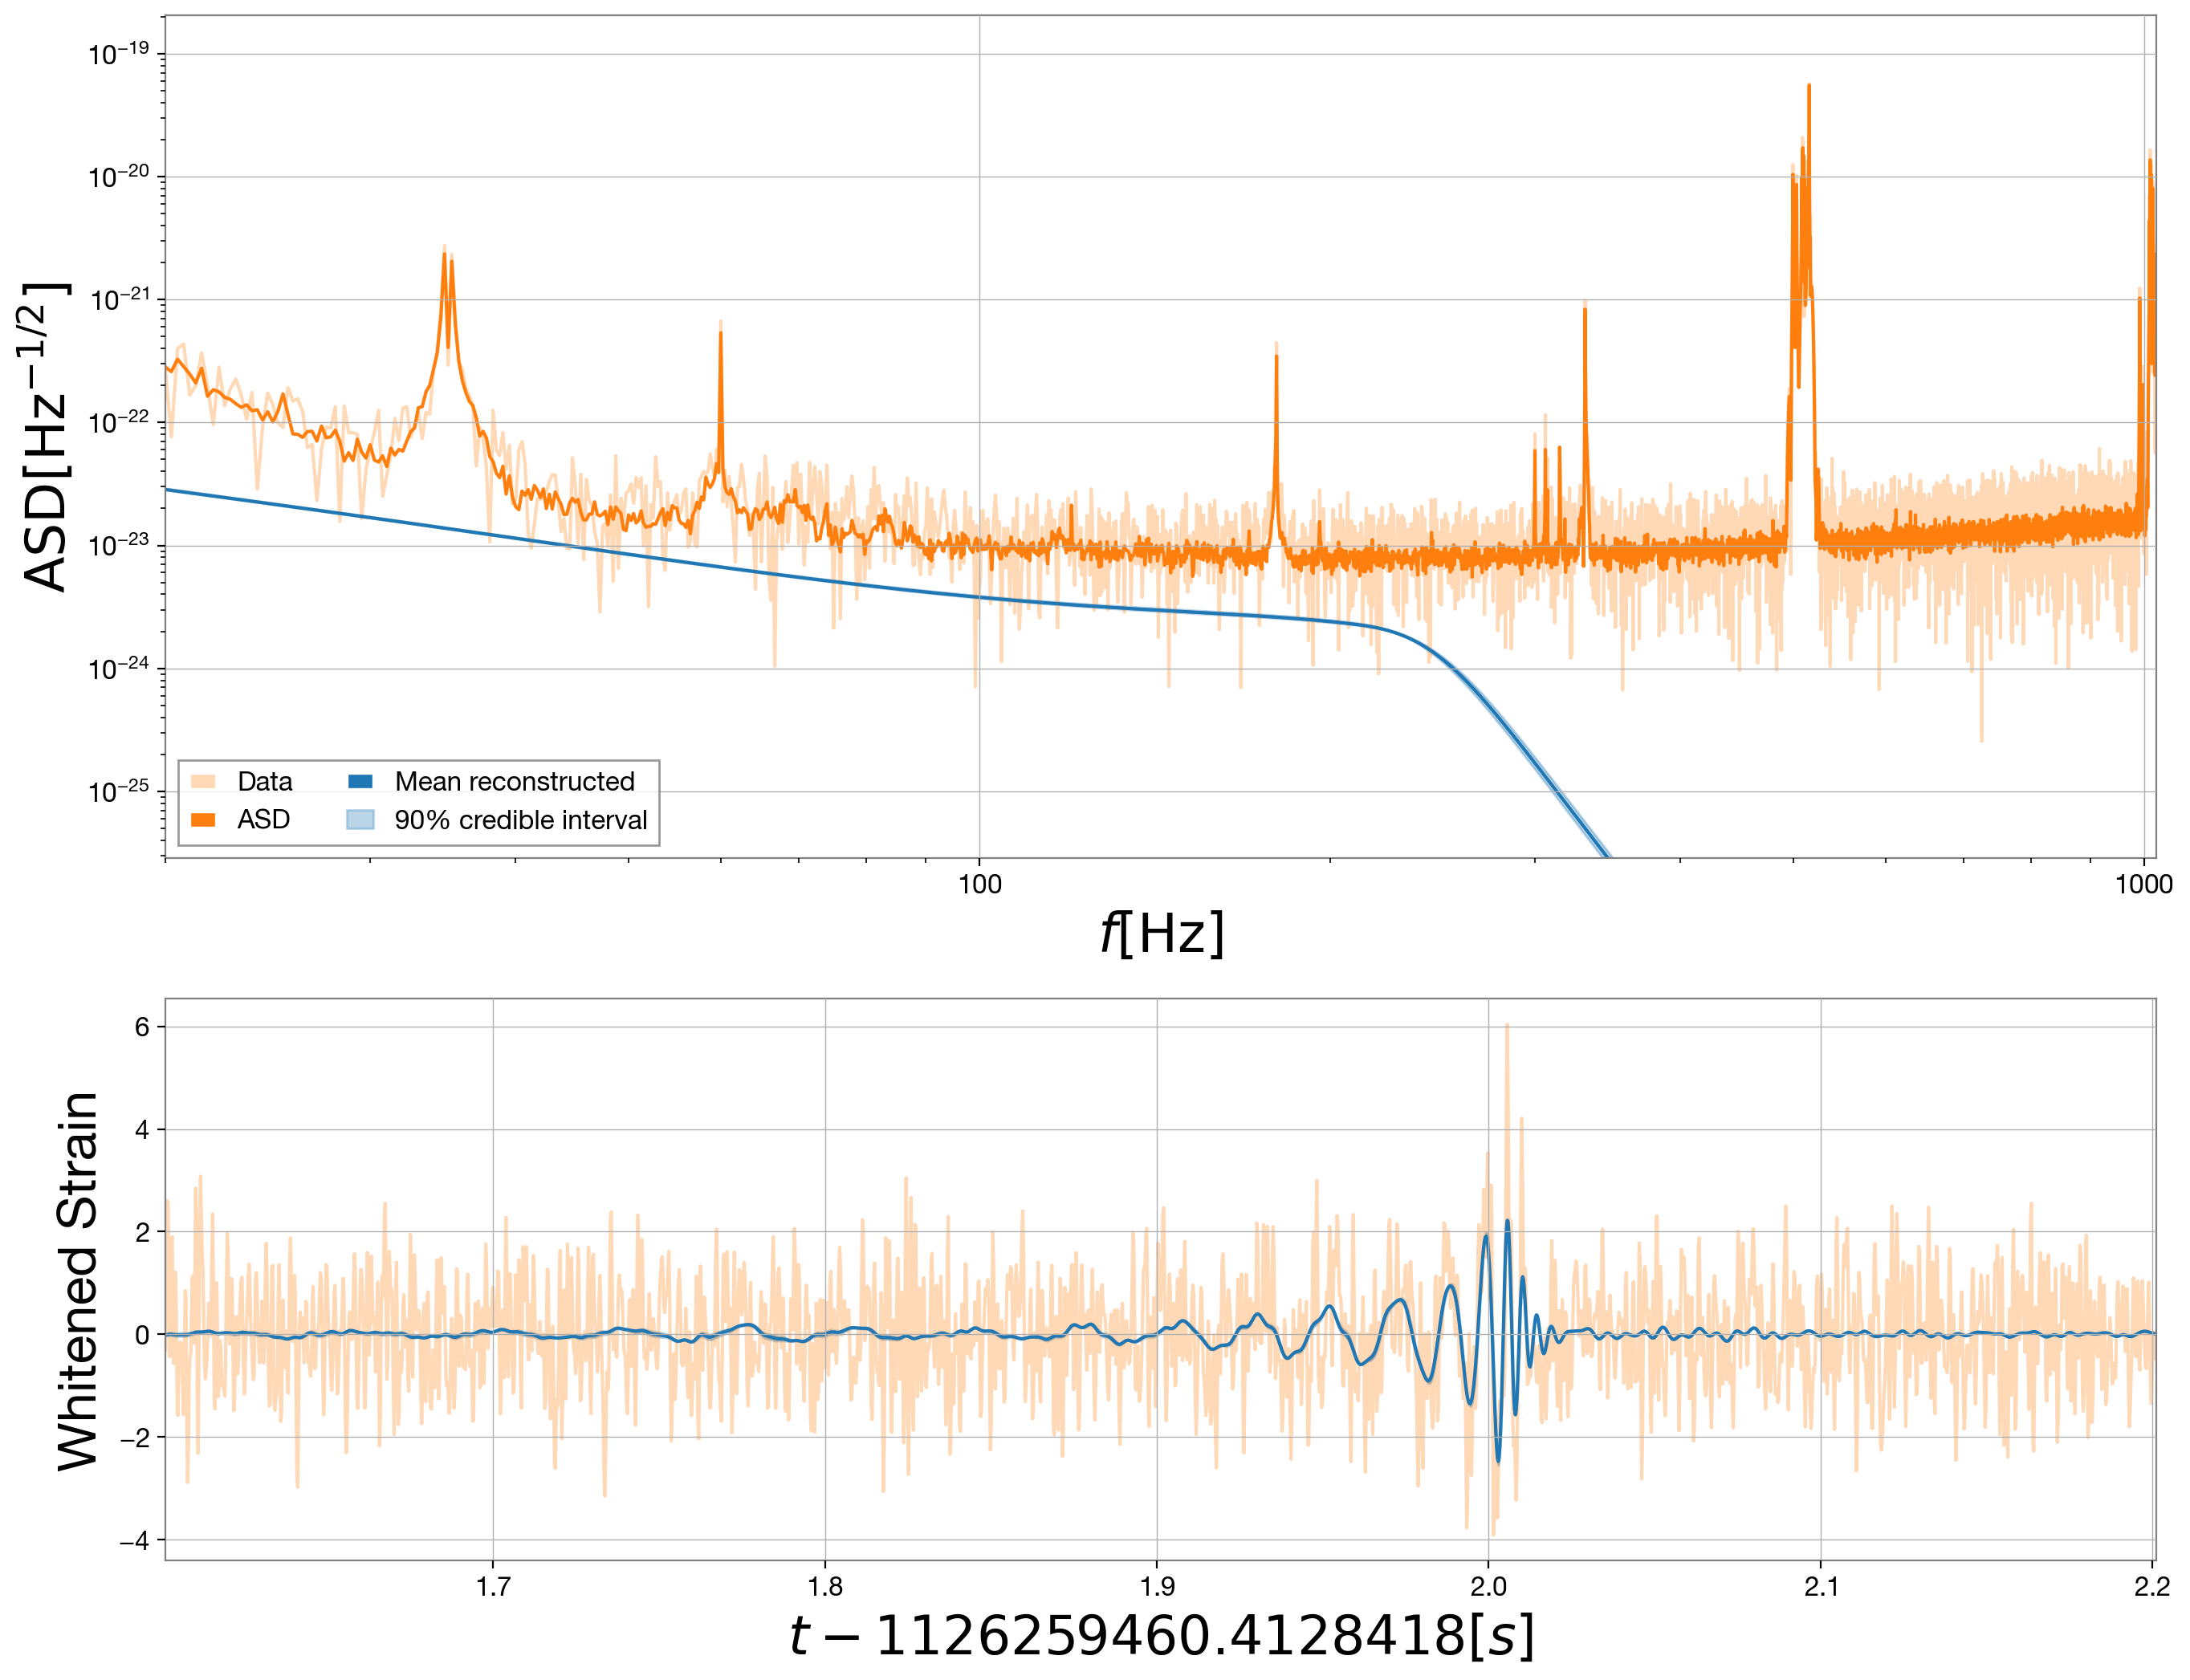

nsamples: 167
ln_noise_evidence: -8483.570
ln_evidence: -8220.990 +/-  0.401
ln_bayes_factor: 262.579 +/-  0.401



In [11]:
from bilby.gw.result import CBCResult

cbc_result = CBCResult.from_json("short3/GW150914_result.json")
for ifo in interferometers:
    cbc_result.plot_interferometer_waveform_posterior(
        interferometer=ifo, n_samples=500, save=False
    )
    plt.show()
    plt.close()

print(result_short)
#result_short.plot_marginals()


What about trying to fit for the luminosity distance?

We know that the probability of funding something further away will be given by a power law. In this instance our function will be defined by

$$
p(x) = A x^{-2}
$$

We can inject this sampling prior to get the distance of the merger. Let's go ahead and inject that prior and look at our results.  

In [12]:
prior = bilby.core.prior.PriorDict()
prior['chirp_mass']   = Uniform(name='chirp_mass', minimum=25.0,maximum=35.5)
prior['mass_ratio']   = Uniform(name='mass_ratio', minimum=0.5, maximum=1)
prior['phase']        = Uniform(name="phase", minimum=0, maximum=2*np.pi)
prior['geocent_time'] = Uniform(name="geocent_time", minimum=time_of_event-0.1, maximum=time_of_event+0.1)
prior['a_1'] =  0.0
prior['a_2'] =  0.0
prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0
prior['dec'] =  -1.2232
prior['ra'] =  2.19432
prior['theta_jn'] =  1.89694
prior['psi'] =  0.532268
prior['luminosity_distance'] = bilby.core.prior.PowerLaw(alpha=2., minimum=50., maximum=800., name='luminosity_distance')

# Finally, create our likelihood, passing in what is needed to get going
likelihood = bilby.gw.likelihood.GravitationalWaveTransient(interferometers, waveform_generator, priors=prior,
    time_marginalization=True, phase_marginalization=True, distance_marginalization=True)

result_short = bilby.run_sampler(
    likelihood, prior, sampler='dynesty', outdir='short_dist', label="GW150914",
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    sample="unif", nlive=500, dlogz=3  # <- Arguments are used to make things fast - not recommended for general use
)

10:44 bilby INFO    : Distance marginalisation file .distance_marginalization_lookup.npz does not exist
10:44 bilby INFO    : Building lookup table for distance marginalisation.


  0%|          | 0/400 [00:00<?, ?it/s]

10:44 bilby INFO    : Running for label 'GW150914', output will be saved to 'short_dist'
10:44 bilby INFO    : Using lal version 7.3.1
10:44 bilby INFO    : Using lal git version Branch: None;Tag: lalsuite-v7.14;Id: c1be3b4393c305f7d4244b707604d603a10bc764;;Builder: Duncan Macleod <duncan.macleod@ligo.org>;Repository status: CLEAN: All modifications committed
10:44 bilby INFO    : Using lalsimulation version 5.1.0
10:44 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsuite-v7.14;Id: c1be3b4393c305f7d4244b707604d603a10bc764;;Builder: Duncan Macleod <duncan.macleod@ligo.org>;Repository status: CLEAN: All modifications committed
10:45 bilby INFO    : Analysis priors:
10:45 bilby INFO    : chirp_mass=Uniform(minimum=25.0, maximum=35.5, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
10:45 bilby INFO    : mass_ratio=Uniform(minimum=0.5, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
10:45 bilby INFO    : time_jitter

1it [00:00, ?it/s]

11:03 bilby INFO    : Written checkpoint file short_dist/GW150914_resume.pickle
11:09 bilby INFO    : Written checkpoint file short_dist/GW150914_resume.pickle
11:09 bilby INFO    : Rejection sampling nested samples to obtain 162 posterior samples
11:09 bilby INFO    : Sampling time: 0:23:51.386872
11:09 bilby INFO    : Computing per-detector log likelihoods.


...

11:09 bilby INFO    : Generating sky frame parameters.


  0%|          | 0/162 [00:00<?, ?it/s]

11:09 bilby INFO    : Computing SNRs for every sample.


  0%|          | 0/162 [00:00<?, ?it/s]

11:09 bilby INFO    : Summary of results:
nsamples: 162
ln_noise_evidence: -8483.570
ln_evidence: -8198.929 +/-  0.313
ln_bayes_factor: 284.641 +/-  0.313



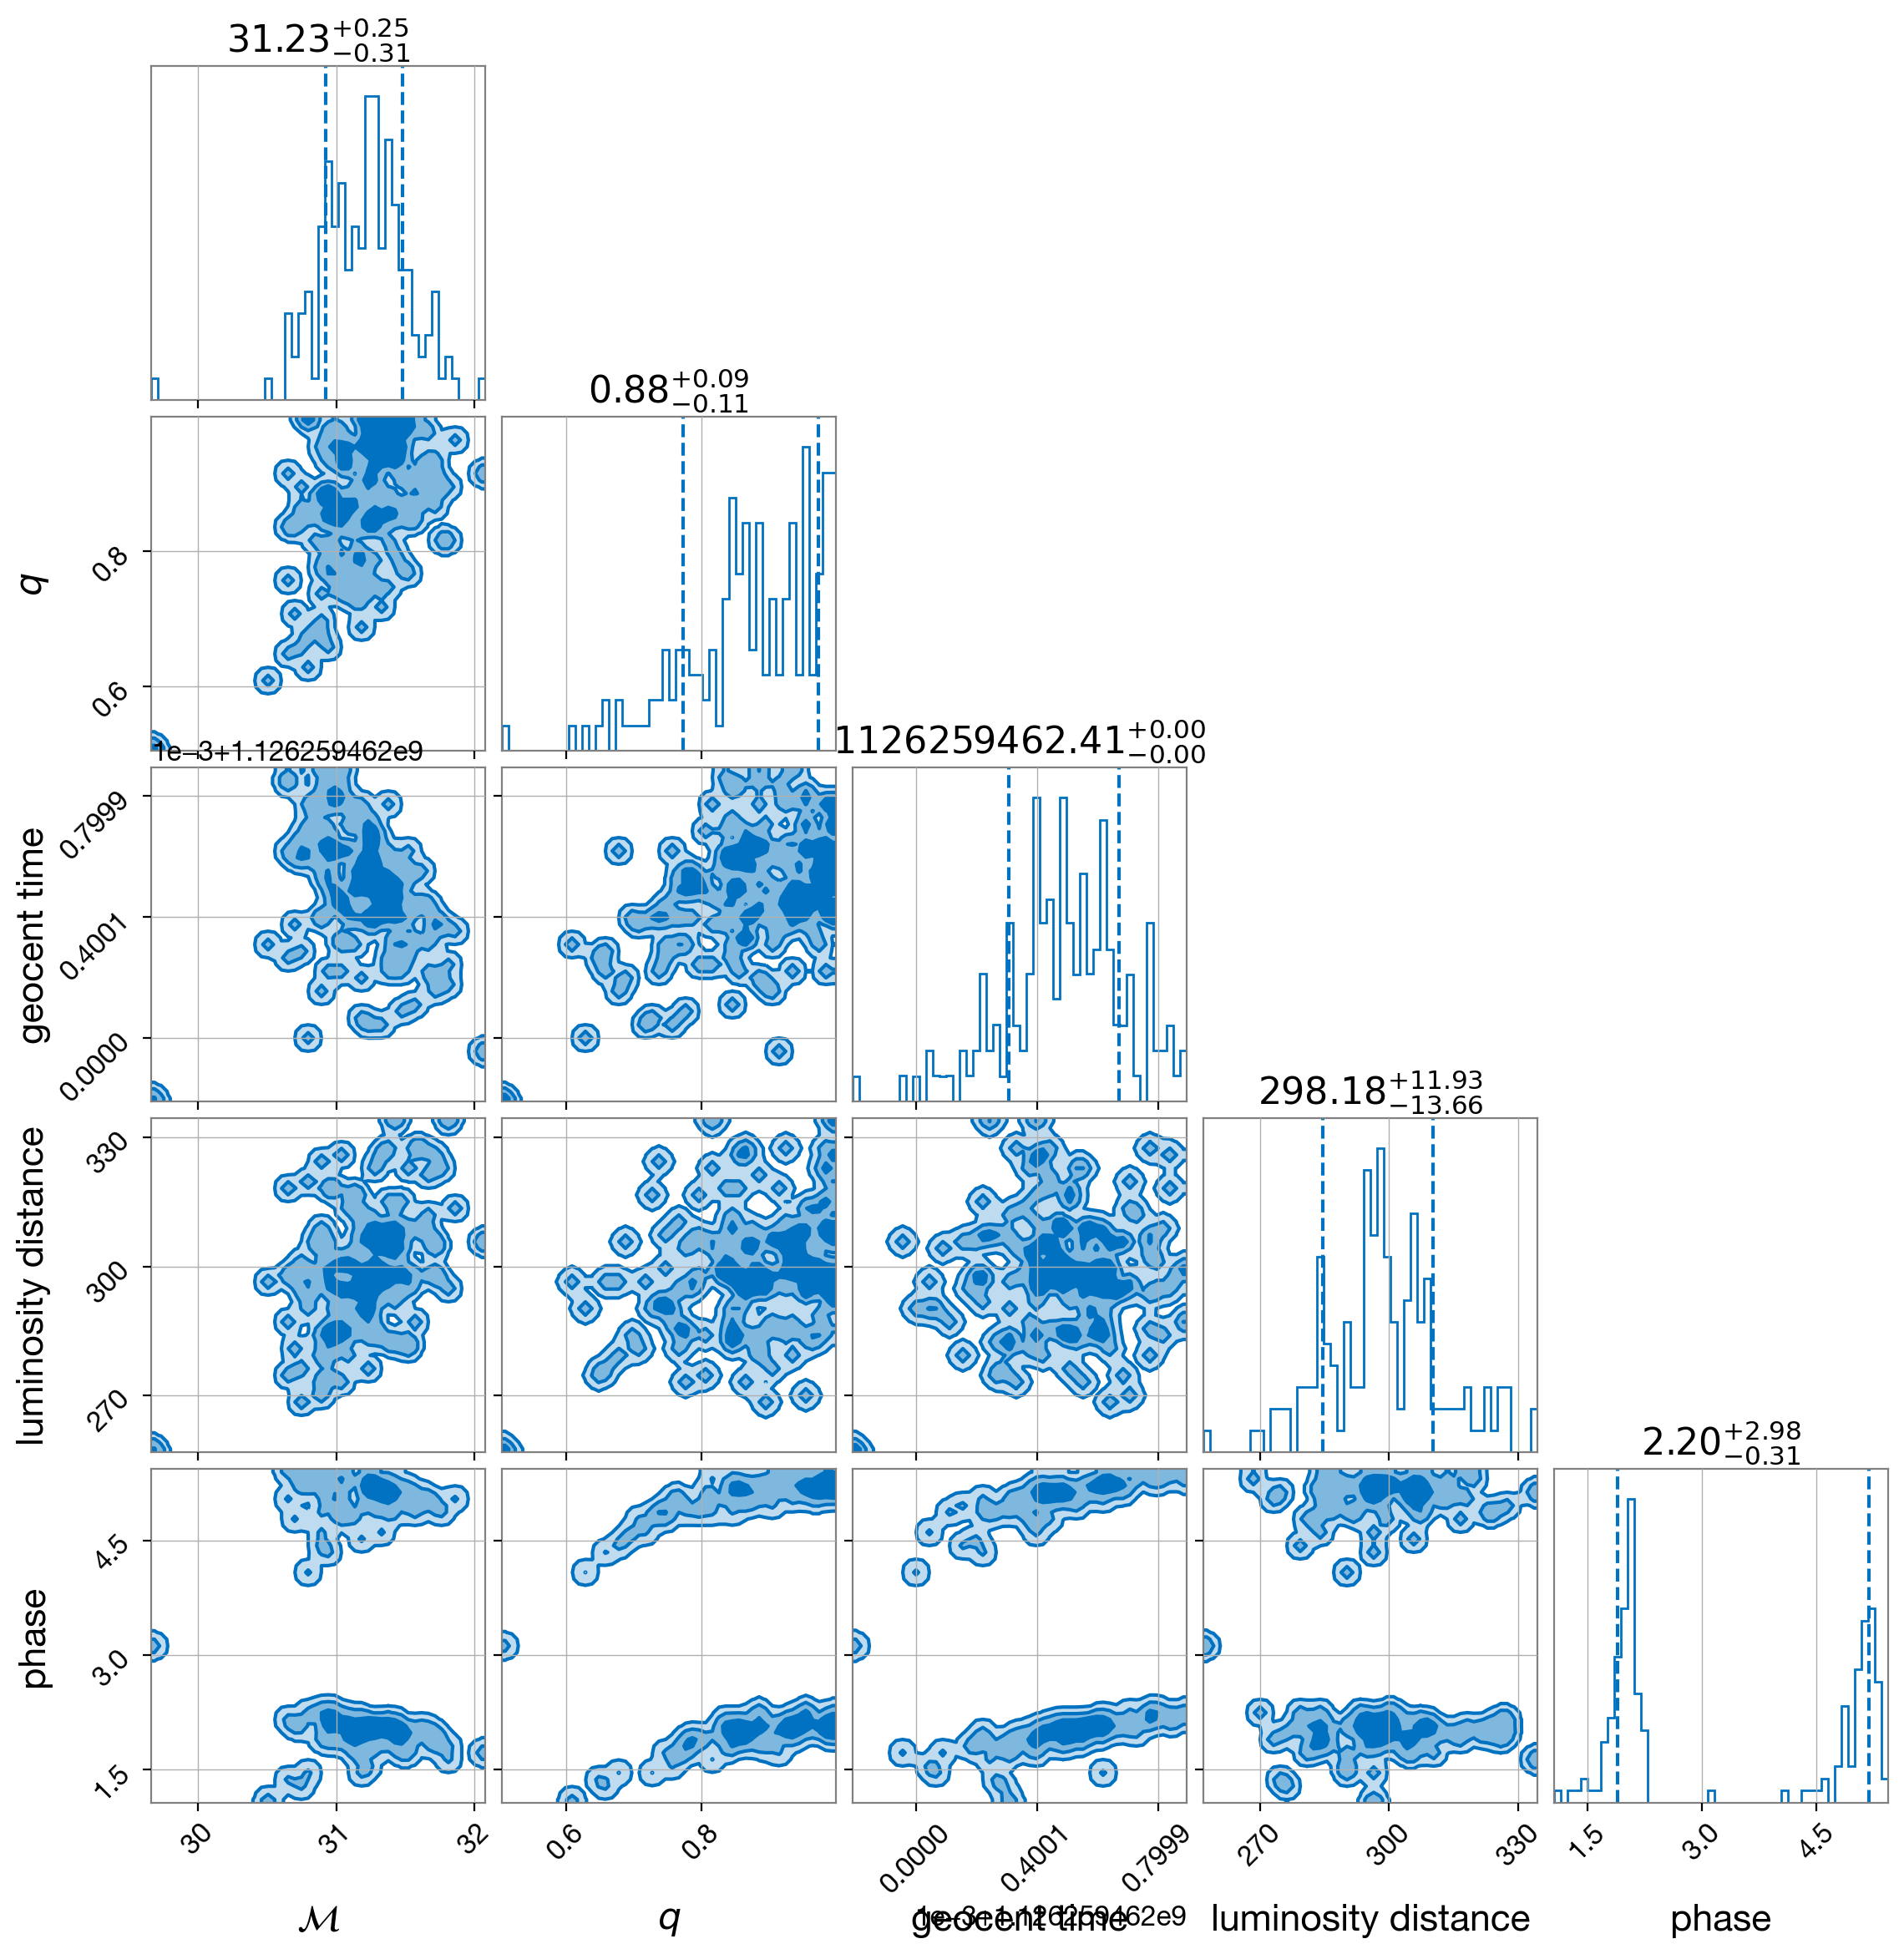

In [13]:
result_short.plot_corner(parameters=["chirp_mass", "mass_ratio", "geocent_time","luminosity_distance","phase"], prior=True)


01:18 bilby INFO    : Generating waveform figure for H1
01:18 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


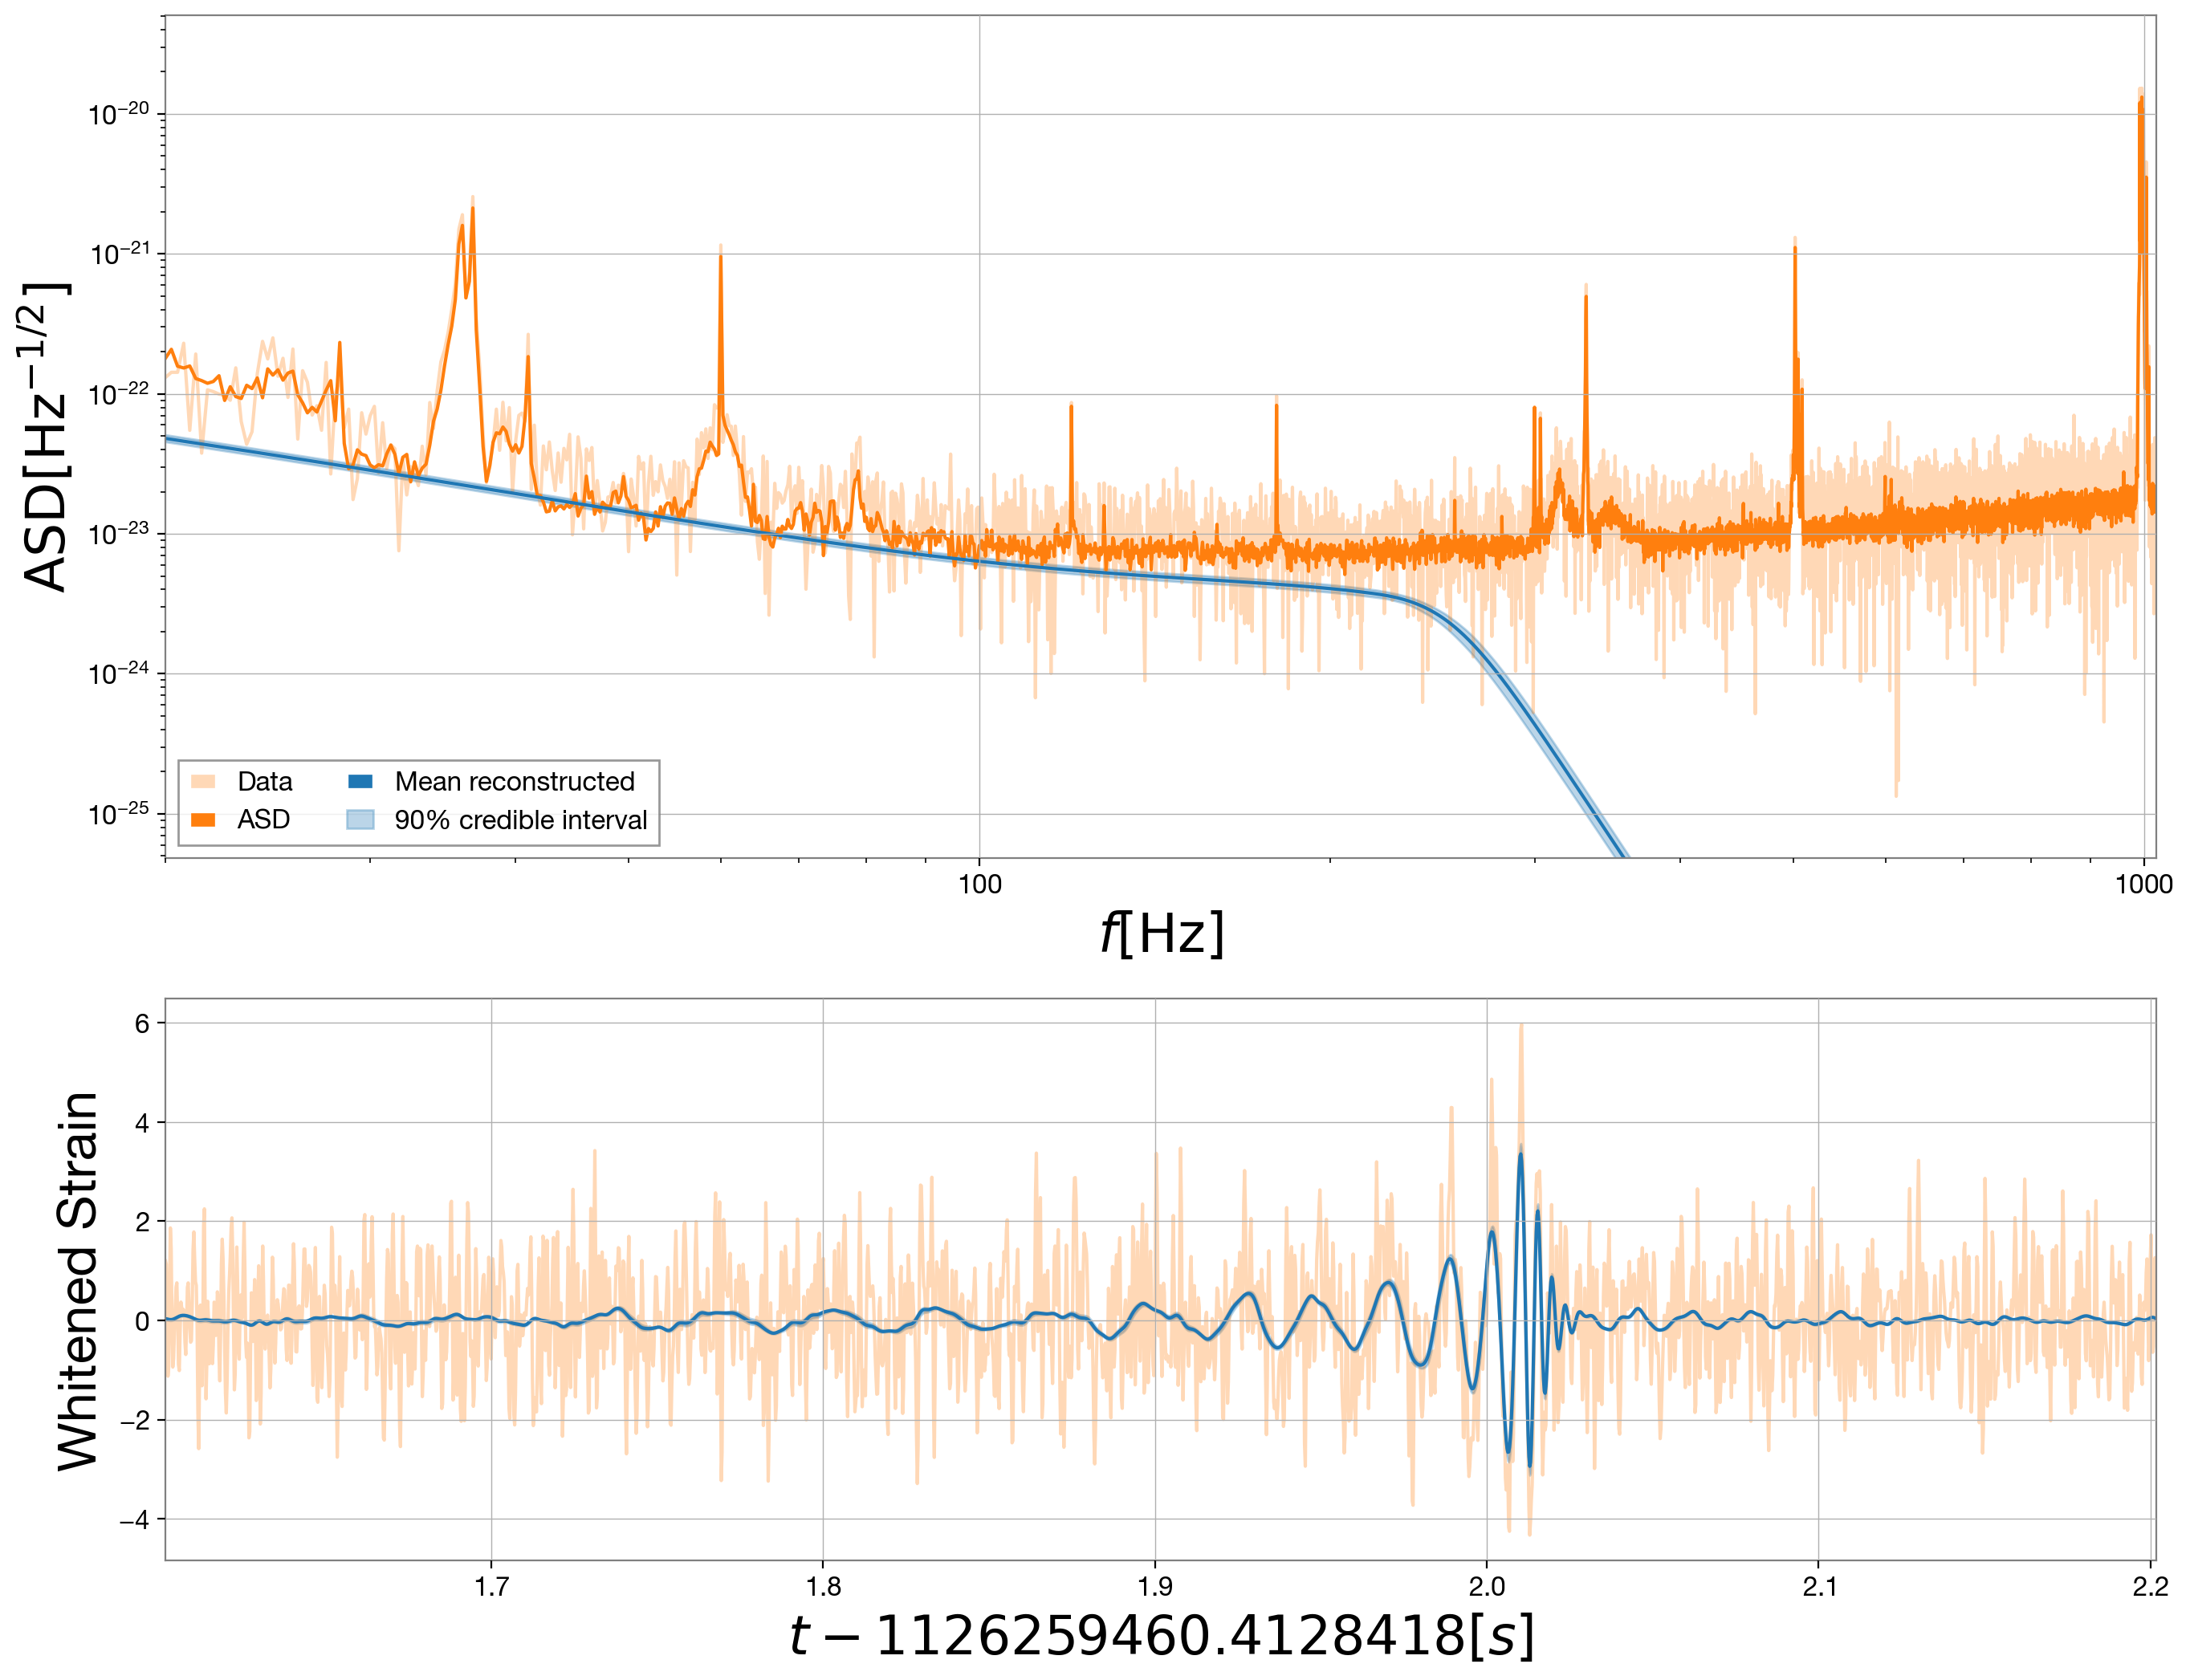

01:18 bilby INFO    : Generating waveform figure for L1
01:18 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


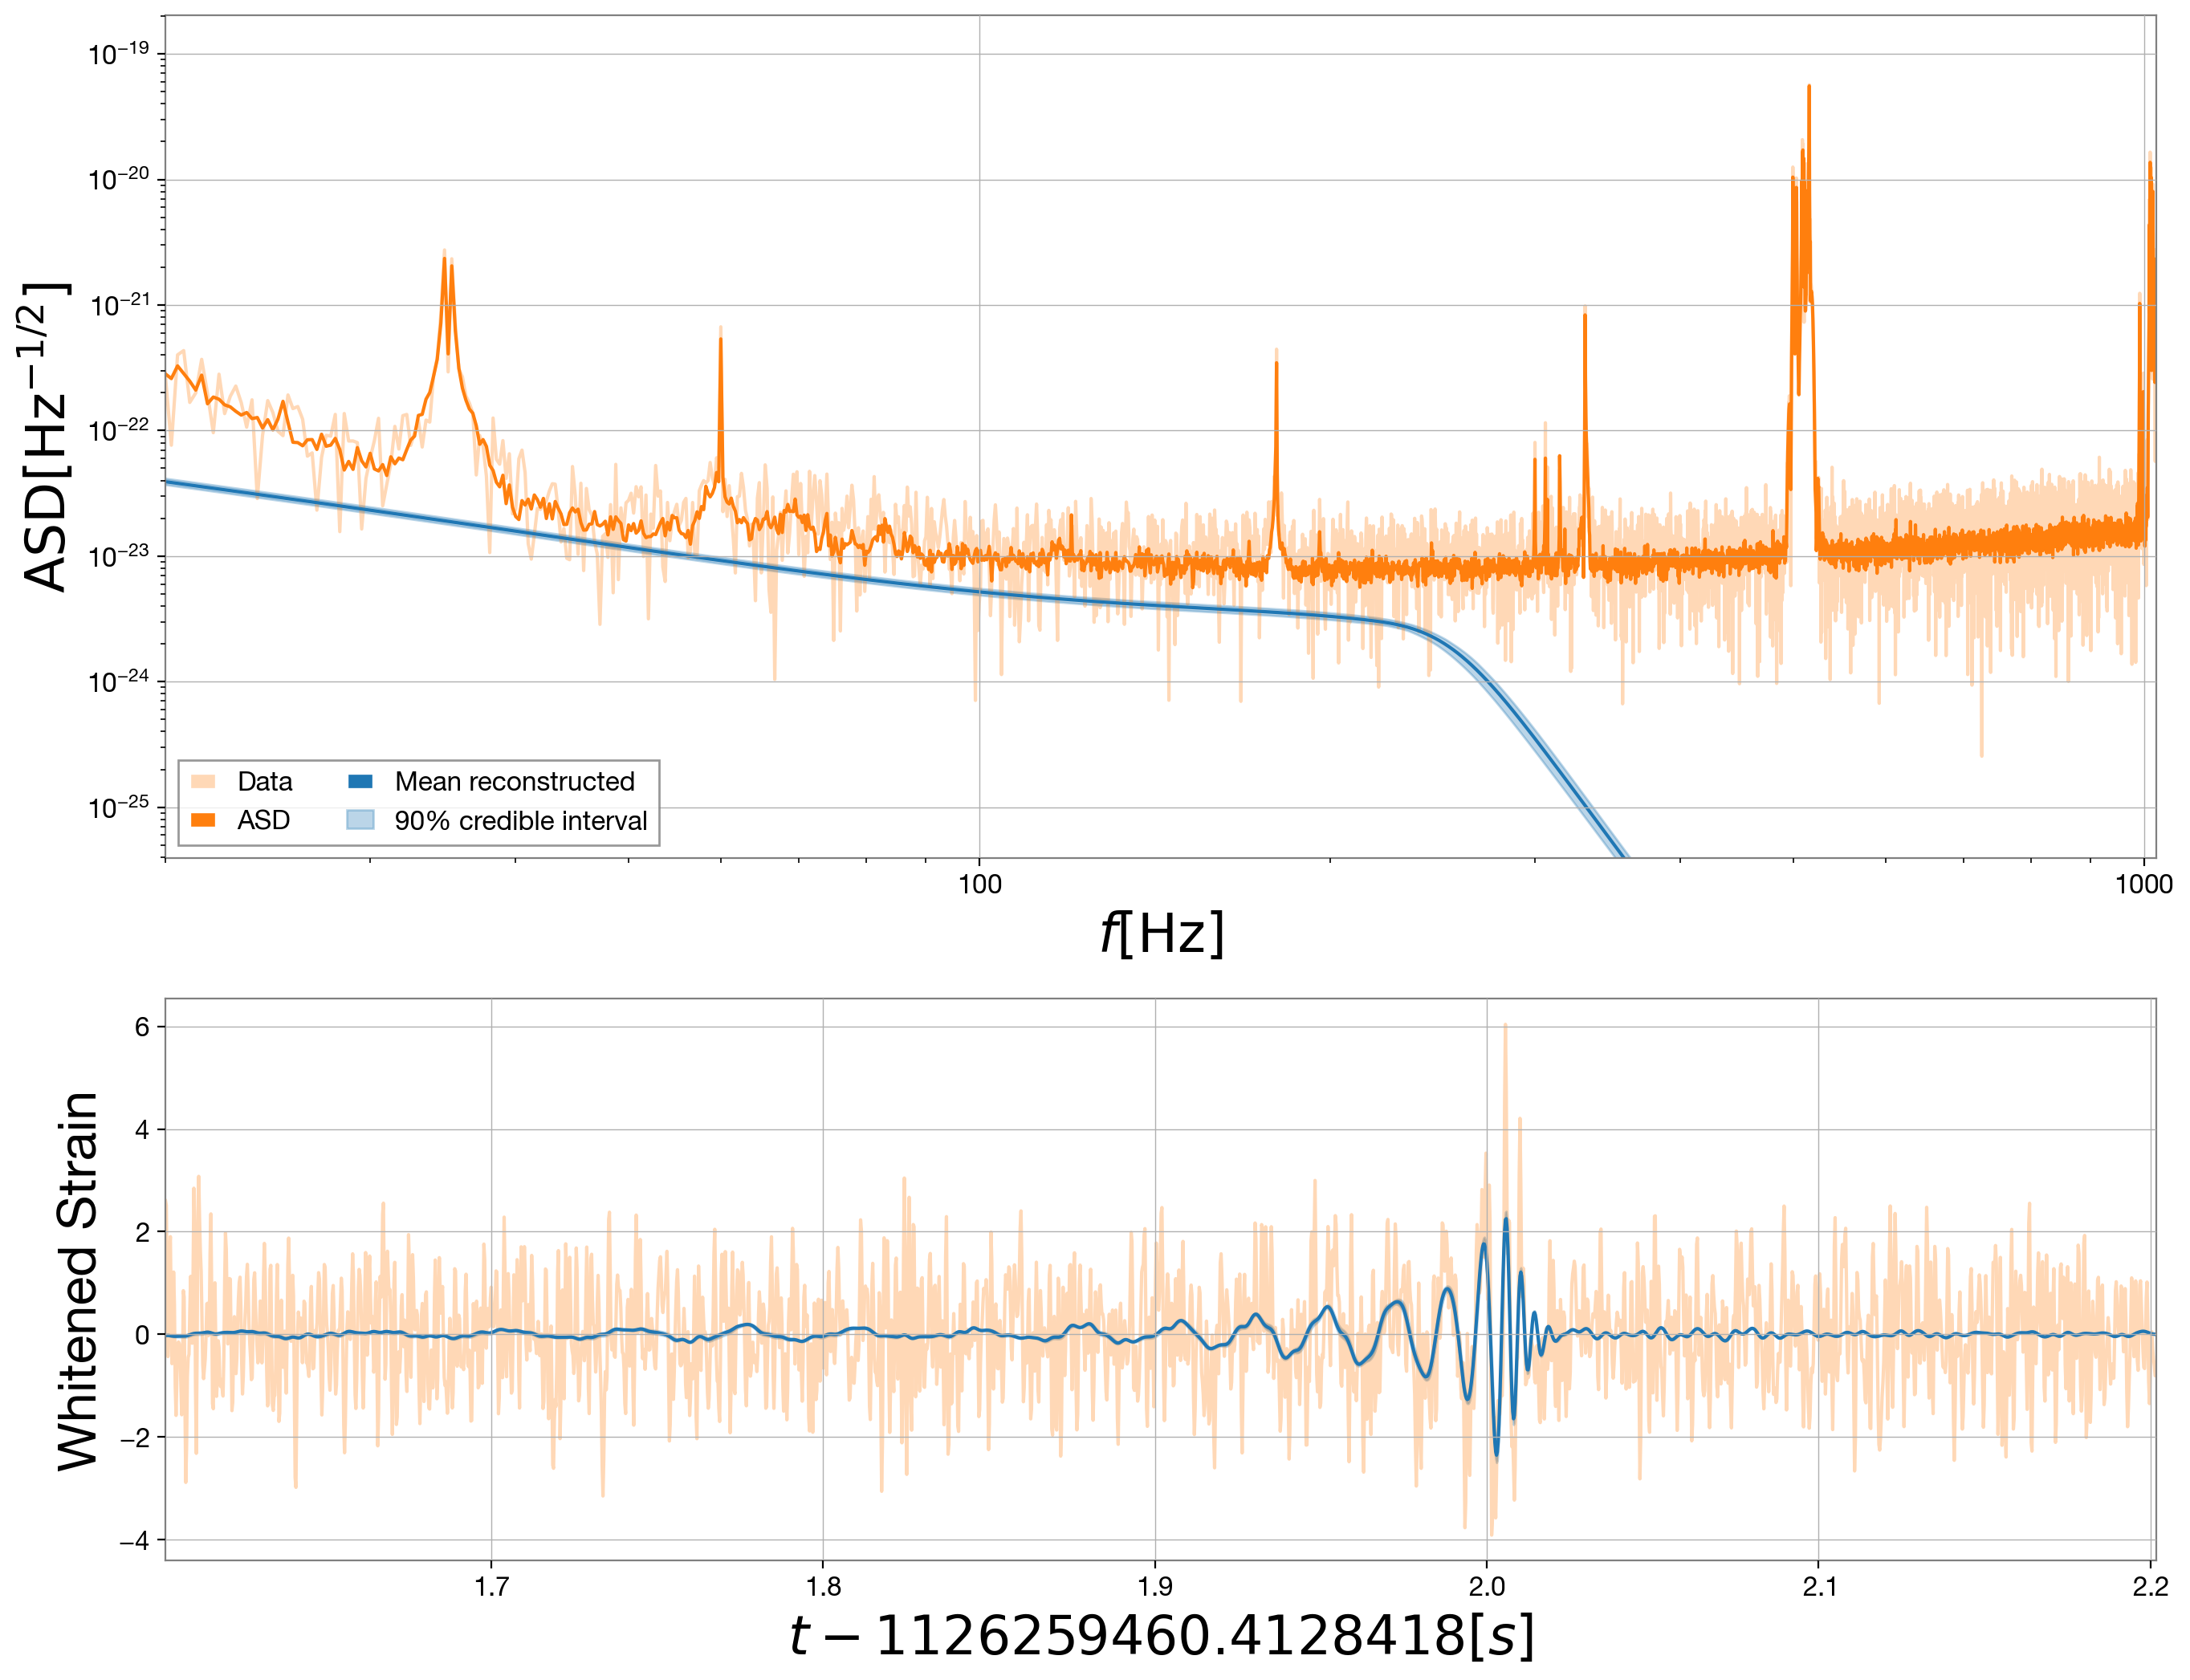

[283.52994137 283.60987617 284.54758291 284.72334688
 284.74819457 285.16662983 285.26142321 285.29408667
 285.35249117 285.80497097 285.82547369 285.90457454
 286.11667554 286.11680305 286.12821232 286.14808303
 286.26672587 286.29004429 286.32521699 286.3552842
 286.37170234 286.43567543 286.50179121 286.53264324
 286.59688972 286.62513302 286.67389195 286.76469437
 286.80544486 286.86433431 286.8885054  286.91835342
 286.92486101 287.01249101 287.01689601 287.04400287
 287.06751517 287.10654282 287.1095547  287.15479764
 287.17258566 287.17724095 287.20099189 287.24382801
 287.27591402 287.28969724 287.30673085 287.31600852
 287.36911512 287.37984252 287.38441546 287.38746402
 287.38809398 287.39404292 287.39476617 287.39820114
 287.41940708 287.46726403 287.47469444 287.49759314
 287.51974335 287.52288059 287.55351933 287.55883265
 287.60841885 287.60997467 287.61139003 287.66229608
 287.69004185 287.70238983 287.70308881 287.70350086
 287.72185184 287.73085843 287.75119524 287.754

In [144]:
from bilby.gw.result import CBCResult

cbc_result = CBCResult.from_json("short_dist/GW150914_result.json")
for ifo in interferometers:
    cbc_result.plot_interferometer_waveform_posterior(
        interferometer=ifo, n_samples=500, save=False
    )
    plt.show()
    plt.close()

print(cbc_result.log_likelihood_evaluations)
#result_short.plot_marginals()

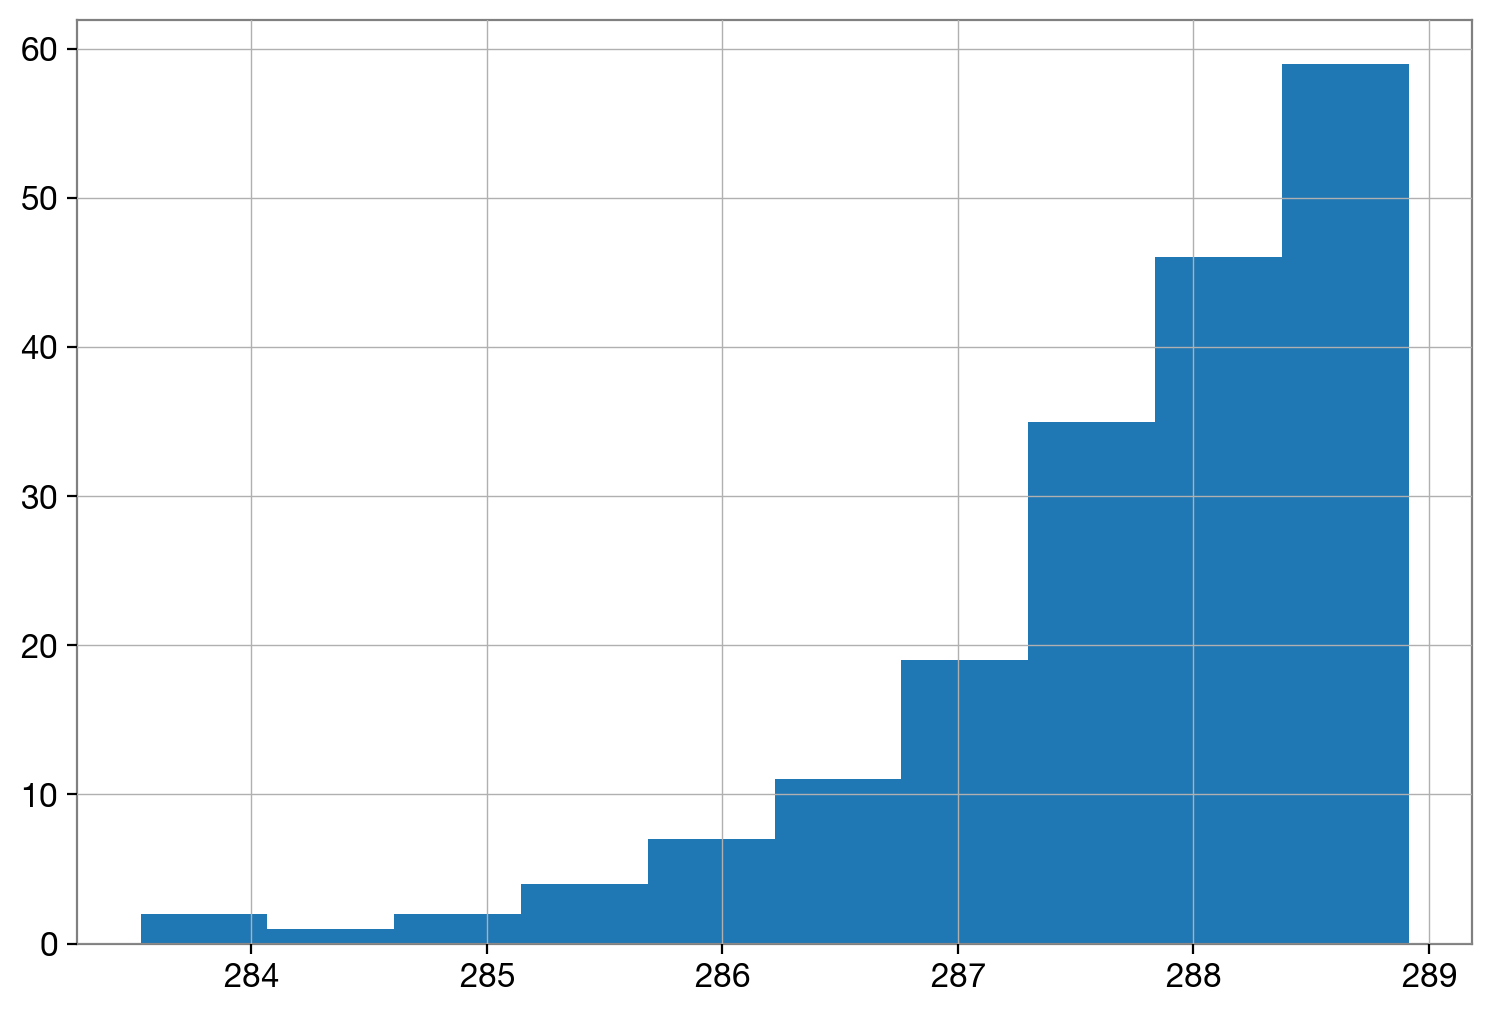

284.5922106623051


In [145]:
plt.hist(cbc_result.log_likelihood_evaluations)
plt.show()
print(cbc_result.log_bayes_factor)

<a name='exercises_23_6'></a>     

| [Top](#section_23_0) | [Restart Section](#section_23_6) |


### <span style="border:3px; border-style:solid; padding: 0.15em; border-color: #90409C; color: #90409C;">Exercise 23.6.1</span>

<br>